# Connect Forest Management Model with Forest Carbon Budget Model

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
import ws3.forest
import time
import gurobipy as grb
import pickle
import libcbm
import os
from util_opt import compile_events, cbm_report, compile_scenario_maxstock, plot_scenario_maxstock, run_cbm_emissionstock, run_scenario, plugin_c_curves, plugin_c_curves_both, cbm_report_both, compare_ws3_cbm, compare_ws3_cbm_both, track_system_stock, track_system_emission, compile_scenario_minemission, plot_scenario_minemission, kpi_age, kpi_species, cmp_c_ss, cmp_c_se, results_scenarios, bootstrap_ogi, compare_kpi_age

In [2]:
base_year = 2020
horizon = 10
period_length = 10
max_age = 1000
n_steps = 100
tvy_name = 'totvol'
max_harvest = 1.0

In [3]:
# Define scenario options based on case study
scenario_options = {
    'redchris': ['no_cons','evenflow_cons', 'redchrs_AAC_90%', 'redchrs_AAC_80%', 'redchrs_AAC_70%', 'redchrs_AAC_60%', 'redchrs_AAC_50%', 'redchrs_AAC_40%', 'redchrs_AAC_30%', 'redchrs_AAC_20%', 'redchrs_AAC_10%' ],
    'goldenbear': ['no_cons', 'evenflow_cons', 'gldbr_AAC_90%', 'gldbr_AAC_80%', 'gldbr_AAC_70%', 'gldbr_AAC_60%', 'gldbr_AAC_50%', 'gldbr_AAC_40%', 'gldbr_AAC_30%', 'gldbr_AAC_20%', 'gldbr_AAC_10%'],
    'equitysilver': [ 'no_cons','evenflow_cons', 'eqtslvr_AAC_90%', 'eqtslvr_AAC_80%', 'eqtslvr_AAC_70%', 'eqtslvr_AAC_60%', 'eqtslvr_AAC_50%', 'eqtslvr_AAC_40%', 'eqtslvr_AAC_30%', 'eqtslvr_AAC_20%', 'eqtslvr_AAC_10%'],
    'test': ['no_cons', 'evenflow_cons', 'bau_redchrs']
}

# Function to handle case study selection and update scenario dropdown
def select_case_study(case_study):
    print(f"Selected case study: {case_study}")
    # Update the scenario dropdown based on the selected case study
    scenario_dropdown.options = scenario_options.get(case_study, [])
    scenario_dropdown.value = scenario_options[case_study][0]  # Set a default value

# Case study dropdown
case_study_dropdown = widgets.Dropdown(
    options=['redchris', 'goldenbear', 'equitysilver', 'test'],
    value='equitysilver',
    description='Case Study:'
)
case_study_dropdown.observe(lambda change: select_case_study(change['new']), names='value')
display(case_study_dropdown)

# Function to handle scenario selection
def select_scenario(scenario_name):
    print(f"Selected scenario: {scenario_name}")

# Scenario dropdown
scenario_dropdown = widgets.Dropdown(
    options=scenario_options['redchris'],  # Set initial options based on default case study
    value=scenario_options['redchris'][1],  # Set initial value
    description='Scenario:'
)
scenario_dropdown.observe(lambda change: select_scenario(change['new']), names='value')
display(scenario_dropdown)

# Function to handle objective functon
def select_obj(obj_mode):
    print(f"Selected objective: {obj_mode}")
obj_dropdown = widgets.Dropdown(
    options=['max_hv', 'min_ha', 'max_st', 'min_em'],
    value='max_st',
    description='Objective:'
)
display(obj_dropdown)
obj_dropdown.observe(lambda change: select_obj(change['new']), names='value')

Dropdown(description='Case Study:', index=2, options=('redchris', 'goldenbear', 'equitysilver', 'test'), value…

Dropdown(description='Scenario:', index=1, options=('no_cons', 'evenflow_cons', 'redchrs_AAC_90%', 'redchrs_AA…

Dropdown(description='Objective:', index=2, options=('max_hv', 'min_ha', 'max_st', 'min_em'), value='max_st')

In [4]:
# Initialize main widget components 
hwp_pool_effect = widgets.FloatSlider(min=0, max=1, step=1, description='HWP_effect', value=1, layout=widgets.Layout(margin='10px 0'))
release_immediately = widgets.FloatSlider(min=0, max=1, step=1, description='Release immediately', value=1, layout=widgets.Layout(margin='10px 0'))
displacement_effect = widgets.FloatSlider(min=0, max=1, step=1, description='Displacement', value=1, layout=widgets.Layout(margin='10px 0'))
clt_percentage = widgets.FloatSlider(min=0, max=1, step=0.1, description='CLT_percent:', value=0.5, layout=widgets.Layout(margin='10px 0'))
credibility = widgets.FloatSlider(min=0, max=1, step=0.1, description='Credibility:', value=1, layout=widgets.Layout(margin='10px 0'))
# max_harvest = widgets.FloatSlider(min=0, max=1, step=0.05, description='Max_harvest:', value=1.0, layout=widgets.Layout(margin='10px 0'))
budget_input = widgets.FloatText(value=10000000, description='Budget:', layout=widgets.Layout(margin='10px 0'))

release_immediately.layout.display = 'none' if hwp_pool_effect.value != 0 else 'block'
displacement_effect.layout.display = 'block' if hwp_pool_effect.value != 0 else 'none'
clt_percentage.layout.display = 'block' if hwp_pool_effect.value != 0 and displacement_effect.value != 0 else 'none'
credibility.layout.display = 'block' if hwp_pool_effect.value != 0 and displacement_effect.value != 0 else 'none'

container = widgets.VBox([
    hwp_pool_effect, release_immediately, displacement_effect, clt_percentage, credibility, budget_input  
    # ,max_harvest
])

display(container)

def update_widgets(change):
    hwp_pool_effect_value = hwp_pool_effect.value
    displacement_effect_value = displacement_effect.value

    release_immediately.layout.display = 'block' if hwp_pool_effect_value == 0 else 'none'
    displacement_effect.layout.display = 'block' if hwp_pool_effect_value != 0 else 'none'

    clt_percentage.layout.display = 'block' if hwp_pool_effect_value != 0 and displacement_effect_value != 0 else 'none'
    credibility.layout.display = 'block' if hwp_pool_effect_value != 0 and displacement_effect_value != 0 else 'none'

hwp_pool_effect.observe(update_widgets, names='value')
displacement_effect.observe(update_widgets, names='value')

In [5]:
#Start Calculating the Running Time
Start = time.time()

In [6]:
case_study = case_study_dropdown.value
scenario_name = scenario_dropdown.value
obj_mode = obj_dropdown.value
hwp_pool_effect_value = hwp_pool_effect.value
release_immediately_value = release_immediately.value if hwp_pool_effect_value == 0 else 0
displacement_effect = displacement_effect.value if hwp_pool_effect_value != 0 else 0
clt_percentage = clt_percentage.value if displacement_effect != 0 else 0
credibility = credibility.value if displacement_effect != 0 else 0
# max_harvest = max_harvest.value
budget_input = budget_input.value

In [7]:
# Define case study mappings and retrieve model details based on case study
case_study_options = {
    'redchris': {
        'model_name': 'redchris',
        'model_path': './data/woodstock_model_files_redchris'
    },
    'goldenbear': {
        'model_name': 'goldenbear',
        'model_path': './data/woodstock_model_files_goldenbear'
    },
    'equitysilver': {
        'model_name': 'equitysilver',
        'model_path': './data/woodstock_model_files_equitysilver'
    },
    'test': {
        'model_name': 'redchris',
        'model_path': './data/woodstock_model_files_redchris_test'
    }
}

model_info = case_study_options.get(case_study)

if model_info:
    model_name = model_info['model_name']
    model_path = model_info['model_path']
else:
    print('The case study name is not valid')


In [8]:
# Create and Run `ForestModel` instance
fm = ws3.forest.ForestModel(model_name=model_name,
                            model_path=model_path,
                            base_year=base_year,
                            horizon=horizon,
                            period_length=period_length,
                            max_age=max_age)
fm.import_landscape_section()
fm.import_areas_section()
fm.import_yields_section()
fm.import_actions_section()
fm.import_transitions_section()
fm.initialize_areas()
fm.add_null_action()
fm.reset_actions()
fm.grow()

In [9]:
# Flag 'harvest' as a harvesting action in the ws3 model
harvest_acode='harvest'
fm.actions[harvest_acode].is_harvest = True

In [10]:
# Read curves
file_directory = "./inputs/curves"
file_names = [f"{case_study}_c_curves_p.pkl", f"{case_study}_c_curves_f.pkl"]
loaded_data = {}

for filename in file_names:
    file_path = os.path.join(file_directory, filename)
    with open(file_path, 'rb') as file:
        loaded_data[filename] = pickle.load(file)
    print(f"Loaded data from {file_path}")

c_curves_p = loaded_data.get(f"{case_study}_c_curves_p.pkl")
c_curves_f = loaded_data.get(f"{case_study}_c_curves_f.pkl")

Loaded data from ./inputs/curves/equitysilver_c_curves_p.pkl
Loaded data from ./inputs/curves/equitysilver_c_curves_f.pkl


In [11]:
# Plug carbon and old groth yield curves into forest model
plugin_c_curves_both(fm, c_curves_p, c_curves_f)
bootstrap_ogi(fm)

Running for equitysilver_max_st_no_cons...
running no_cons scenario
Set parameter Username
Academic license - for non-commercial use only - expires 2025-01-09
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17023 rows, 83258 columns and 83258 nonzeros
Model fingerprint: 0xb26b92b9
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [4e+01, 7e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+00]
Presolve removed 17023 rows and 83258 columns
Presolve time: 0.07s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    1.6764864e+09   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.08 seconds (0.03 work units)
Optimal objective  1.676486386e+09


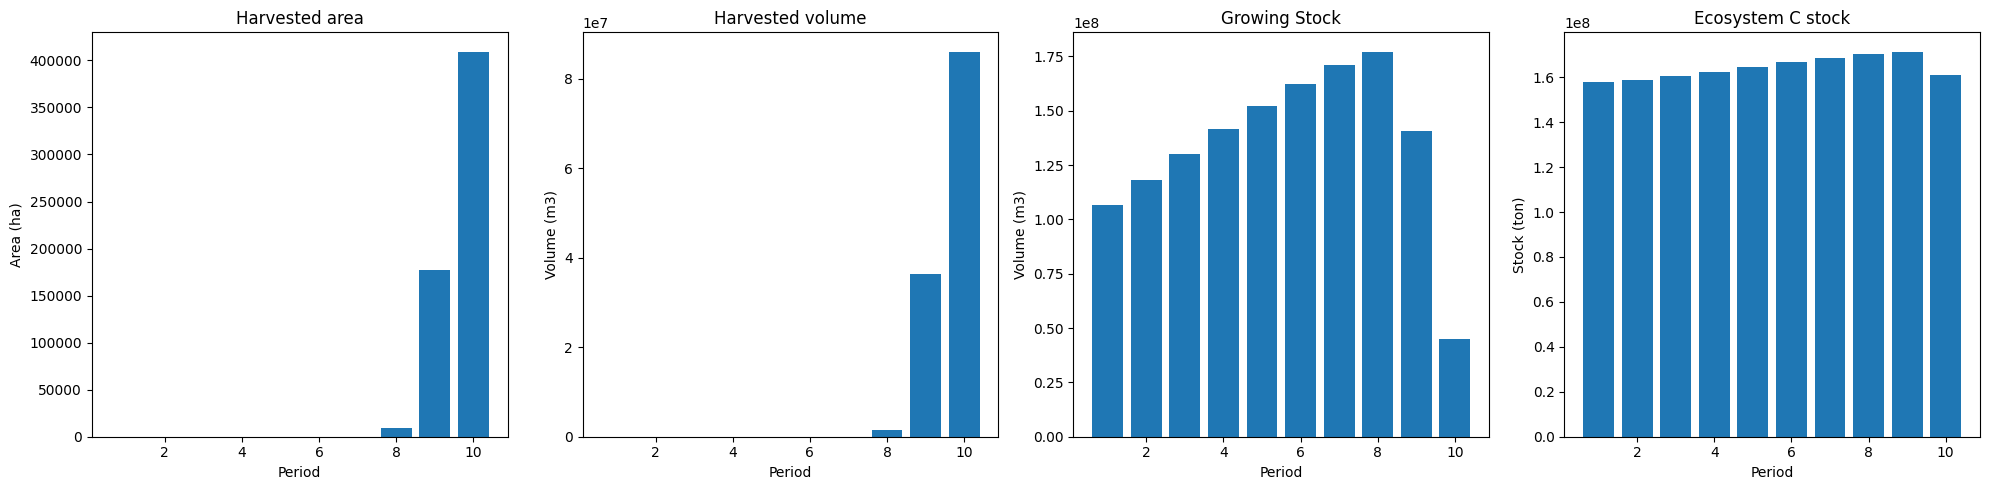

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_no_cons_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  130886
The economic indicator (the provincial government revenues) is:  4463497
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


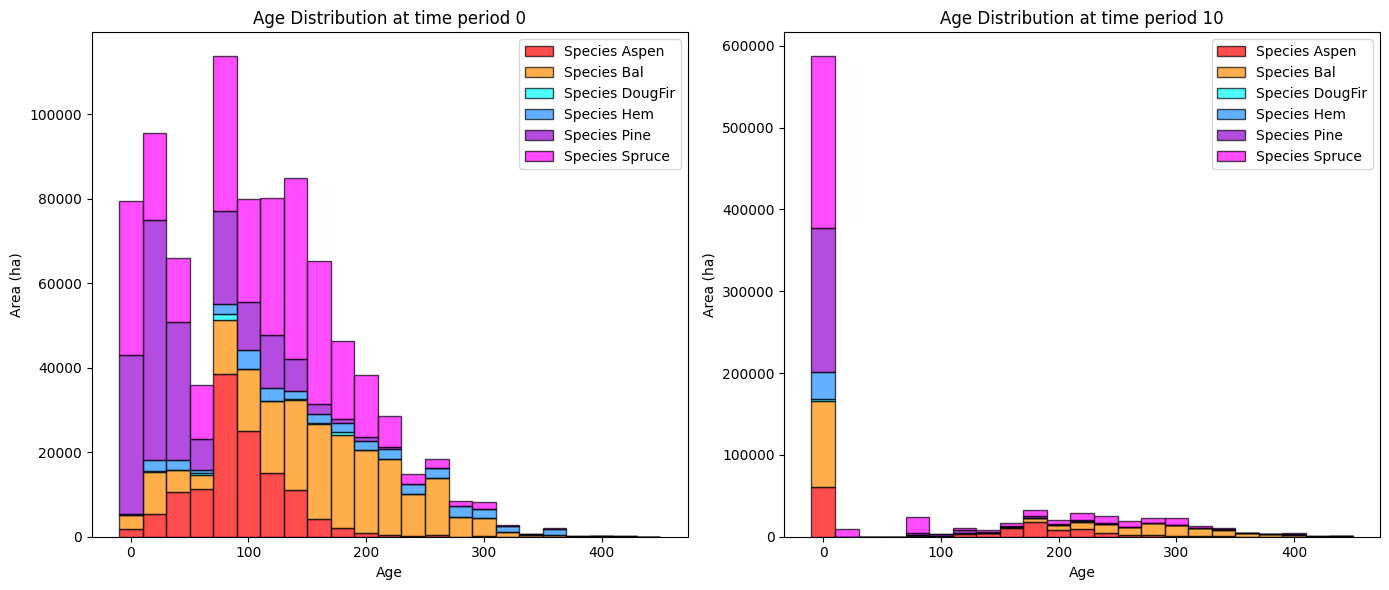

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_no_cons_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0            10    Difference
Hem      19152.127229   6126.874563 -13025.252666
DougFir    947.047810    387.176384   -559.871426
Bal      59315.970469  79882.187655  20566.217186
Spruce   36410.744598  52548.704990  16137.960392
Aspen    29632.731169  61943.511569  32310.780400
Pine      7432.733686   6721.590051   -711.143635

Overall diversity has **increased** by 54718.69 hectares from time period 0 to time period 10.


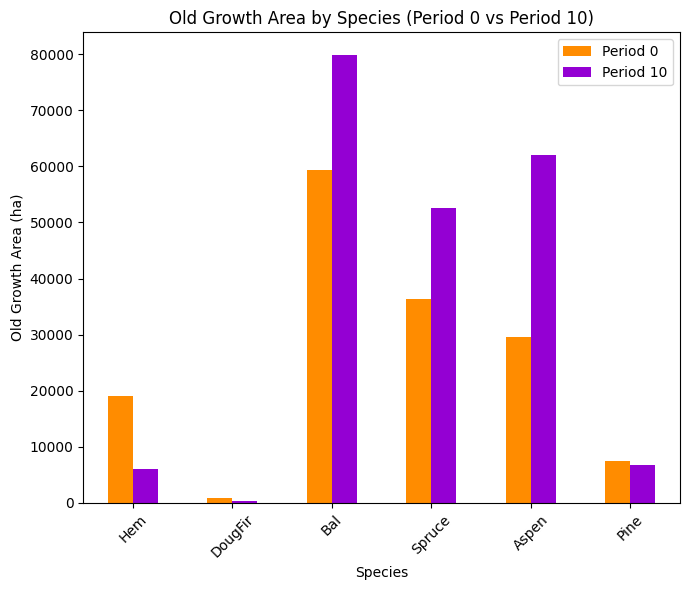

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_no_cons_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7332

Diversity has **decreased** by 2.60% from time 0 to time 10.


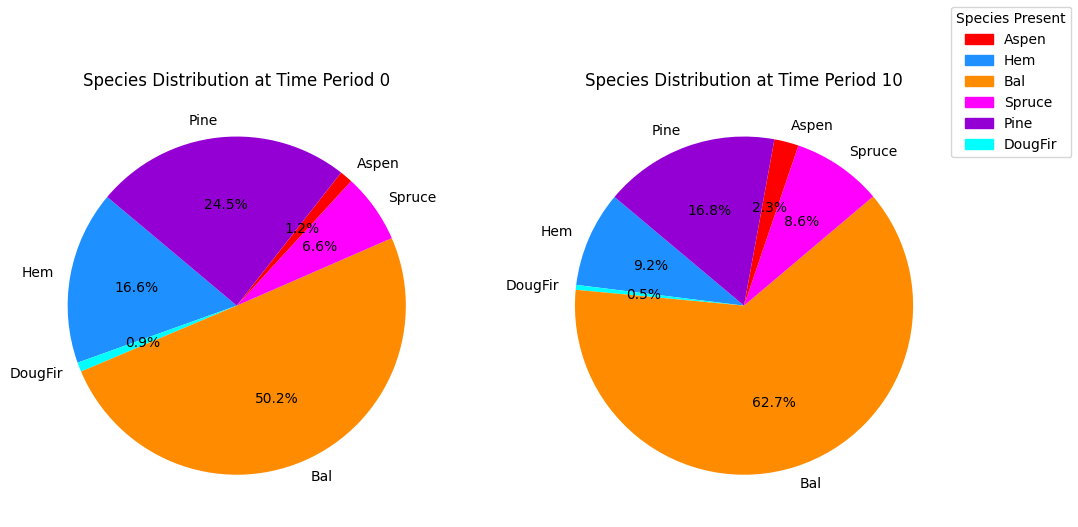

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_no_cons_species_pie.pdf
running business as usual scenario for the Equity Silver mining site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0x9ff13077
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [4e+01, 7e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8883 columns
Presolve time: 0.30s
Presolved: 8375 rows, 74376 columns, 536315 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering t

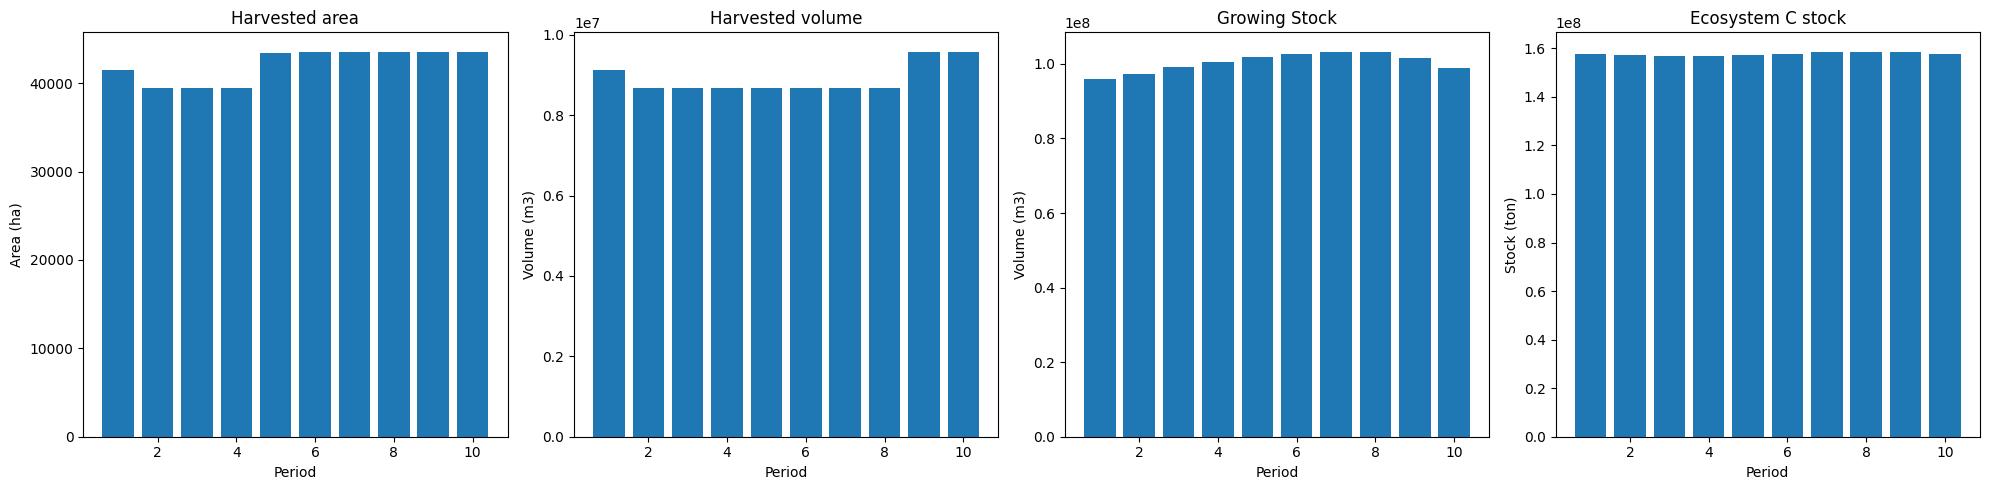

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  94087
The economic indicator (the provincial government revenues) is:  3208573
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


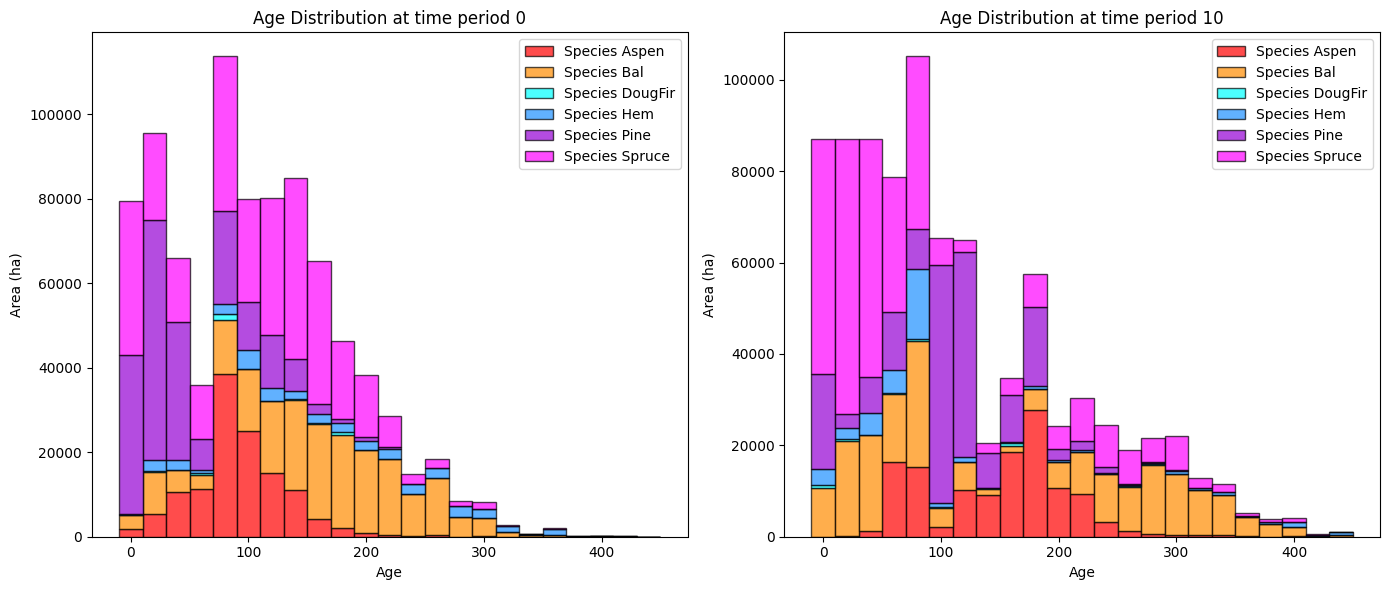

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0            10    Difference
Hem      19152.127229   6336.259592 -12815.867637
DougFir    947.047810   1486.896012    539.848202
Bal      59315.970469  82610.623426  23294.652957
Spruce   36410.744598  53027.466135  16616.721537
Aspen    29632.731169  86224.058762  56591.327592
Pine      7432.733686  38253.569262  30820.835576

Overall diversity has **increased** by 115047.52 hectares from time period 0 to time period 10.


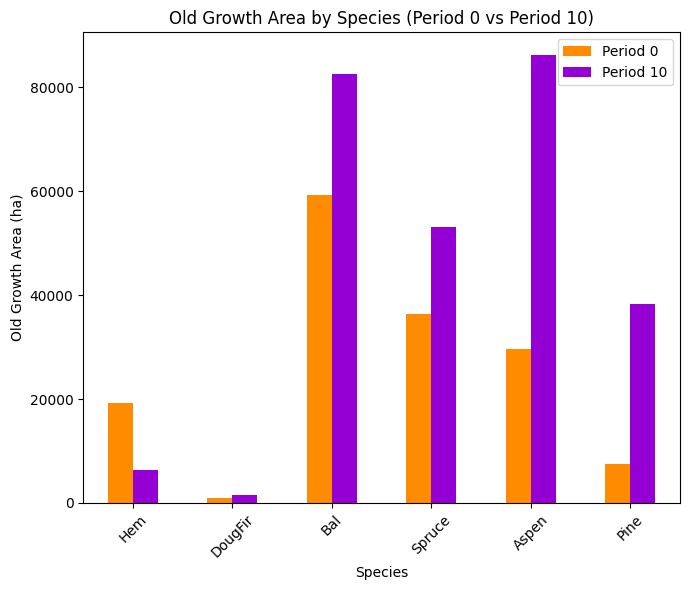

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7260

Diversity has **decreased** by 3.32% from time 0 to time 10.


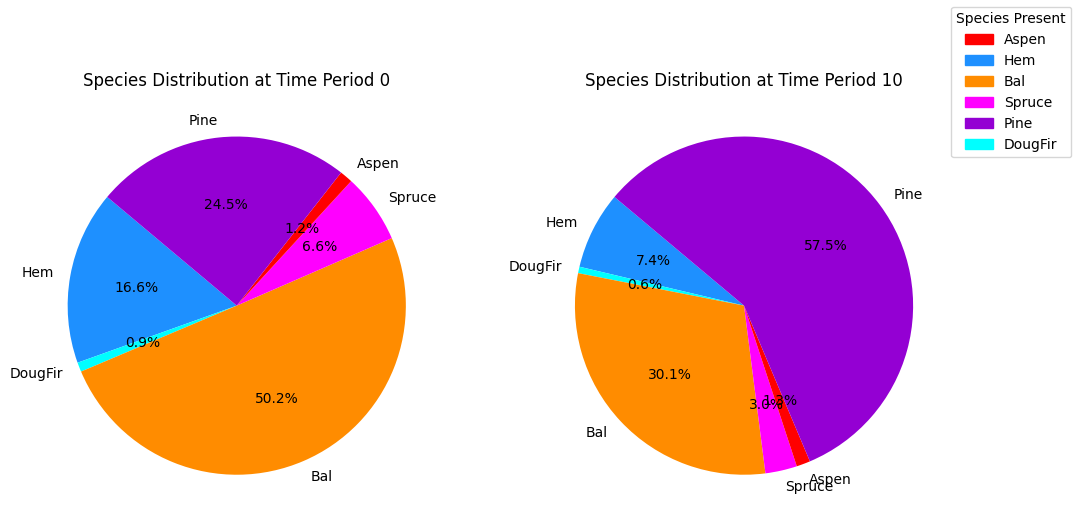

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_species_pie.pdf


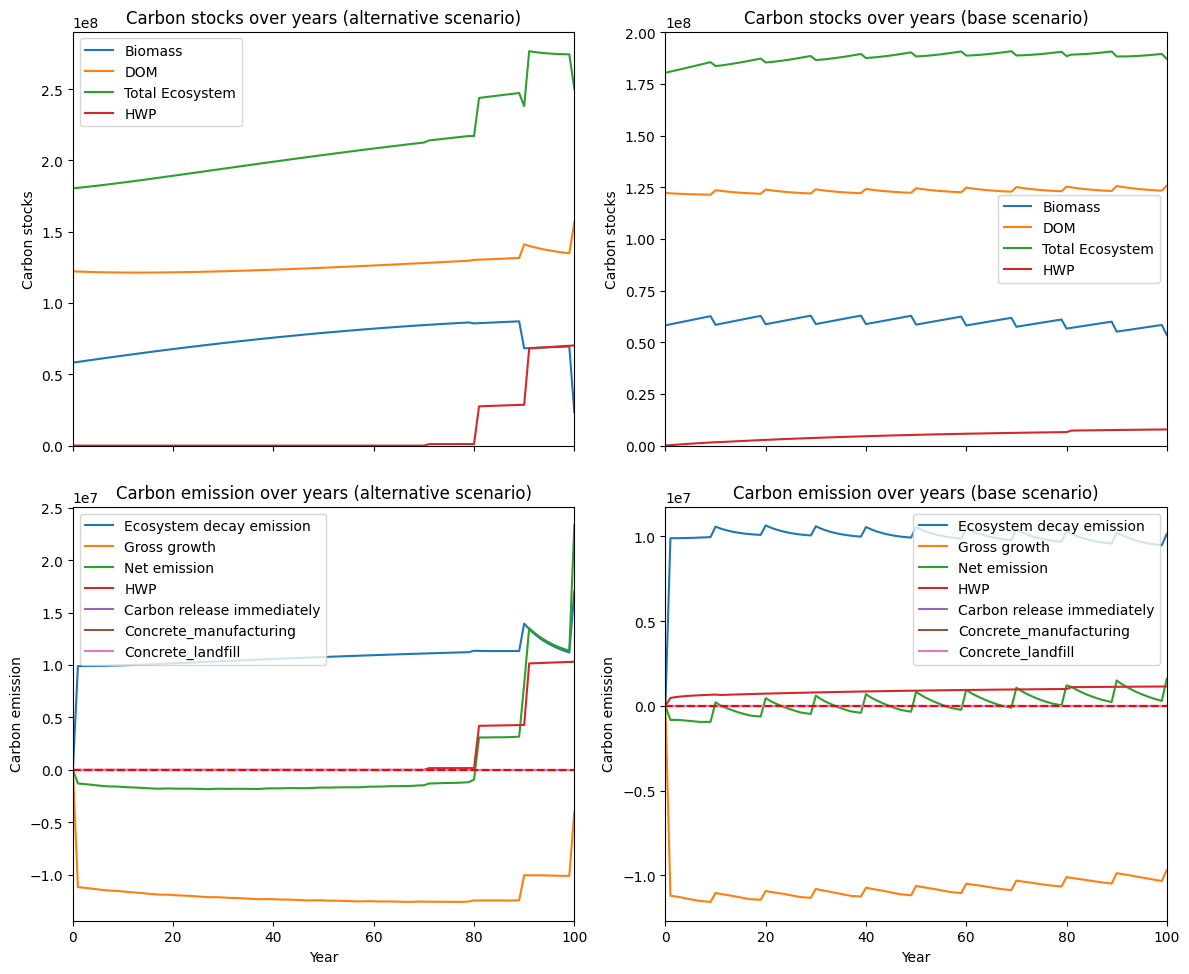

---------------------------------------------------------------------------------------
Net emission difference -29261759.64593188
Net emission base scenario -39533774.029656515
Net emission alternative scenario -10272014.383724635
dollar_per_ton is:  0.3417429478267979
Comparison of Old Growth Areas (Alternative - Base)
           0            10    Difference
Hem      0.0   -209.385029   -209.385029
DougFir  0.0  -1099.719628  -1099.719628
Bal      0.0  -2728.435771  -2728.435771
Spruce   0.0   -478.761144   -478.761144
Aspen    0.0 -24280.547193 -24280.547193
Pine     0.0 -31531.979211 -31531.979211

Overall, the old growth area has **decreased** by -60328.83 hectares in the alternative scenario compared to the base scenario.


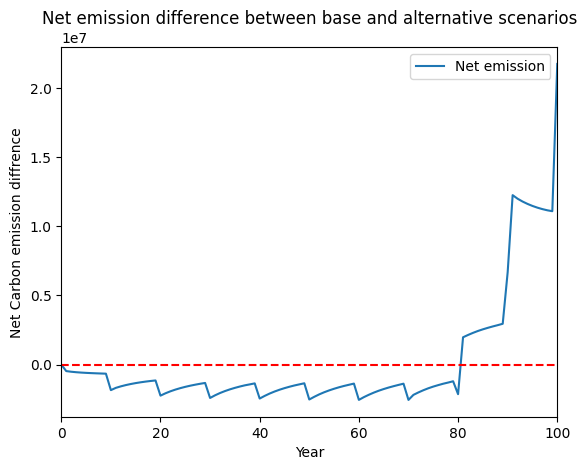

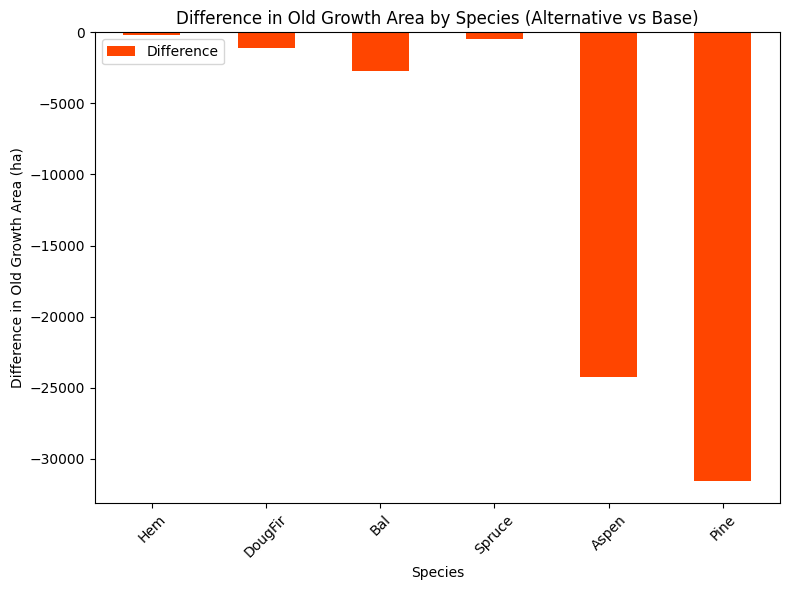

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_kpi_age_difference.pdf


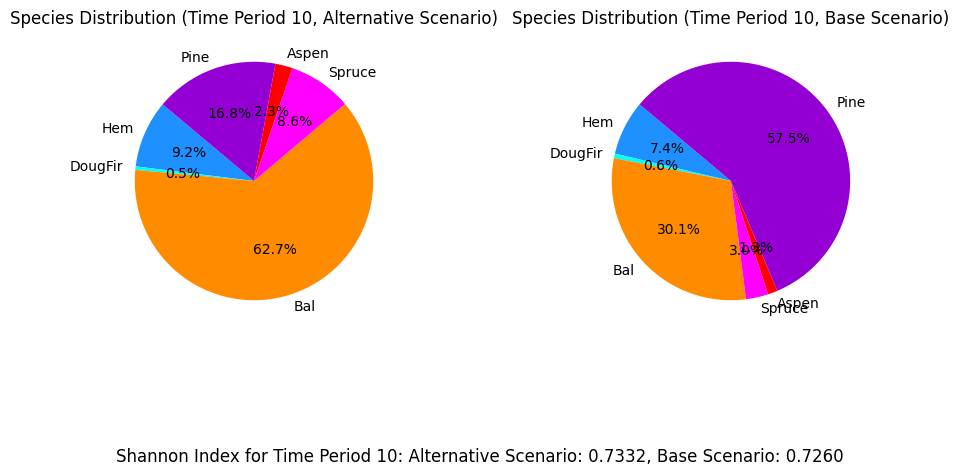

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for equitysilver_max_st_evenflow_cons...
running even flow constraints scenario
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17063 rows, 83258 columns and 514878 nonzeros
Model fingerprint: 0xecd46a48
Coefficient statistics:
  Matrix range     [5e-03, 6e+05]
  Objective range  [4e+01, 7e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+00]
Presolve removed 8690 rows and 8883 columns
Presolve time: 0.25s
Presolved: 8373 rows, 74375 columns, 486425 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Orde

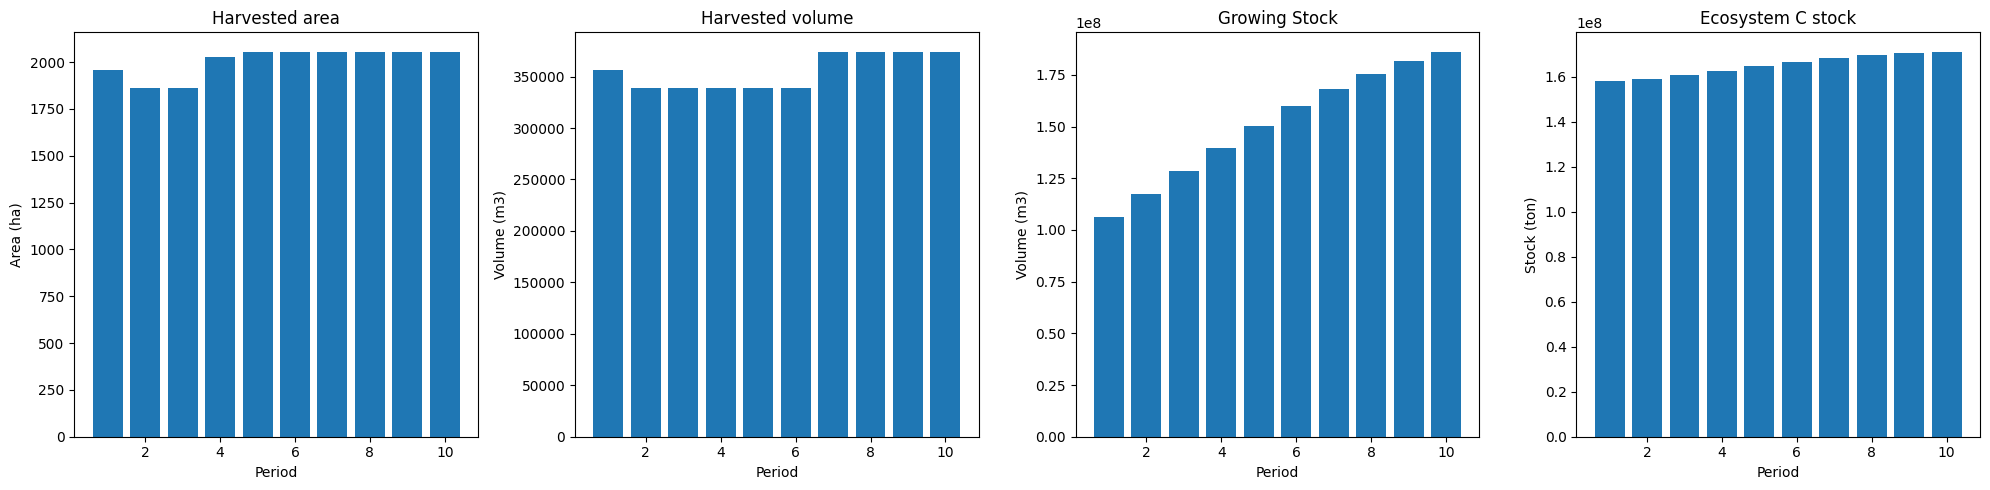

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_evenflow_cons_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  3749
The economic indicator (the provincial government revenues) is:  127876
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


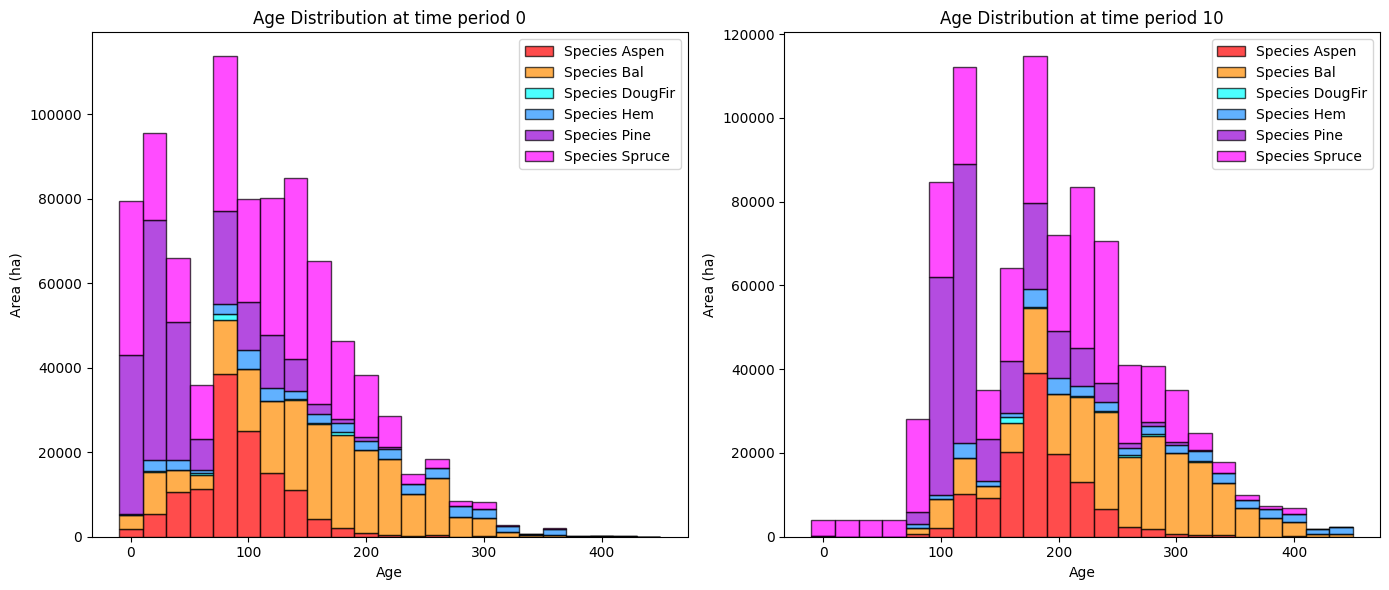

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_evenflow_cons_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0             10     Difference
Hem      19152.127229   31829.081127   12676.953898
DougFir    947.047810    2749.298212    1802.250402
Bal      59315.970469  157559.823875   98243.853406
Spruce   36410.744598  182243.305432  145832.560834
Aspen    29632.731169  118345.834248   88713.103079
Pine      7432.733686   70472.832742   63040.099056

Overall diversity has **increased** by 410308.82 hectares from time period 0 to time period 10.


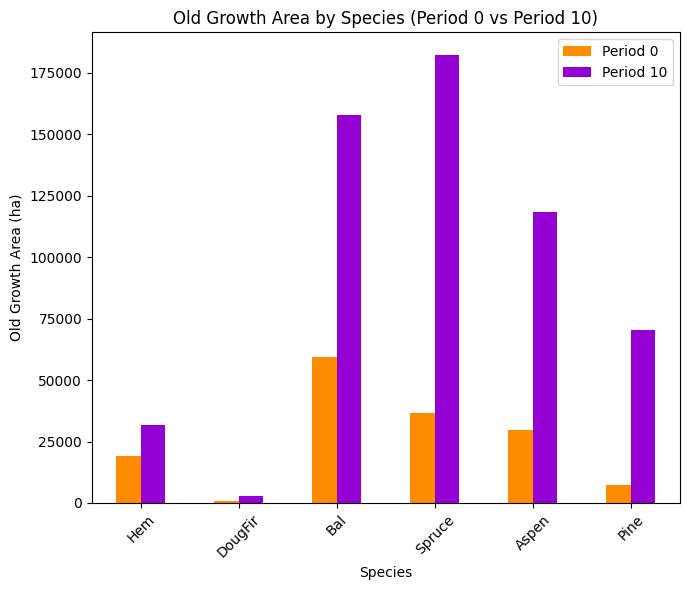

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_evenflow_cons_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7382

Diversity has **decreased** by 2.10% from time 0 to time 10.


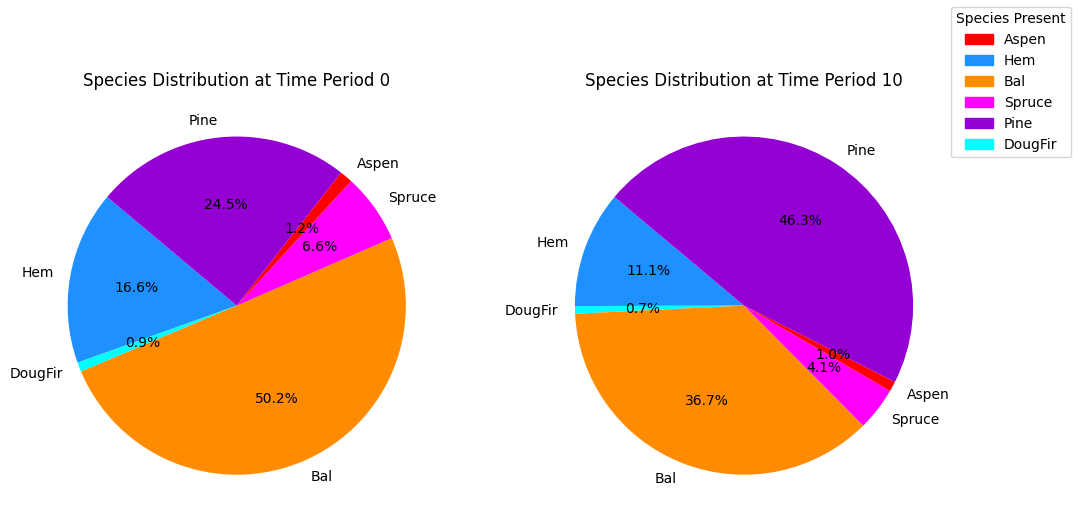

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_evenflow_cons_species_pie.pdf
running business as usual scenario for the Equity Silver mining site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0x9ff13077
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [4e+01, 7e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8883 columns
Presolve time: 0.27s
Presolved: 8375 rows, 74376 columns, 536315 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Orde

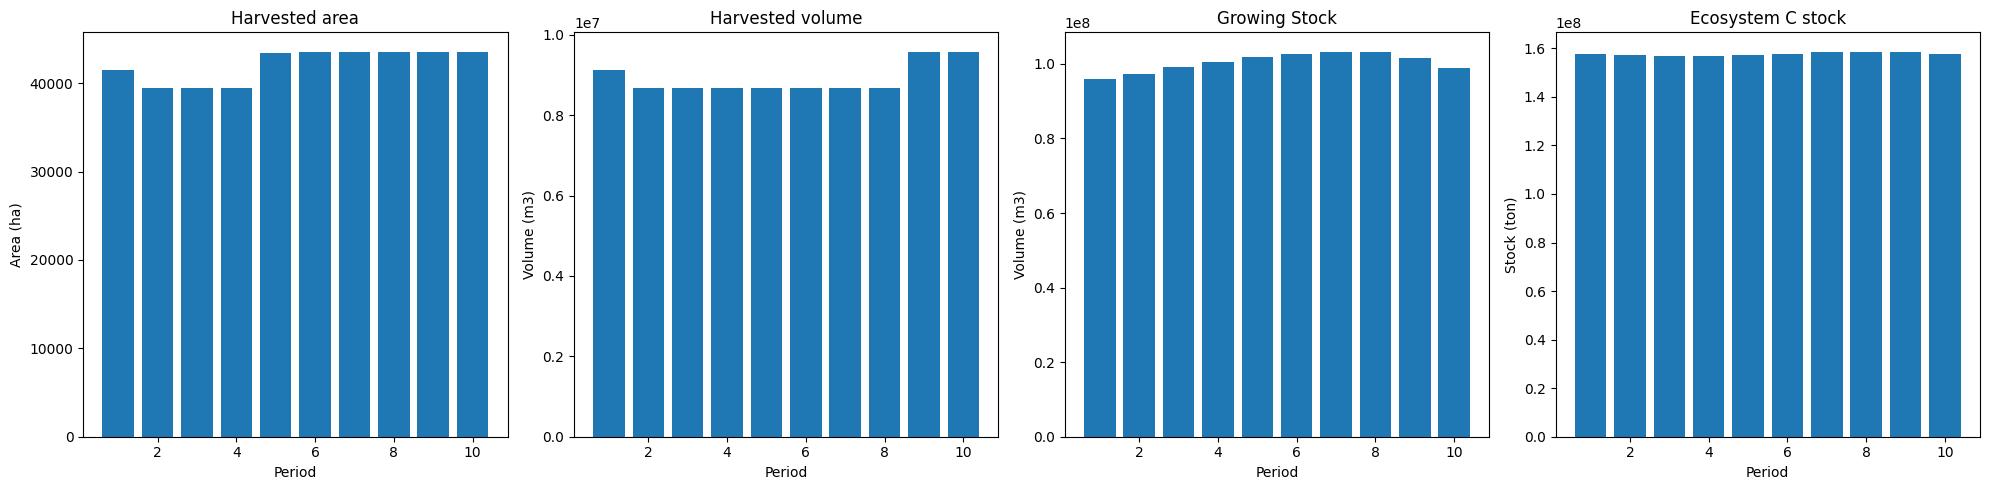

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  94087
The economic indicator (the provincial government revenues) is:  3208573
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


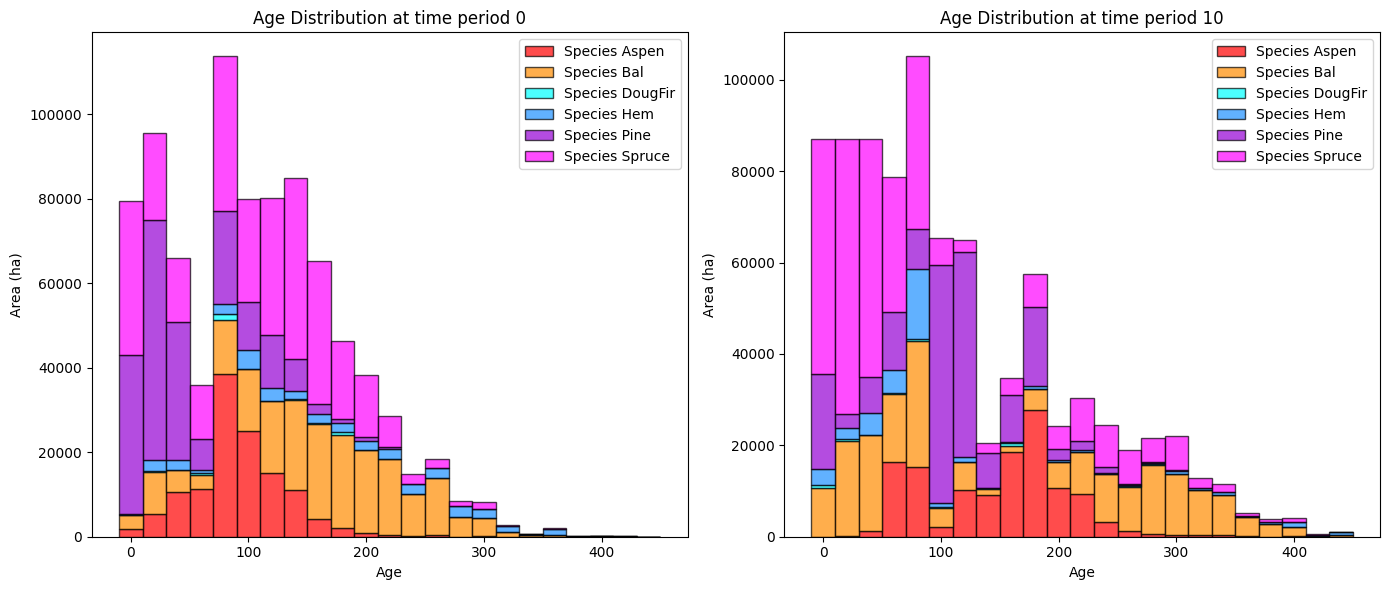

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0            10    Difference
Hem      19152.127229   6336.259592 -12815.867637
DougFir    947.047810   1486.896012    539.848202
Bal      59315.970469  82610.623426  23294.652957
Spruce   36410.744598  53027.466135  16616.721537
Aspen    29632.731169  86224.058762  56591.327592
Pine      7432.733686  38253.569262  30820.835576

Overall diversity has **increased** by 115047.52 hectares from time period 0 to time period 10.


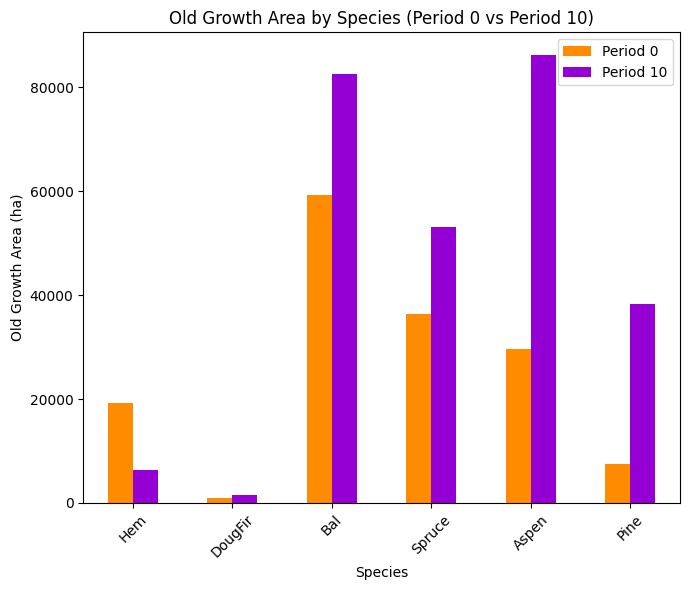

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7260

Diversity has **decreased** by 3.32% from time 0 to time 10.


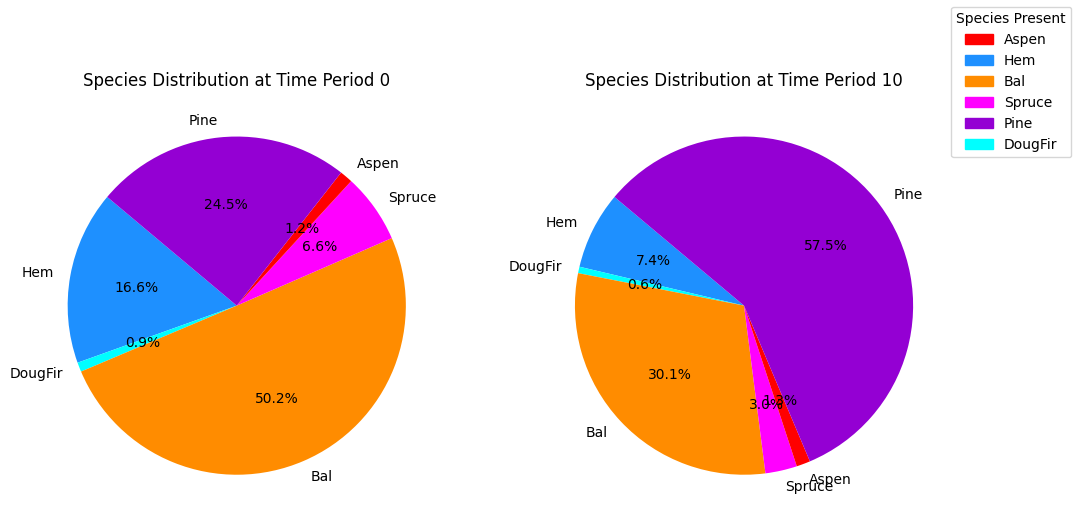

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_species_pie.pdf


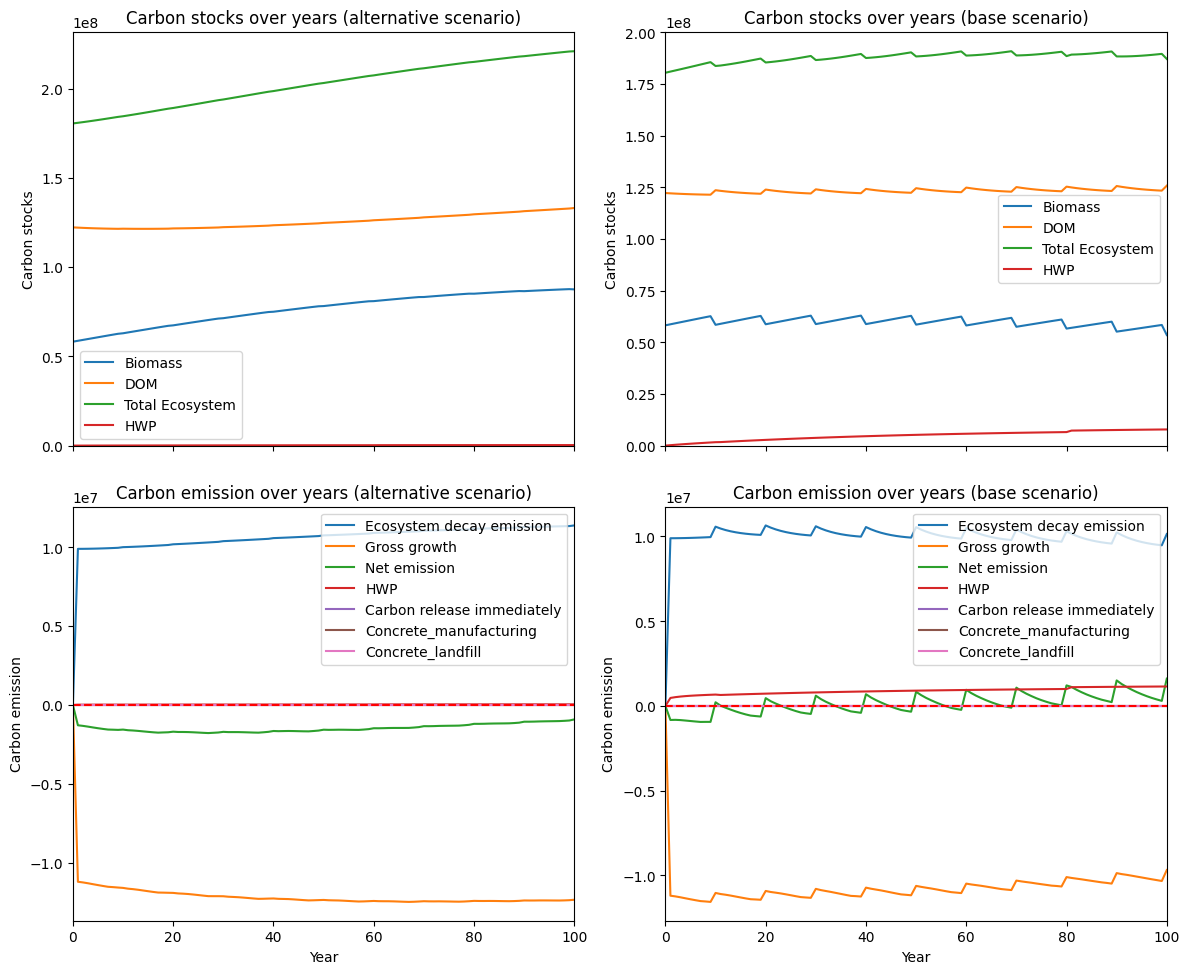

---------------------------------------------------------------------------------------
Net emission difference -28016208.25107561
Net emission base scenario -38288222.63480025
Net emission alternative scenario -10272014.383724635
dollar_per_ton is:  0.3569362388508115
Comparison of Old Growth Areas (Alternative - Base)
           0             10     Difference
Hem      0.0   25492.821535   25492.821535
DougFir  0.0    1262.402200    1262.402200
Bal      0.0   74949.200449   74949.200449
Spruce   0.0  129215.839297  129215.839297
Aspen    0.0   32121.775486   32121.775486
Pine     0.0   32219.263479   32219.263479

Overall, the old growth area has **increased** by 295261.30 hectares in the alternative scenario compared to the base scenario.


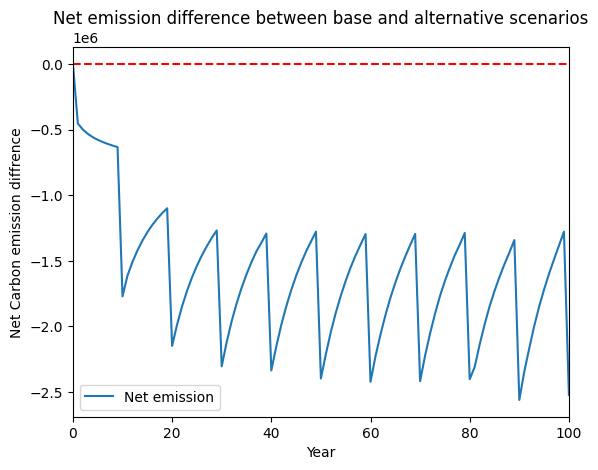

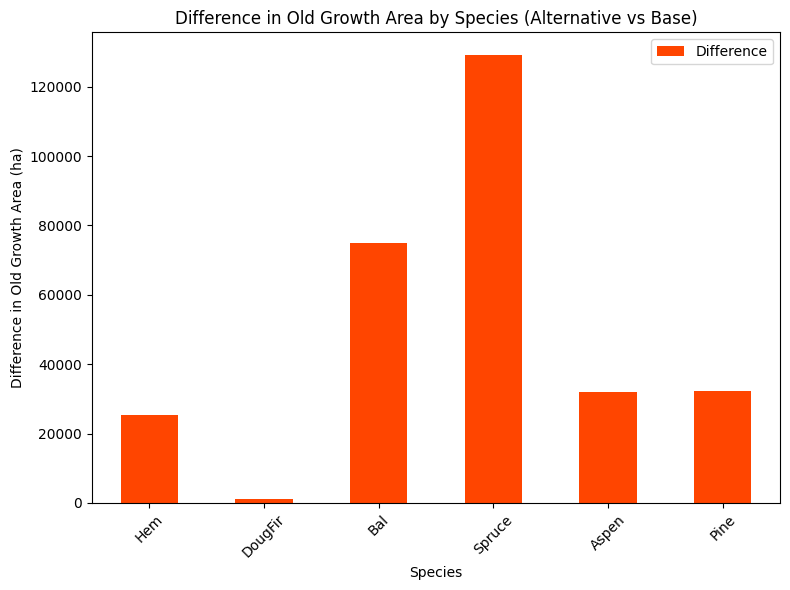

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_kpi_age_difference.pdf


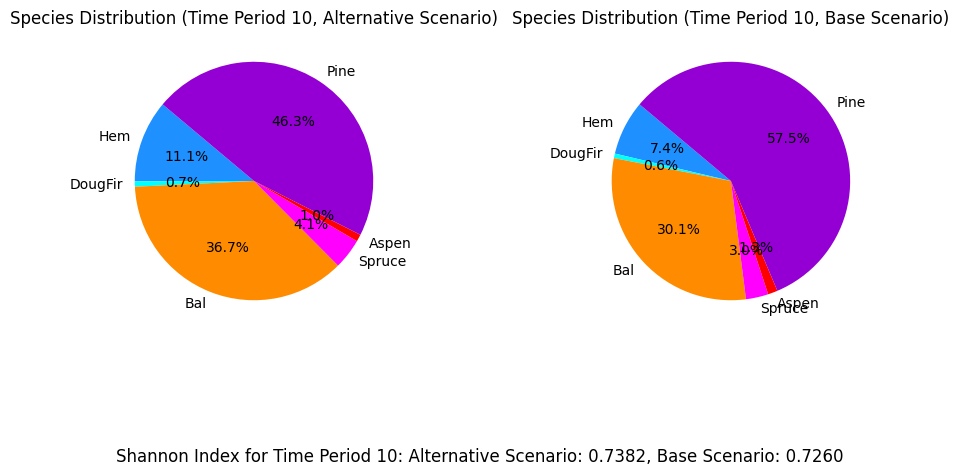

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for equitysilver_max_st_eqtslvr_AAC_90%...
running the scenario for the Equity Silver mining site (90%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0x8abf8e59
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [4e+01, 7e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8883 columns
Presolve time: 0.23s
Presolved: 8375 r

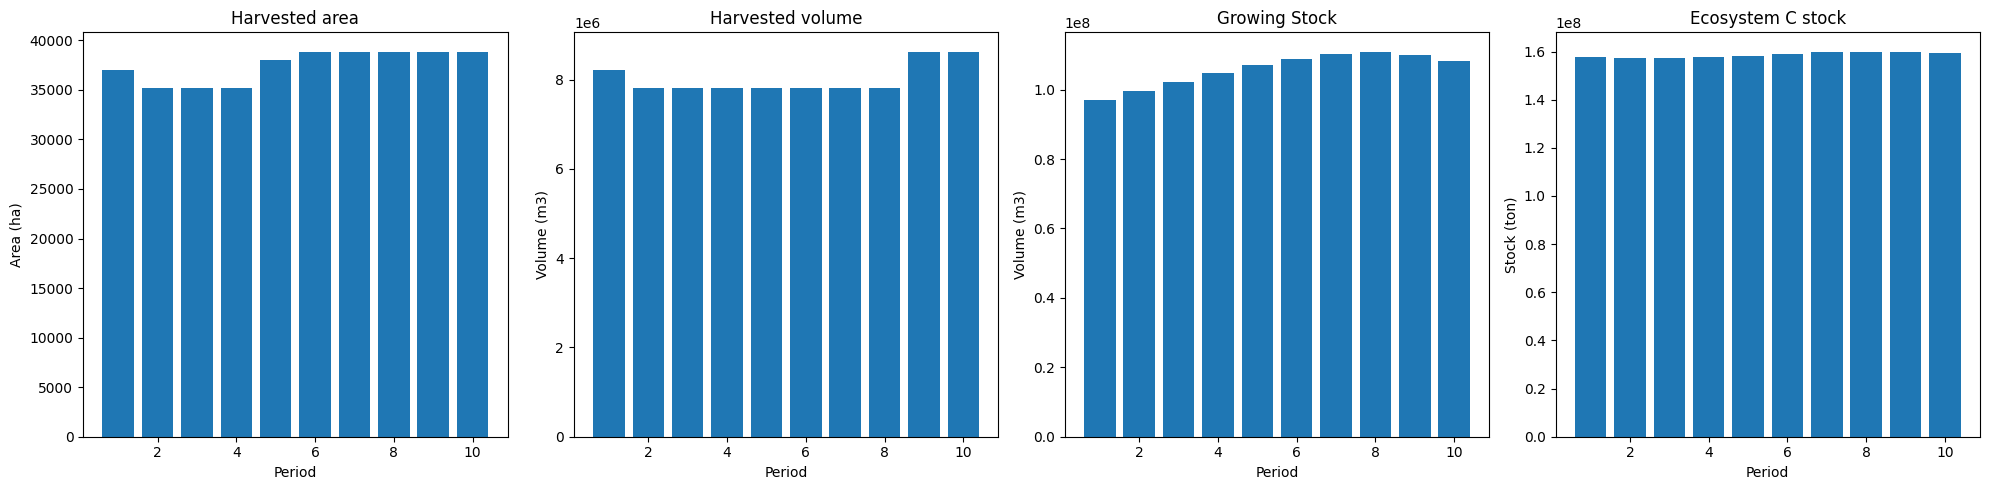

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_90%_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  84678
The economic indicator (the provincial government revenues) is:  2887716
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


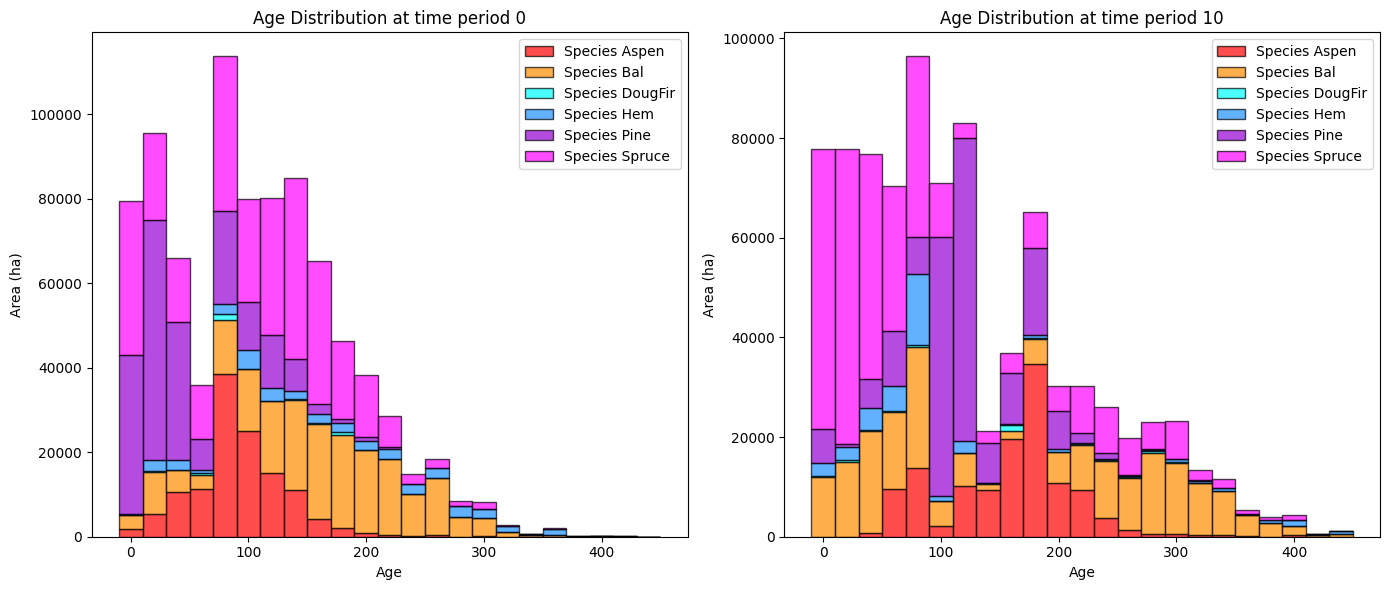

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_90%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0            10    Difference
Hem      19152.127229   7216.472254 -11935.654975
DougFir    947.047810   1856.189930    909.142120
Bal      59315.970469  88278.443522  28962.473053
Spruce   36410.744598  53152.448451  16741.703853
Aspen    29632.731169  95000.428083  65367.696914
Pine      7432.733686  47249.209376  39816.475689

Overall diversity has **increased** by 139861.84 hectares from time period 0 to time period 10.


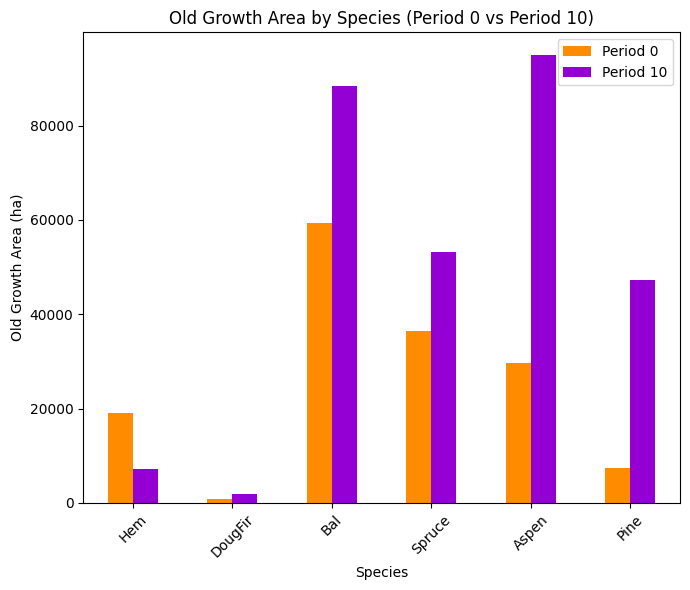

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_90%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7176

Diversity has **decreased** by 4.16% from time 0 to time 10.


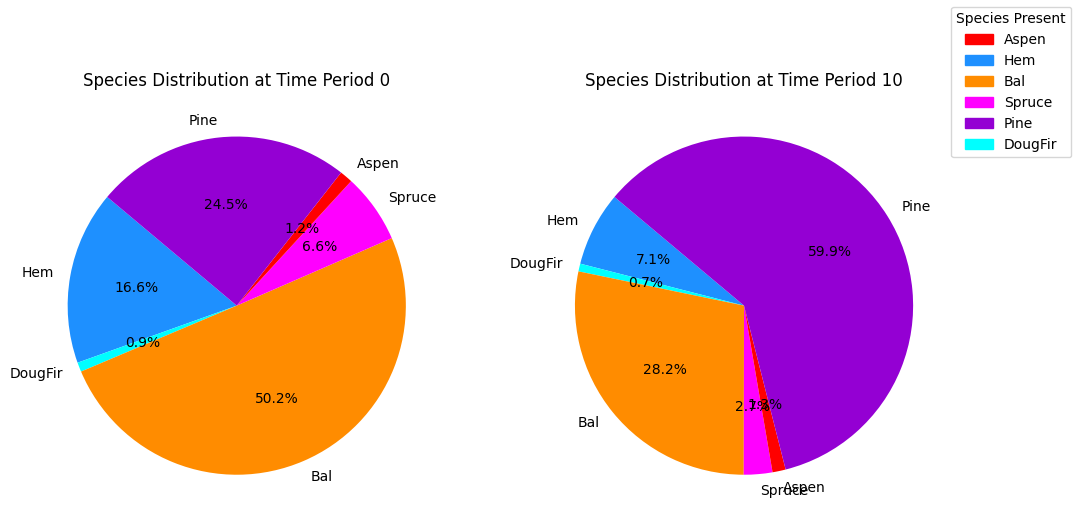

Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0x9ff13077
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [4e+01, 7e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8883 columns
Presolve time: 0.23s
Presolved: 8375 rows, 74376 columns, 536315 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.01s

Barrier statistics:
 AA' NZ     : 2.583e+05
 Factor NZ  : 3.385e+05 (roughly 36 MB of memory)
 Factor Ops : 1.590e+07 (less than 1 second per iteration)
 Threads    : 14

   

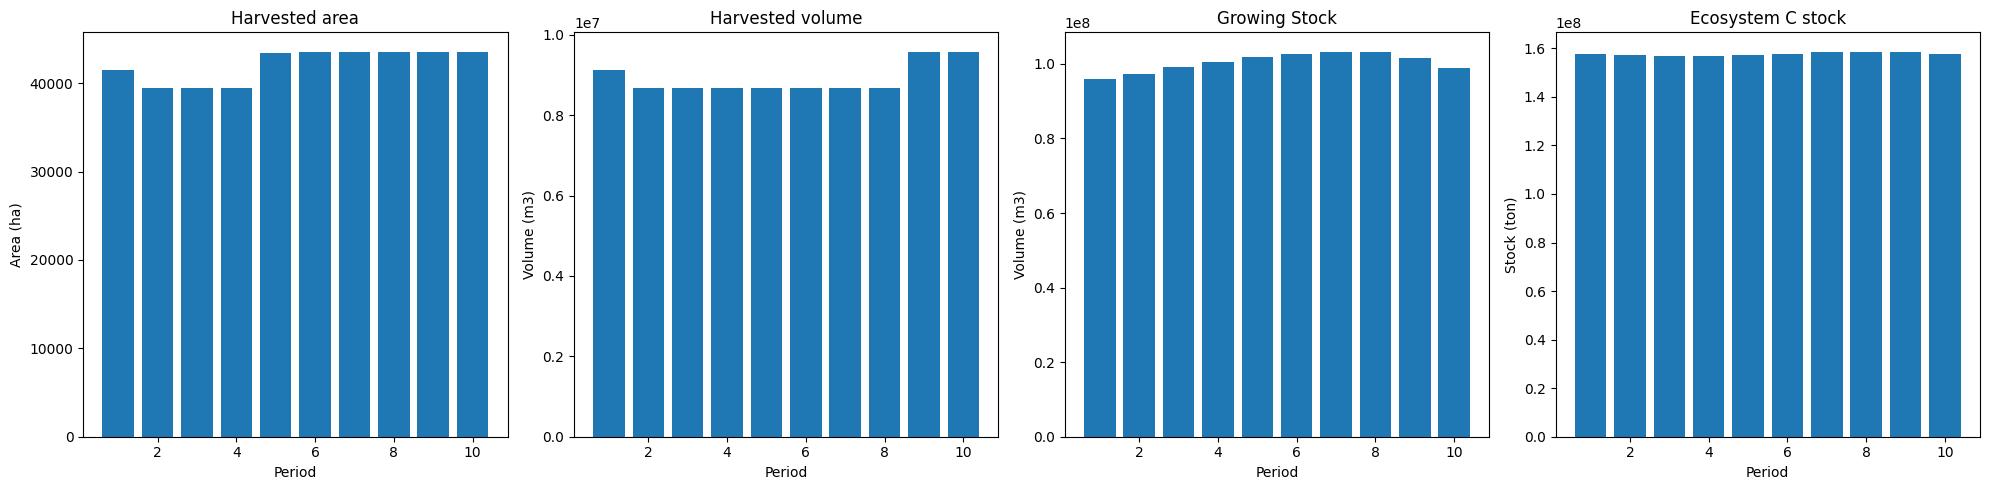

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  94087
The economic indicator (the provincial government revenues) is:  3208573
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


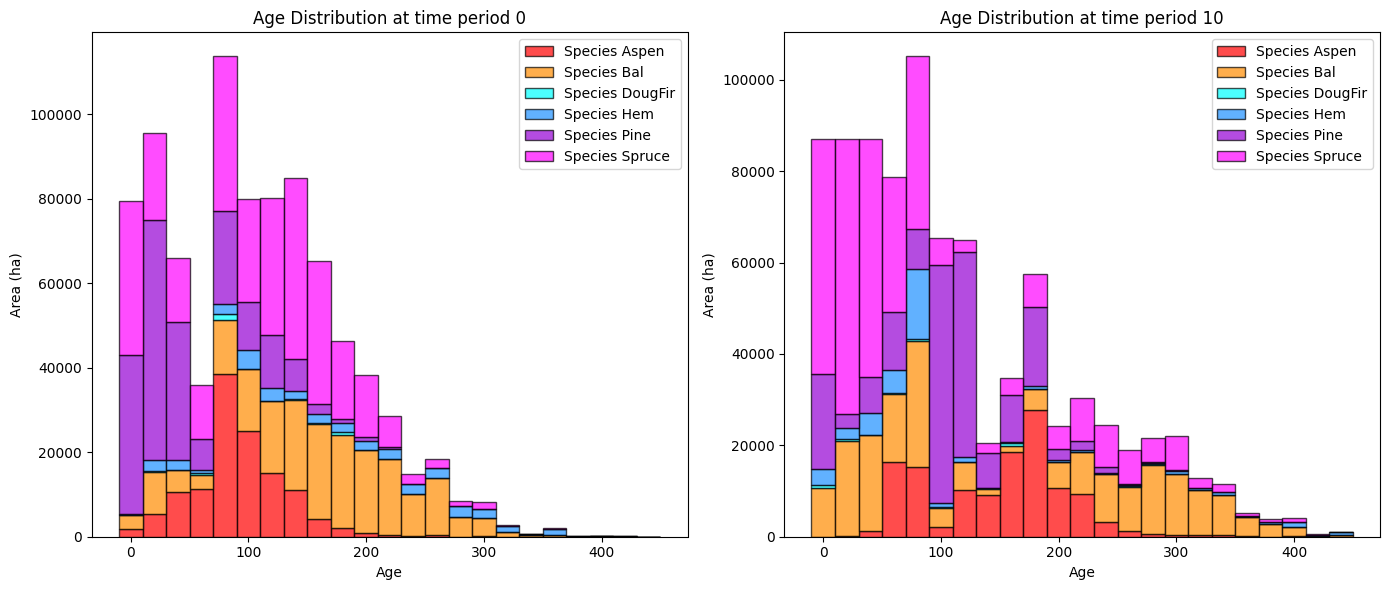

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0            10    Difference
Hem      19152.127229   6336.259592 -12815.867637
DougFir    947.047810   1486.896012    539.848202
Bal      59315.970469  82610.623426  23294.652957
Spruce   36410.744598  53027.466135  16616.721537
Aspen    29632.731169  86224.058762  56591.327592
Pine      7432.733686  38253.569262  30820.835576

Overall diversity has **increased** by 115047.52 hectares from time period 0 to time period 10.


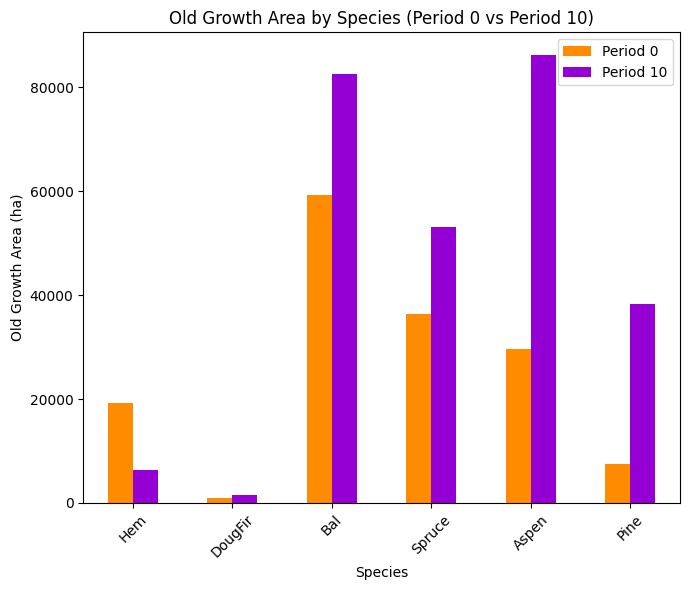

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7260

Diversity has **decreased** by 3.32% from time 0 to time 10.


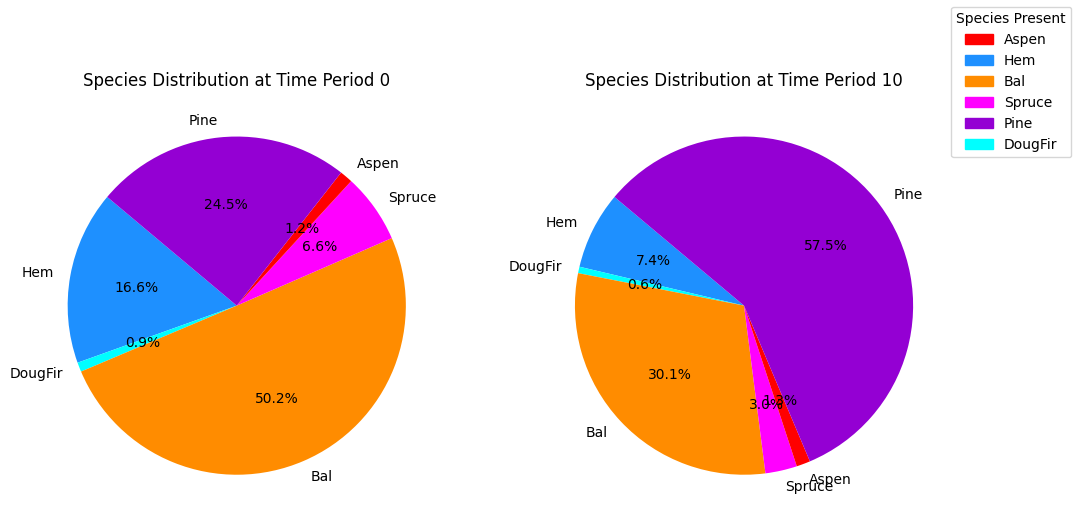

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_species_pie.pdf


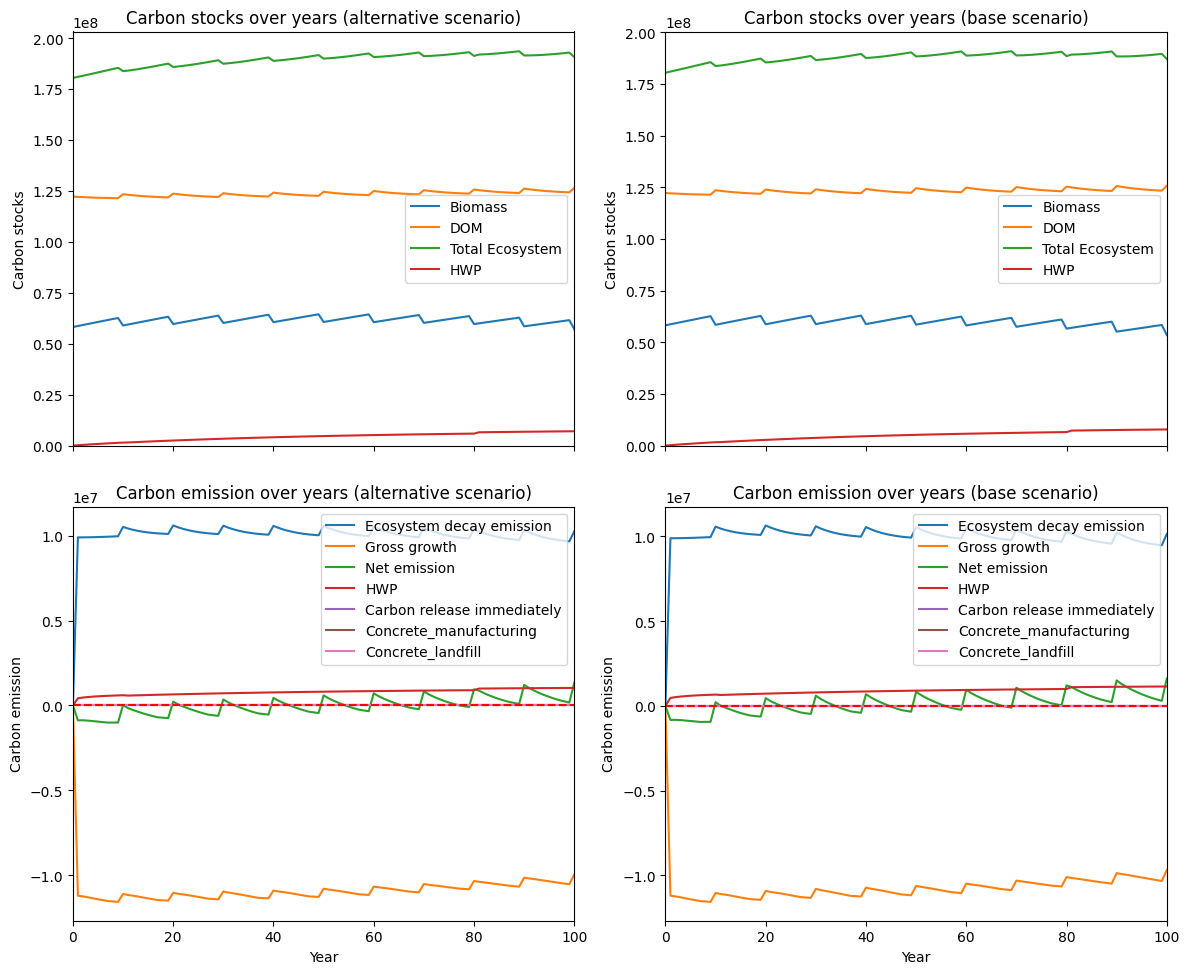

---------------------------------------------------------------------------------------
Net emission difference -3021877.978126947
Net emission base scenario -13293892.361851584
Net emission alternative scenario -10272014.383724635
dollar_per_ton is:  3.3092004615614257
Comparison of Old Growth Areas (Alternative - Base)
           0           10   Difference
Hem      0.0   880.212662   880.212662
DougFir  0.0   369.293918   369.293918
Bal      0.0  5667.820096  5667.820096
Spruce   0.0   124.982316   124.982316
Aspen    0.0  8776.369322  8776.369322
Pine     0.0  8995.640113  8995.640113

Overall, the old growth area has **increased** by 24814.32 hectares in the alternative scenario compared to the base scenario.


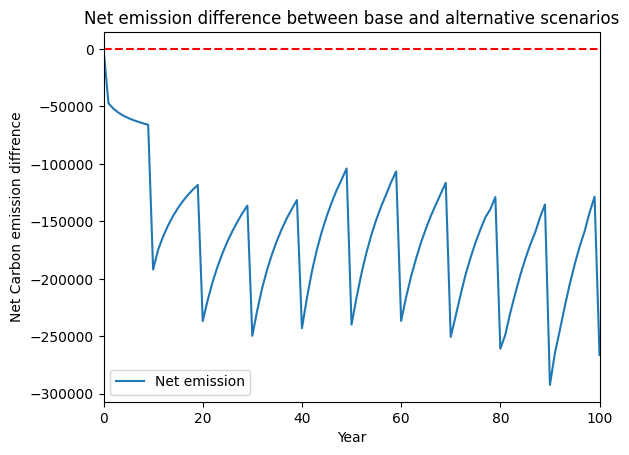

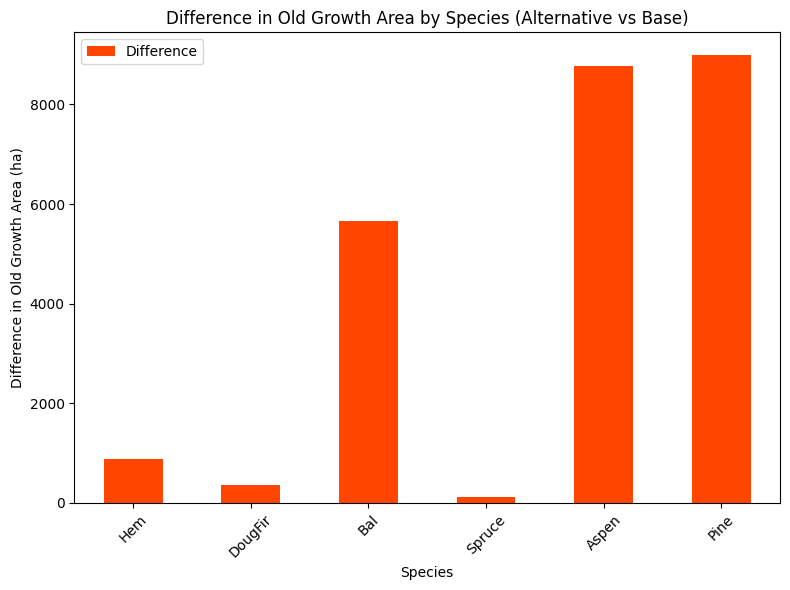

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_kpi_age_difference.pdf


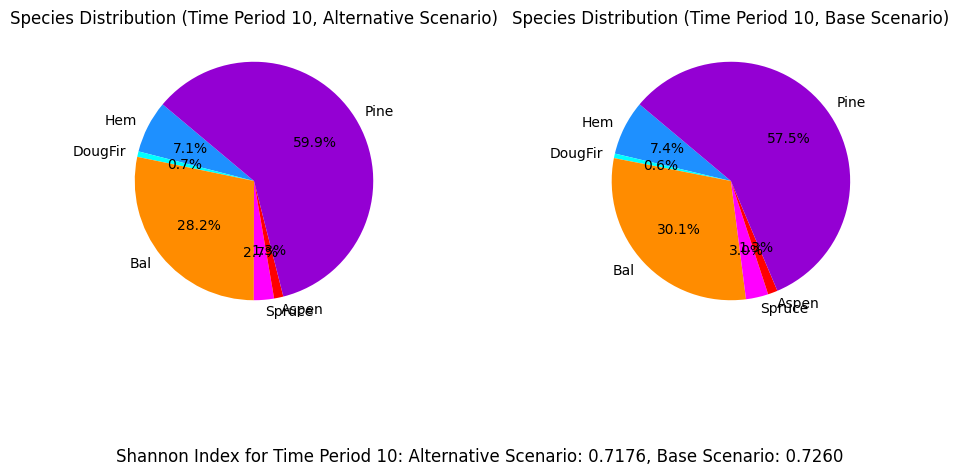

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for equitysilver_max_st_eqtslvr_AAC_80%...
running the scenario for the Equity Silver mining site (80%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0x1397ac6f
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [4e+01, 7e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8883 columns
Presolve time: 0.25s
Presolved: 8375 r

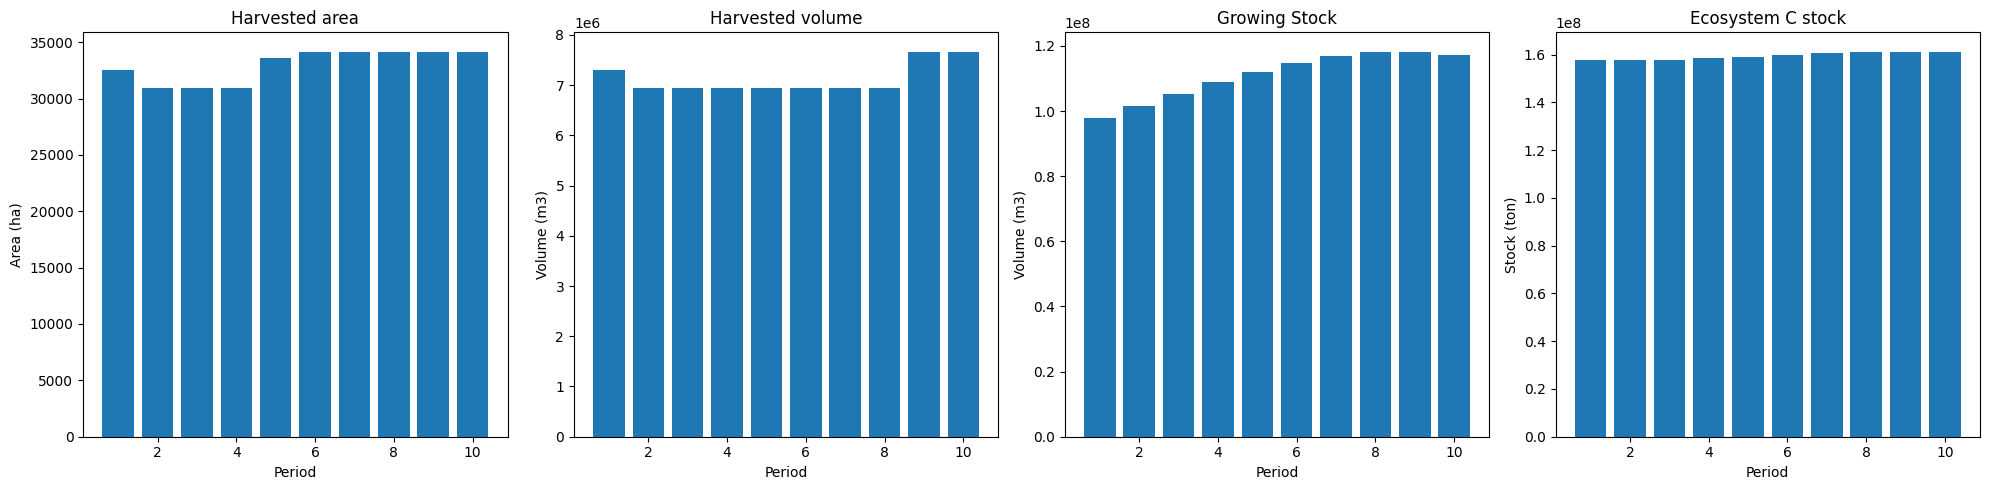

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_80%_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  75269
The economic indicator (the provincial government revenues) is:  2566858
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


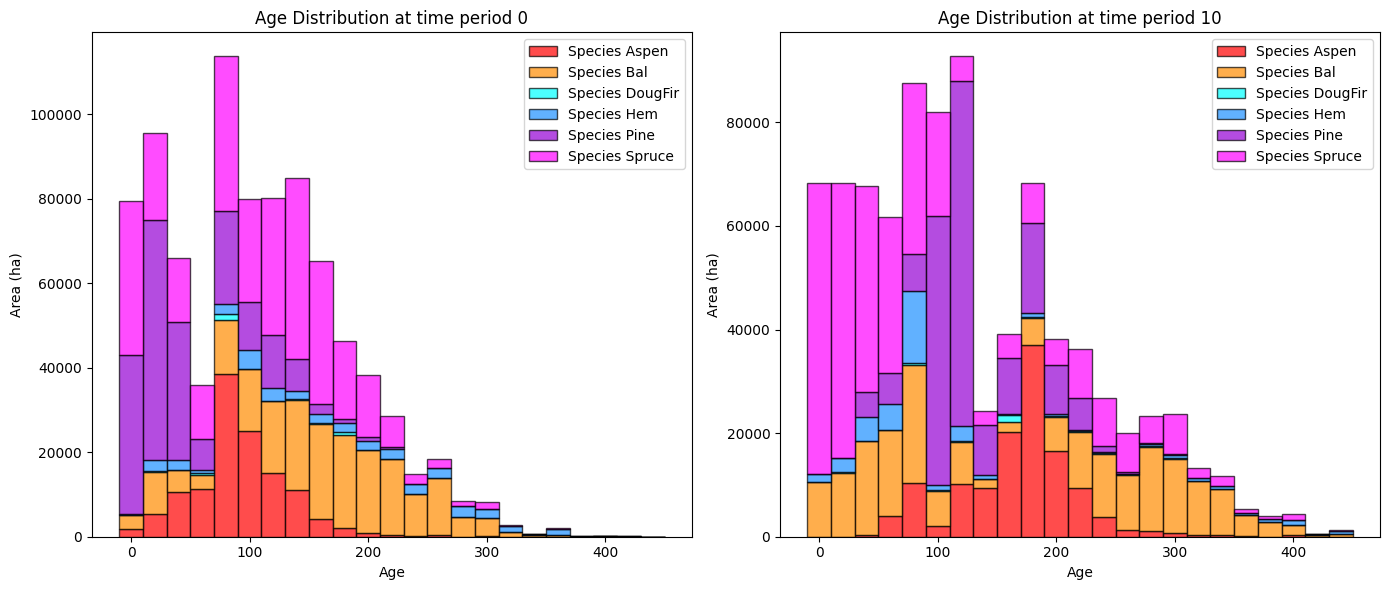

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_80%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0             10    Difference
Hem      19152.127229    7869.127036 -11283.000193
DougFir    947.047810    2013.028648   1065.980838
Bal      59315.970469   91179.949447  31863.978978
Spruce   36410.744598   53785.769019  17375.024421
Aspen    29632.731169  104619.810940  74987.079771
Pine      7432.733686   55932.861367  48500.127681

Overall diversity has **increased** by 162509.19 hectares from time period 0 to time period 10.


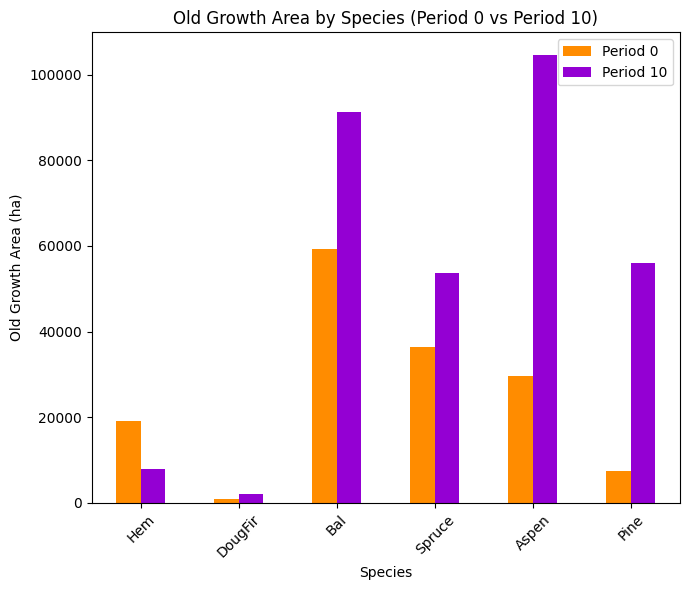

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_80%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7166

Diversity has **decreased** by 4.26% from time 0 to time 10.


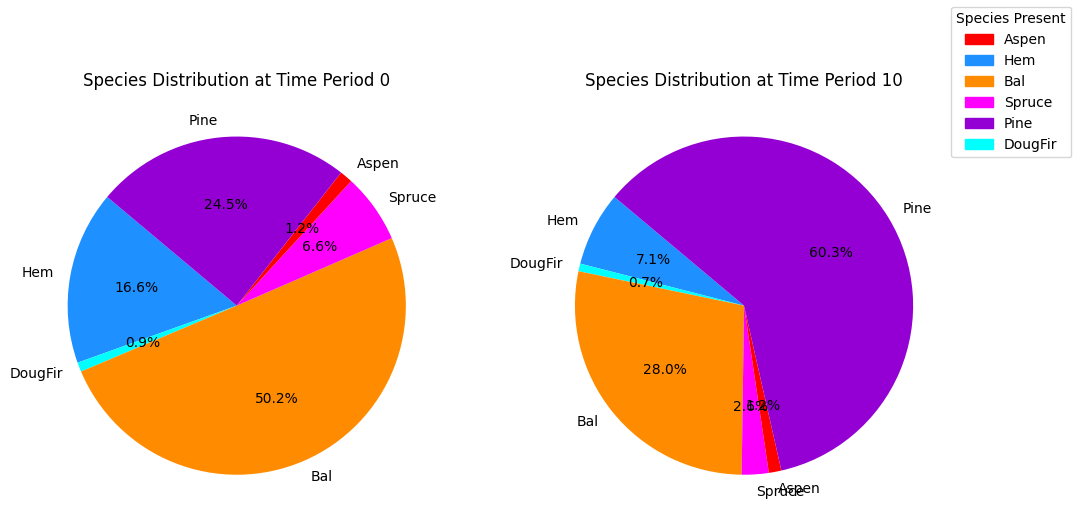

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_80%_species_pie.pdf
running business as usual scenario for the Equity Silver mining site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0x9ff13077
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [4e+01, 7e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8883 columns
Presolve time: 0.27s
Presolved: 8375 rows, 74376 columns, 536315 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Or

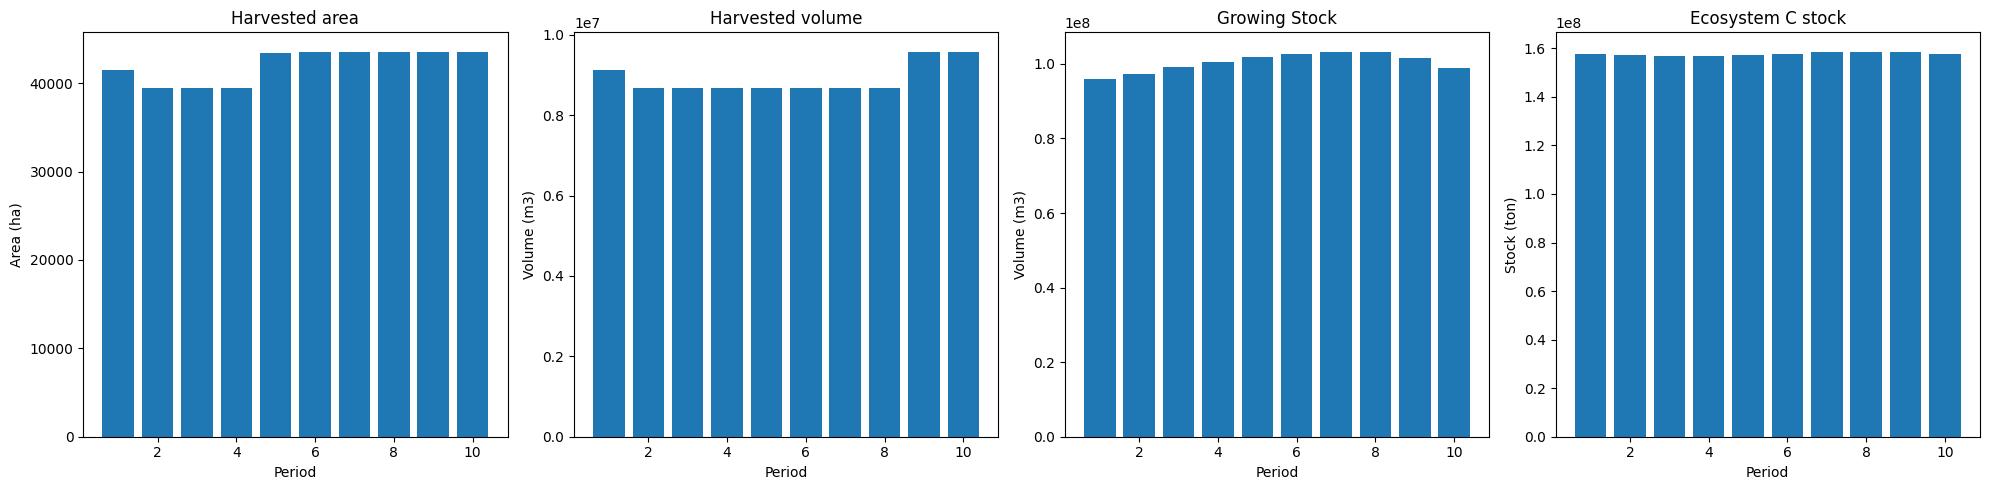

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  94087
The economic indicator (the provincial government revenues) is:  3208573
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


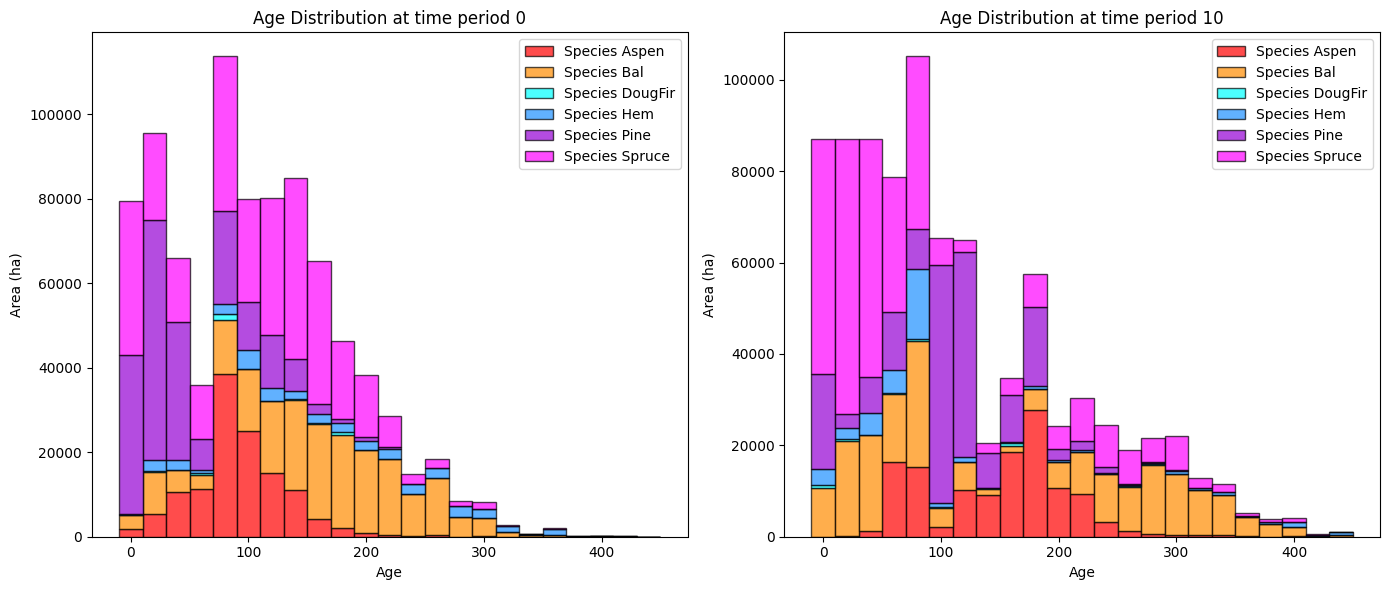

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0            10    Difference
Hem      19152.127229   6336.259592 -12815.867637
DougFir    947.047810   1486.896012    539.848202
Bal      59315.970469  82610.623426  23294.652957
Spruce   36410.744598  53027.466135  16616.721537
Aspen    29632.731169  86224.058762  56591.327592
Pine      7432.733686  38253.569262  30820.835576

Overall diversity has **increased** by 115047.52 hectares from time period 0 to time period 10.


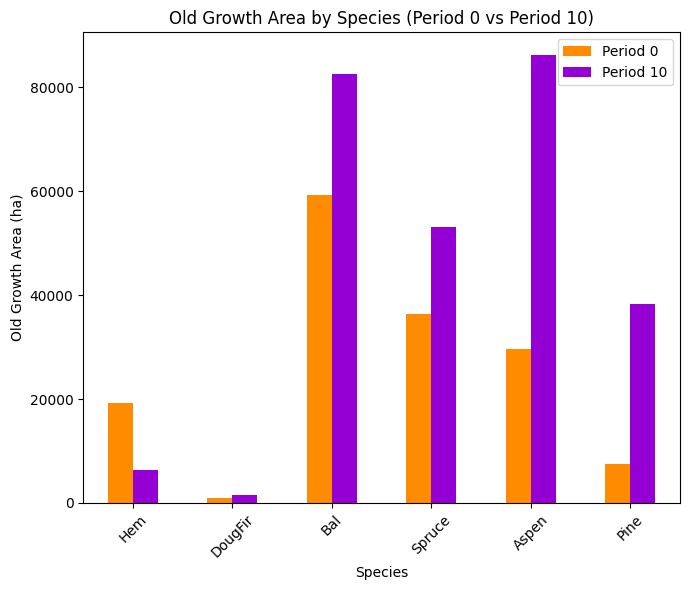

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7260

Diversity has **decreased** by 3.32% from time 0 to time 10.


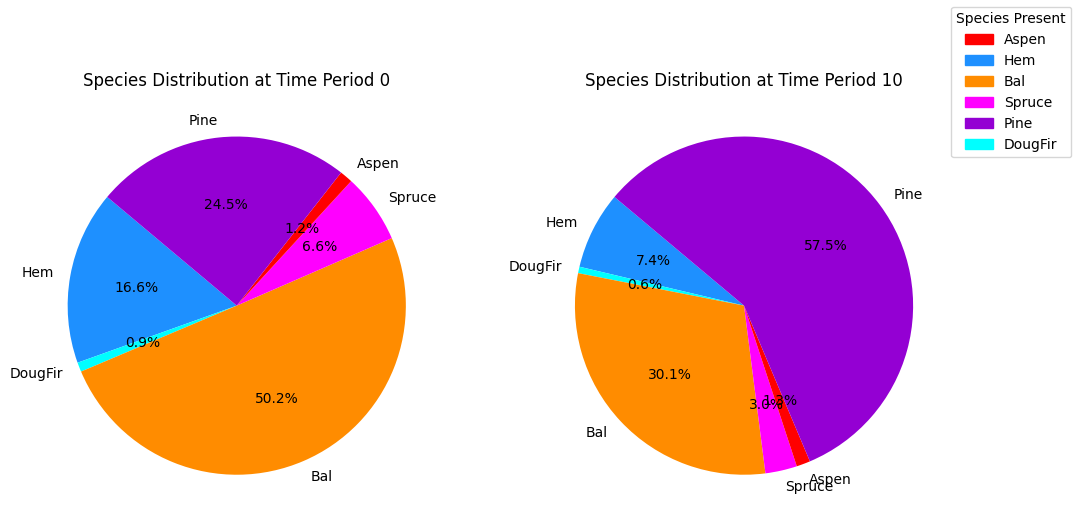

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_species_pie.pdf


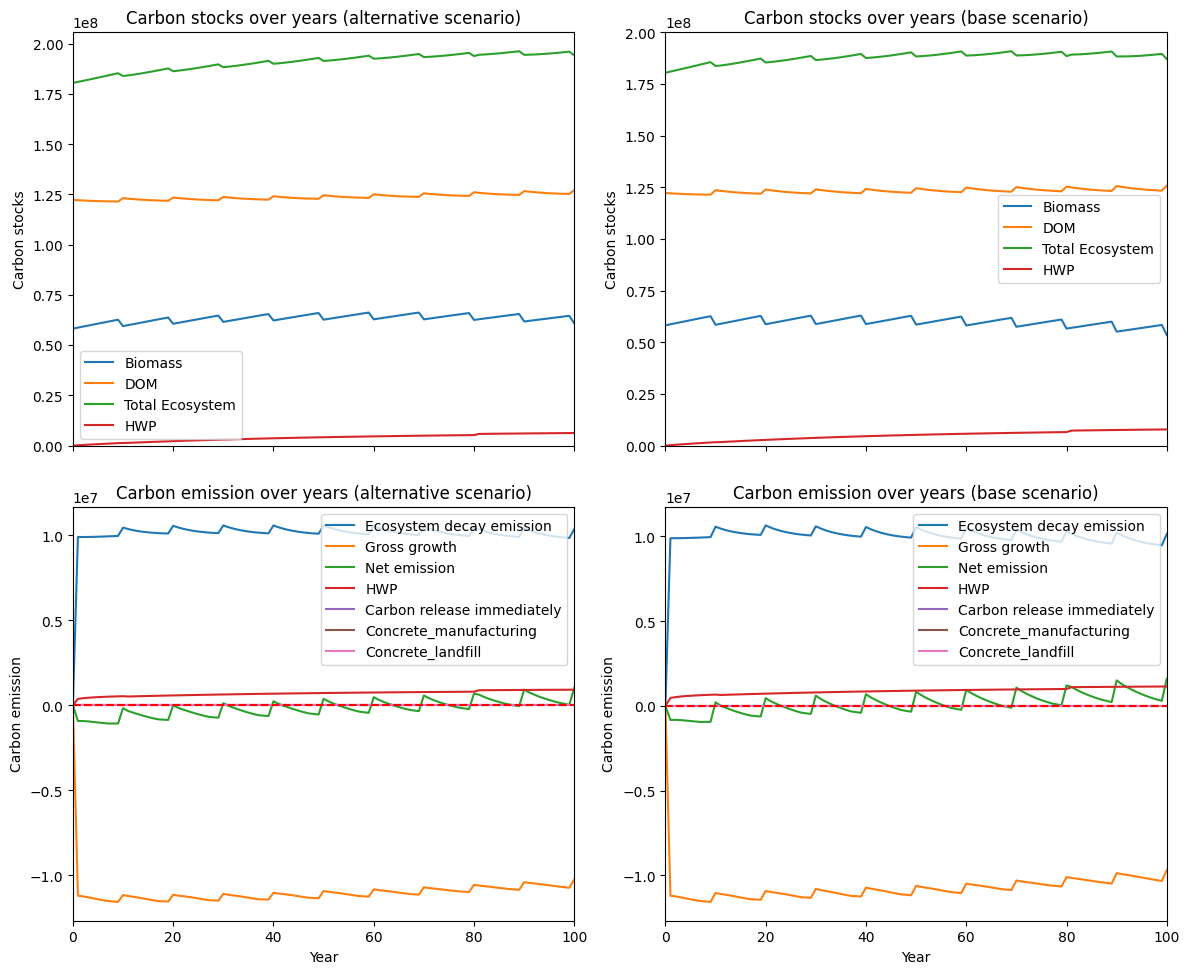

---------------------------------------------------------------------------------------
Net emission difference -5997660.158636186
Net emission base scenario -16269674.542360822
Net emission alternative scenario -10272014.383724635
dollar_per_ton is:  1.6673168761655728
Comparison of Old Growth Areas (Alternative - Base)
           0            10    Difference
Hem      0.0   1532.867444   1532.867444
DougFir  0.0    526.132636    526.132636
Bal      0.0   8569.326021   8569.326021
Spruce   0.0    758.302884    758.302884
Aspen    0.0  18395.752179  18395.752179
Pine     0.0  17679.292105  17679.292105

Overall, the old growth area has **increased** by 47461.67 hectares in the alternative scenario compared to the base scenario.


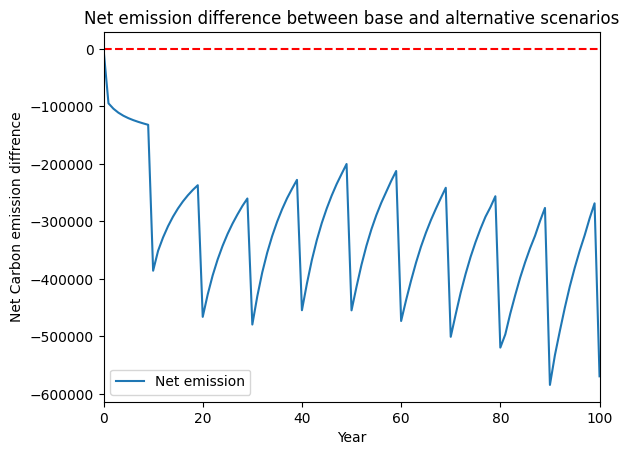

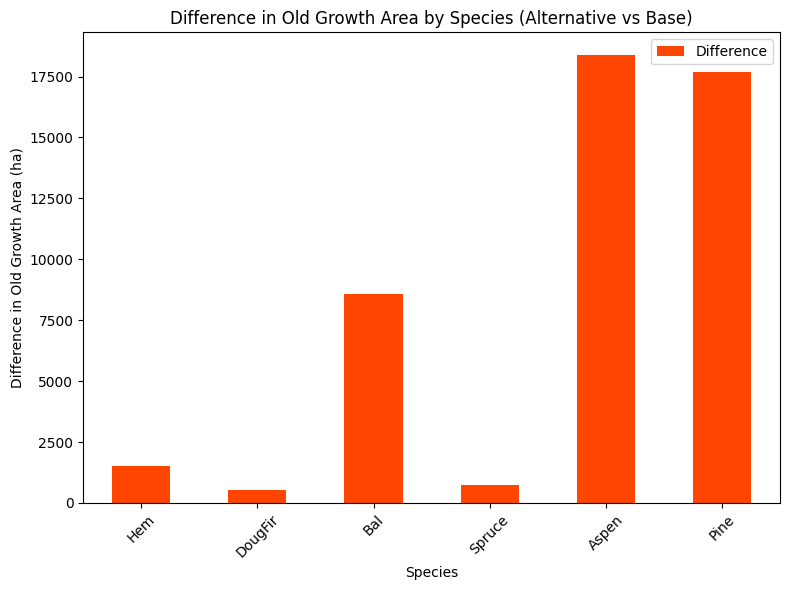

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_kpi_age_difference.pdf


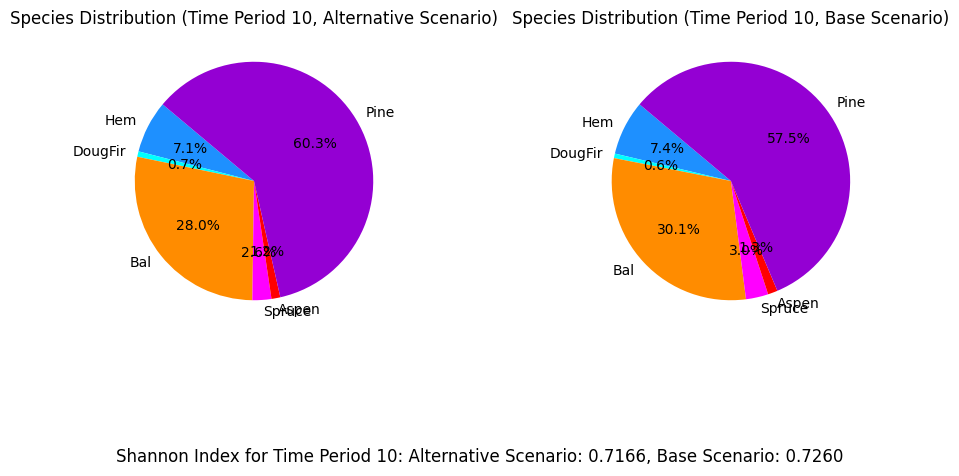

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for equitysilver_max_st_eqtslvr_AAC_70%...
running the scenario for the Equity Silver mining site (70%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0x2e1a6d46
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [4e+01, 7e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8883 columns
Presolve time: 0.24s
Presolved: 8375 r

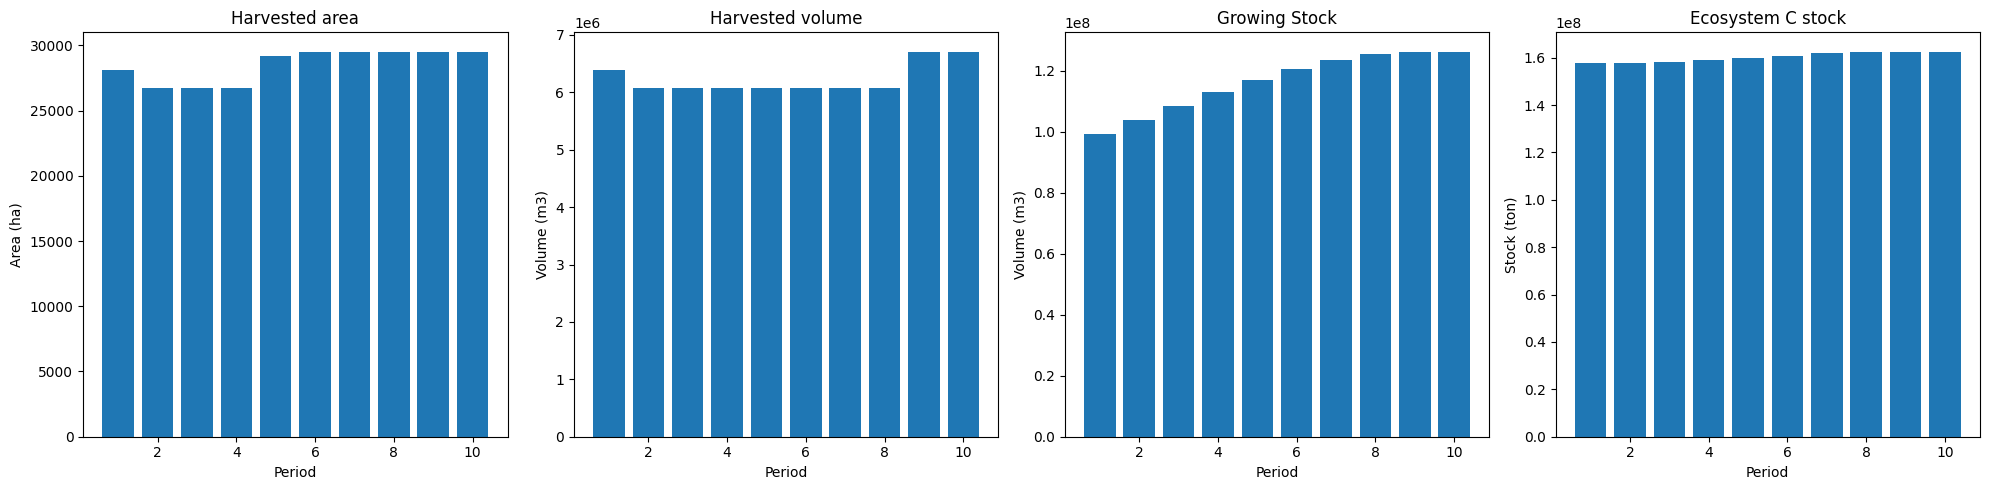

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_70%_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  65861
The economic indicator (the provincial government revenues) is:  2246001
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


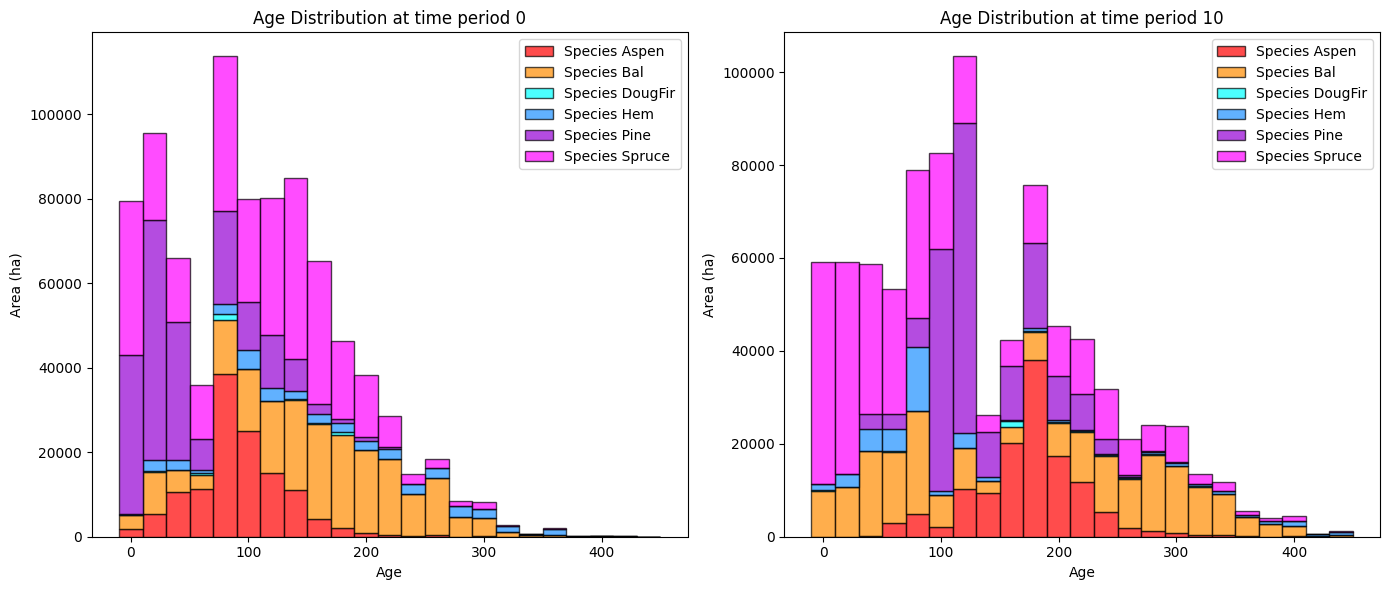

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_70%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0             10    Difference
Hem      19152.127229    7927.094758 -11225.032471
DougFir    947.047810    2329.596842   1382.549032
Bal      59315.970469   92871.500477  33555.530008
Spruce   36410.744598   66927.160126  30516.415528
Aspen    29632.731169  111106.081976  81473.350806
Pine      7432.733686   61028.061676  53595.327990

Overall diversity has **increased** by 189298.14 hectares from time period 0 to time period 10.


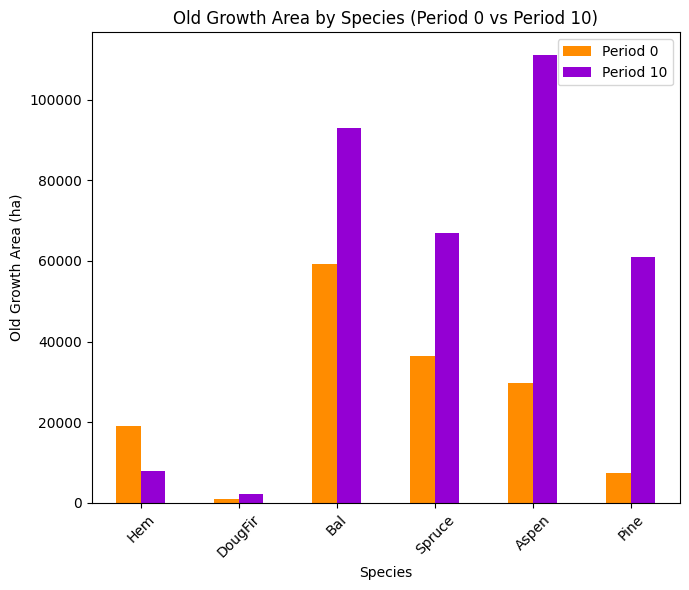

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_70%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7205

Diversity has **decreased** by 3.87% from time 0 to time 10.


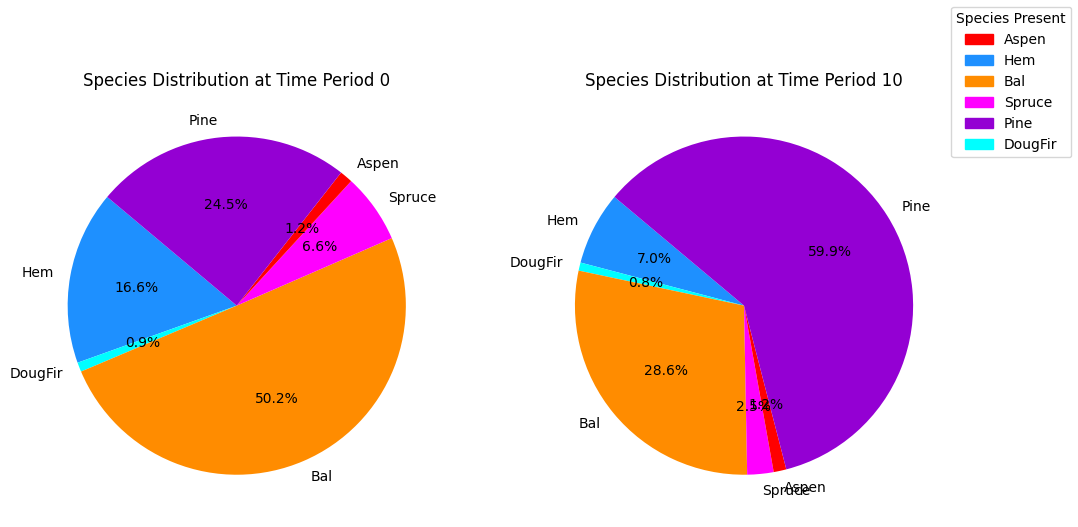

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_70%_species_pie.pdf
running business as usual scenario for the Equity Silver mining site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0x9ff13077
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [4e+01, 7e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8883 columns
Presolve time: 0.25s
Presolved: 8375 rows, 74376 columns, 536315 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Or

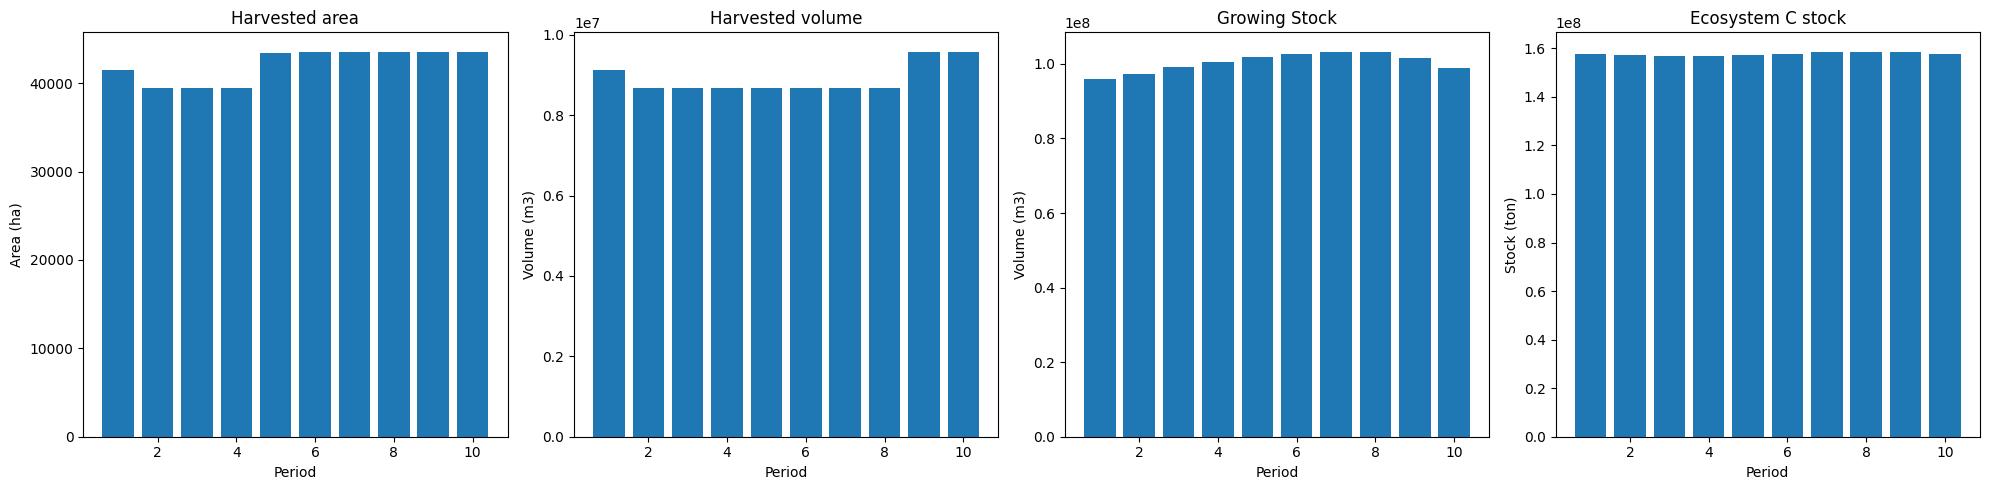

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  94087
The economic indicator (the provincial government revenues) is:  3208573
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


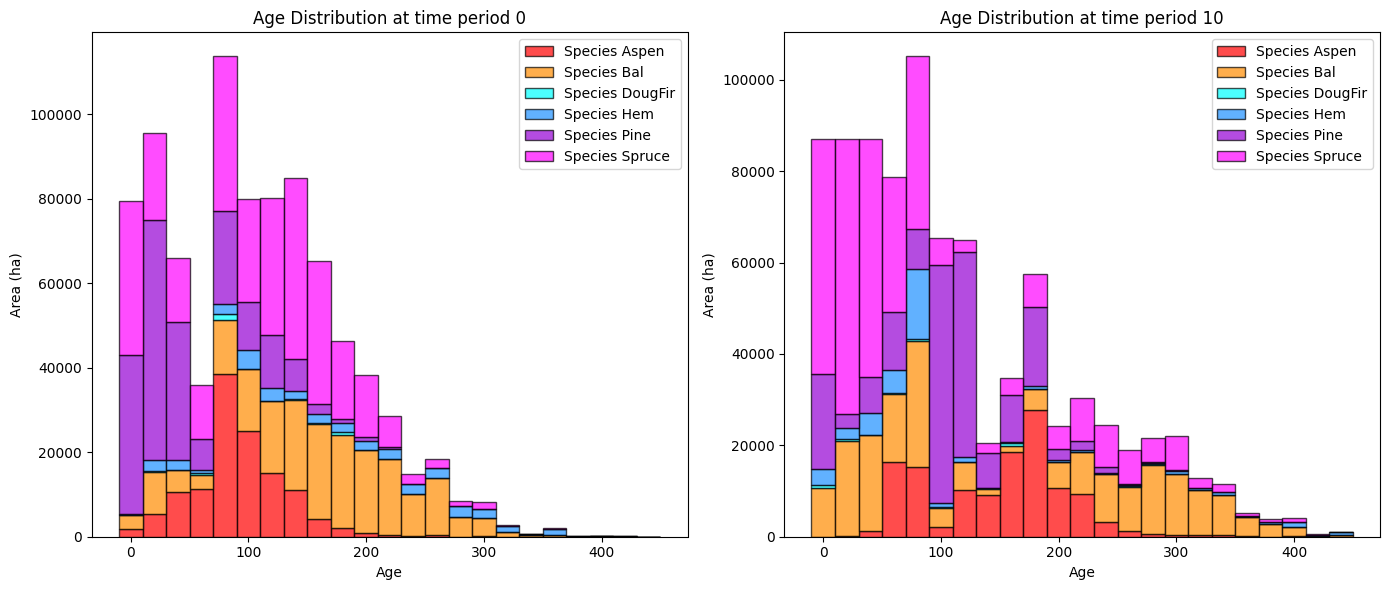

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0            10    Difference
Hem      19152.127229   6336.259592 -12815.867637
DougFir    947.047810   1486.896012    539.848202
Bal      59315.970469  82610.623426  23294.652957
Spruce   36410.744598  53027.466135  16616.721537
Aspen    29632.731169  86224.058762  56591.327592
Pine      7432.733686  38253.569262  30820.835576

Overall diversity has **increased** by 115047.52 hectares from time period 0 to time period 10.


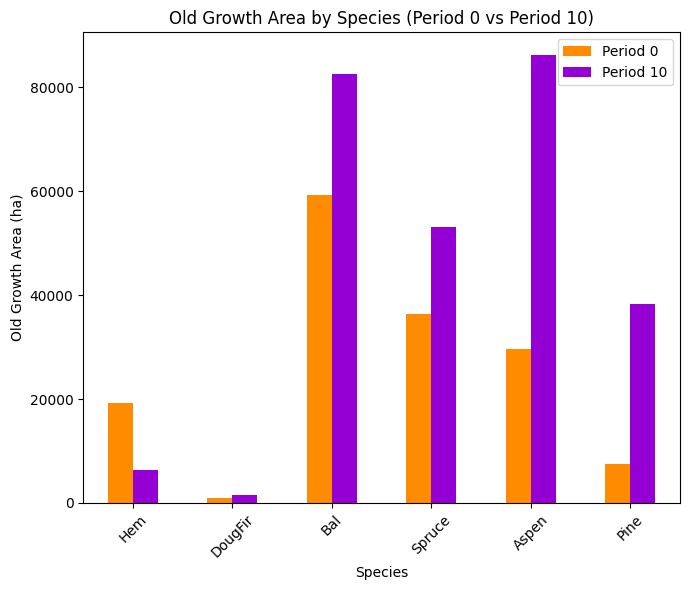

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7260

Diversity has **decreased** by 3.32% from time 0 to time 10.


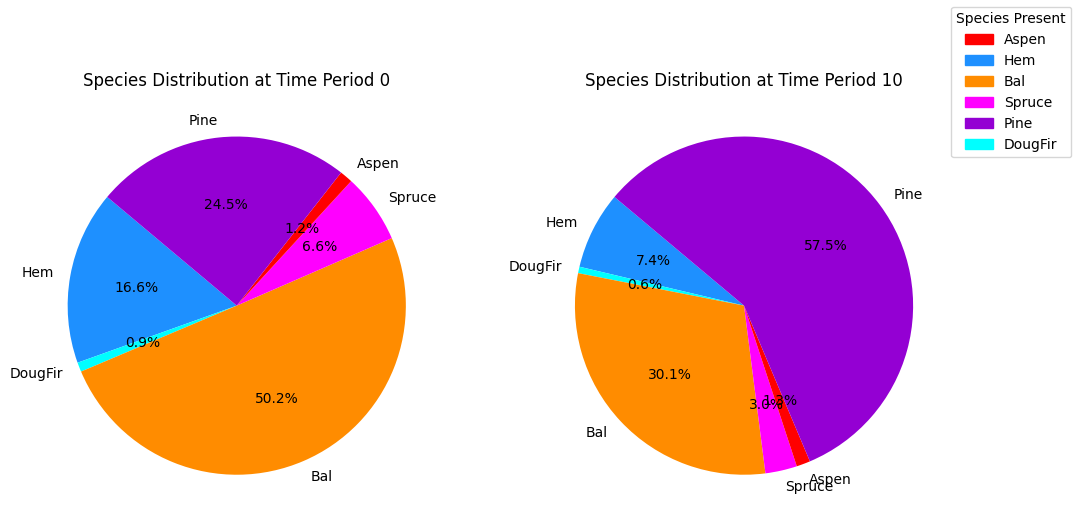

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_species_pie.pdf


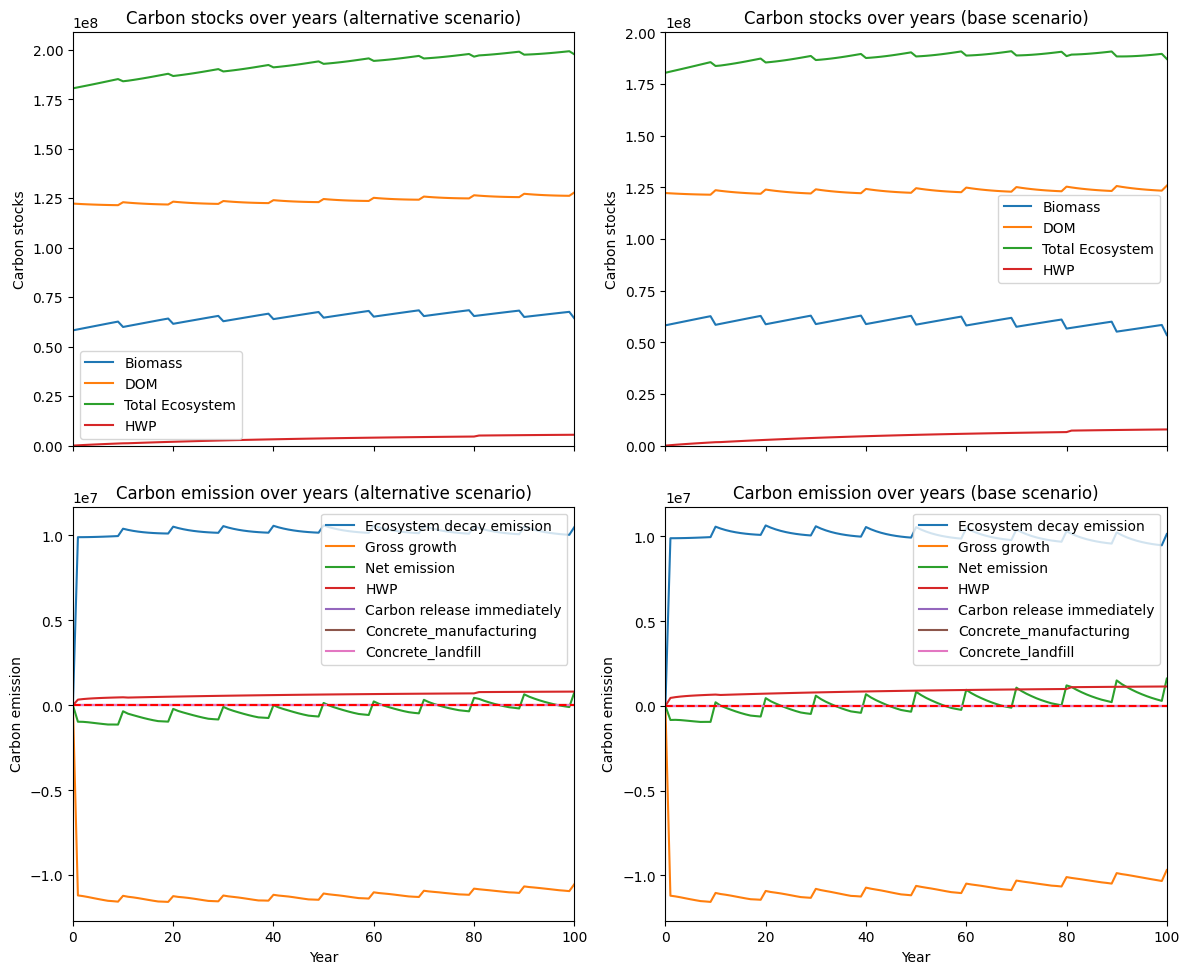

---------------------------------------------------------------------------------------
Net emission difference -8734736.303496169
Net emission base scenario -19006750.6872208
Net emission alternative scenario -10272014.383724635
dollar_per_ton is:  1.1448542523255563
Comparison of Old Growth Areas (Alternative - Base)
           0            10    Difference
Hem      0.0   1590.835166   1590.835166
DougFir  0.0    842.700830    842.700830
Bal      0.0  10260.877051  10260.877051
Spruce   0.0  13899.693992  13899.693992
Aspen    0.0  24882.023214  24882.023214
Pine     0.0  22774.492414  22774.492414

Overall, the old growth area has **increased** by 74250.62 hectares in the alternative scenario compared to the base scenario.


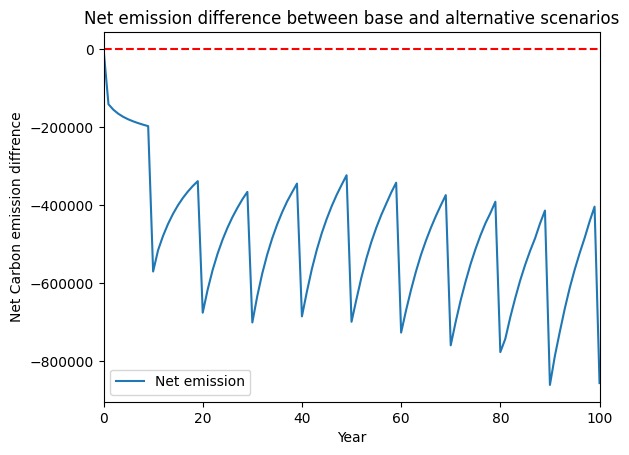

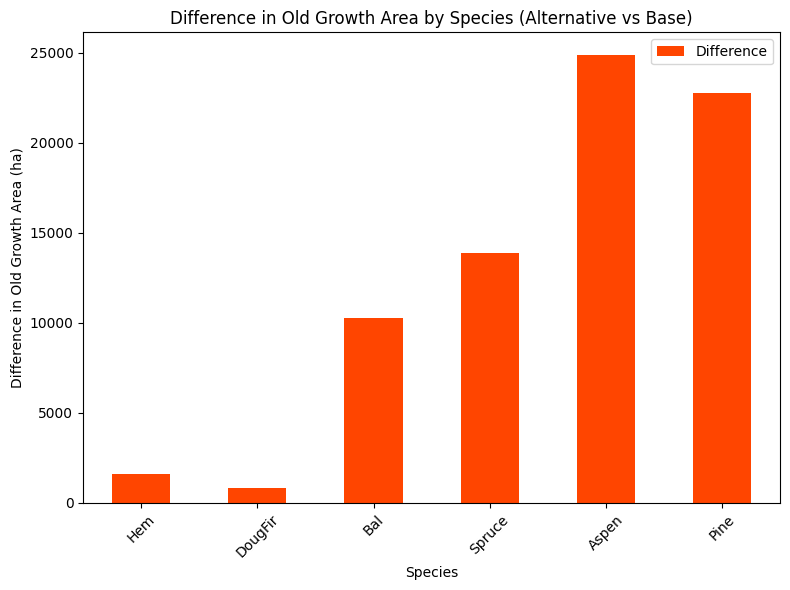

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_kpi_age_difference.pdf


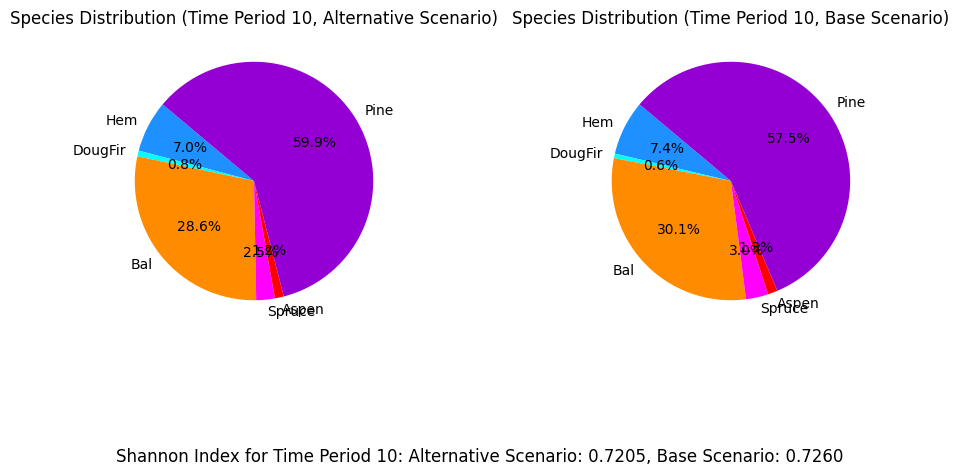

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for equitysilver_max_st_eqtslvr_AAC_60%...
running the scenario for the Equity Silver mining site (60%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0x16253978
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [4e+01, 7e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8883 columns
Presolve time: 0.22s
Presolved: 8375 r

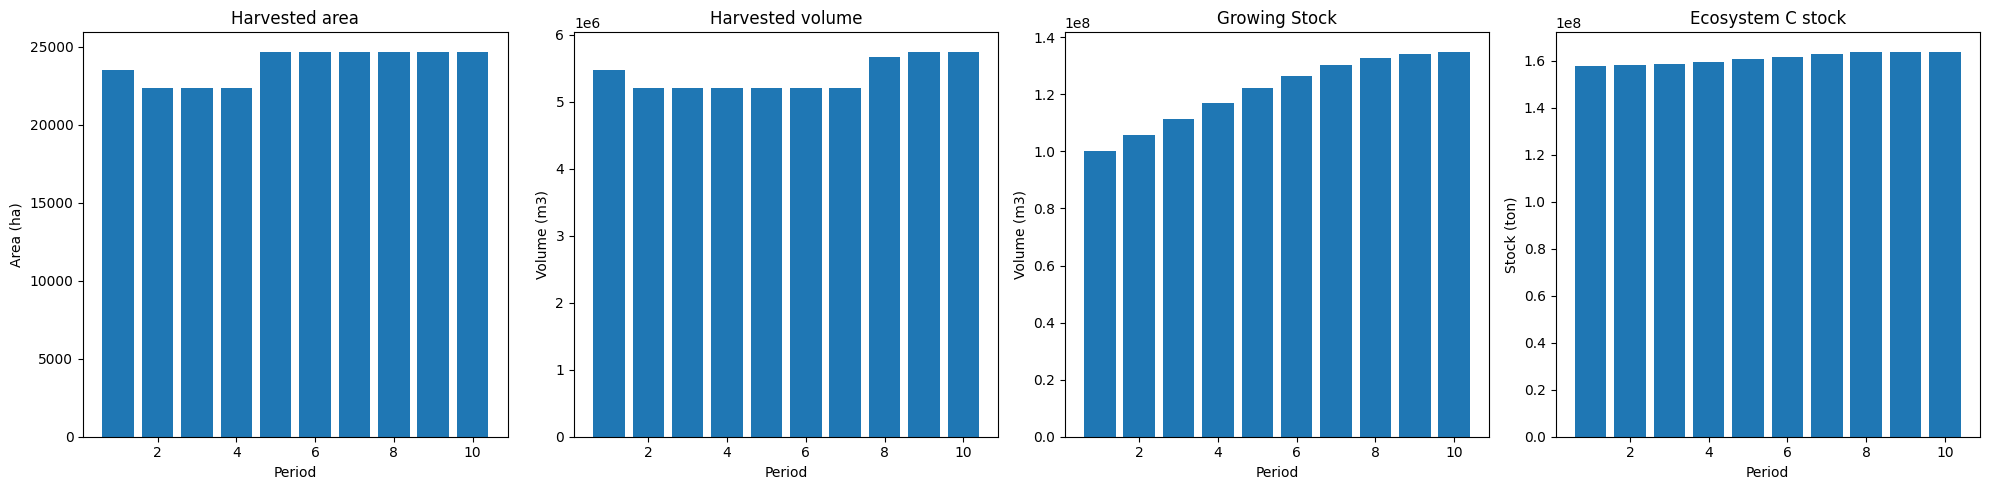

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_60%_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  56950
The economic indicator (the provincial government revenues) is:  1942135
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


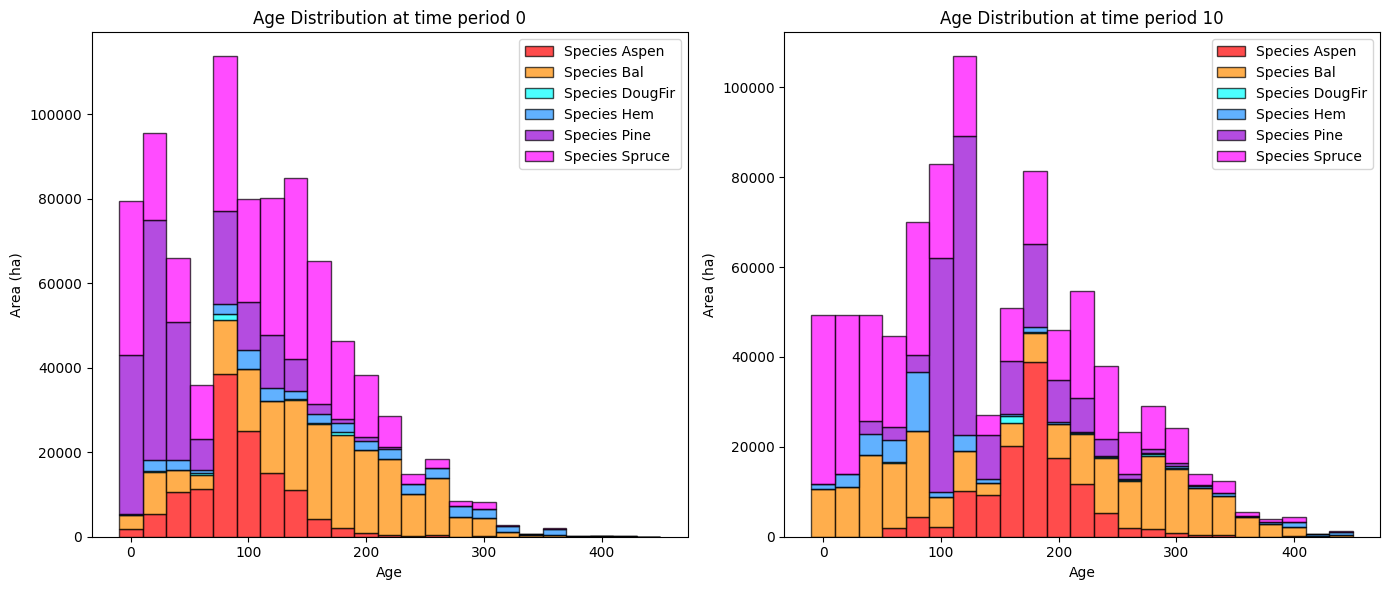

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_60%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0             10    Difference
Hem      19152.127229    8558.090221 -10594.037007
DougFir    947.047810    2572.498932   1625.451122
Bal      59315.970469   94210.481880  34894.511411
Spruce   36410.744598   96857.497296  60446.752698
Aspen    29632.731169  112856.064029  83223.332860
Pine      7432.733686   63665.381800  56232.648114

Overall diversity has **increased** by 225828.66 hectares from time period 0 to time period 10.


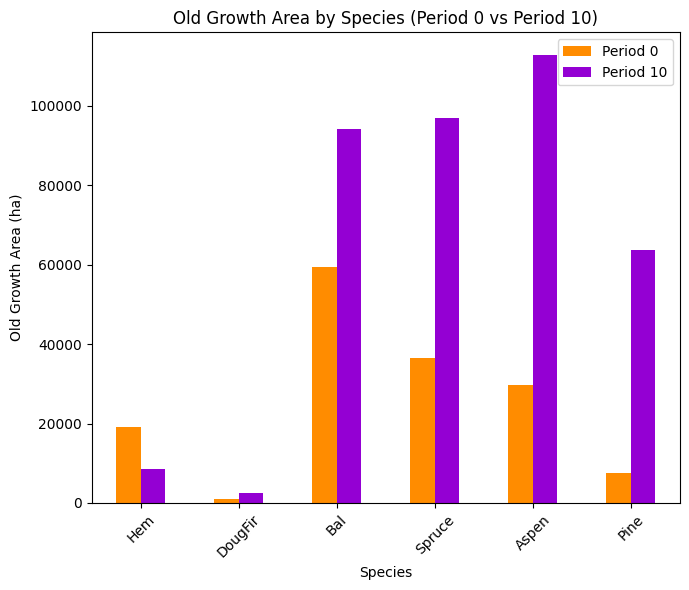

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_60%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7213

Diversity has **decreased** by 3.79% from time 0 to time 10.


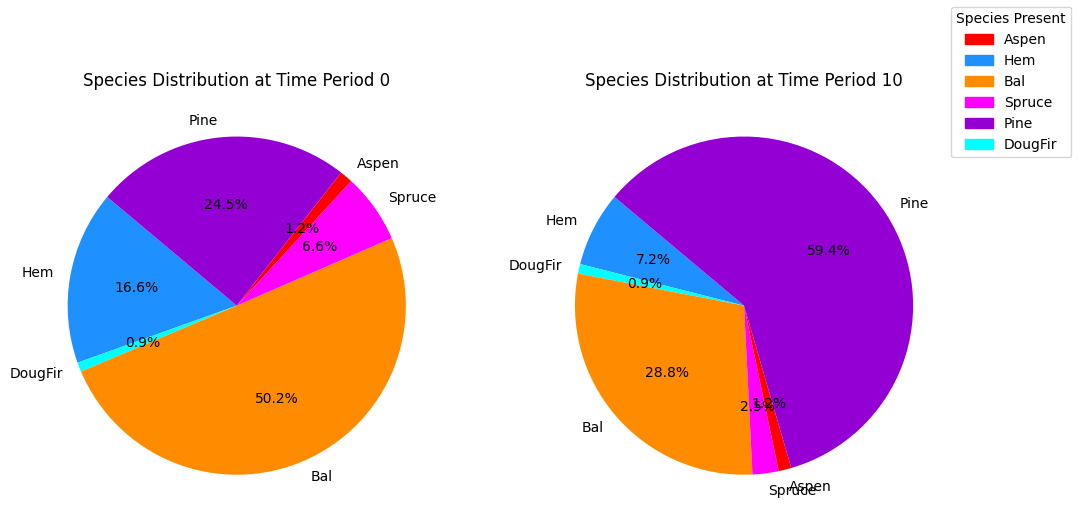

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_60%_species_pie.pdf
running business as usual scenario for the Equity Silver mining site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0x9ff13077
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [4e+01, 7e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8883 columns
Presolve time: 0.25s
Presolved: 8375 rows, 74376 columns, 536315 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Or

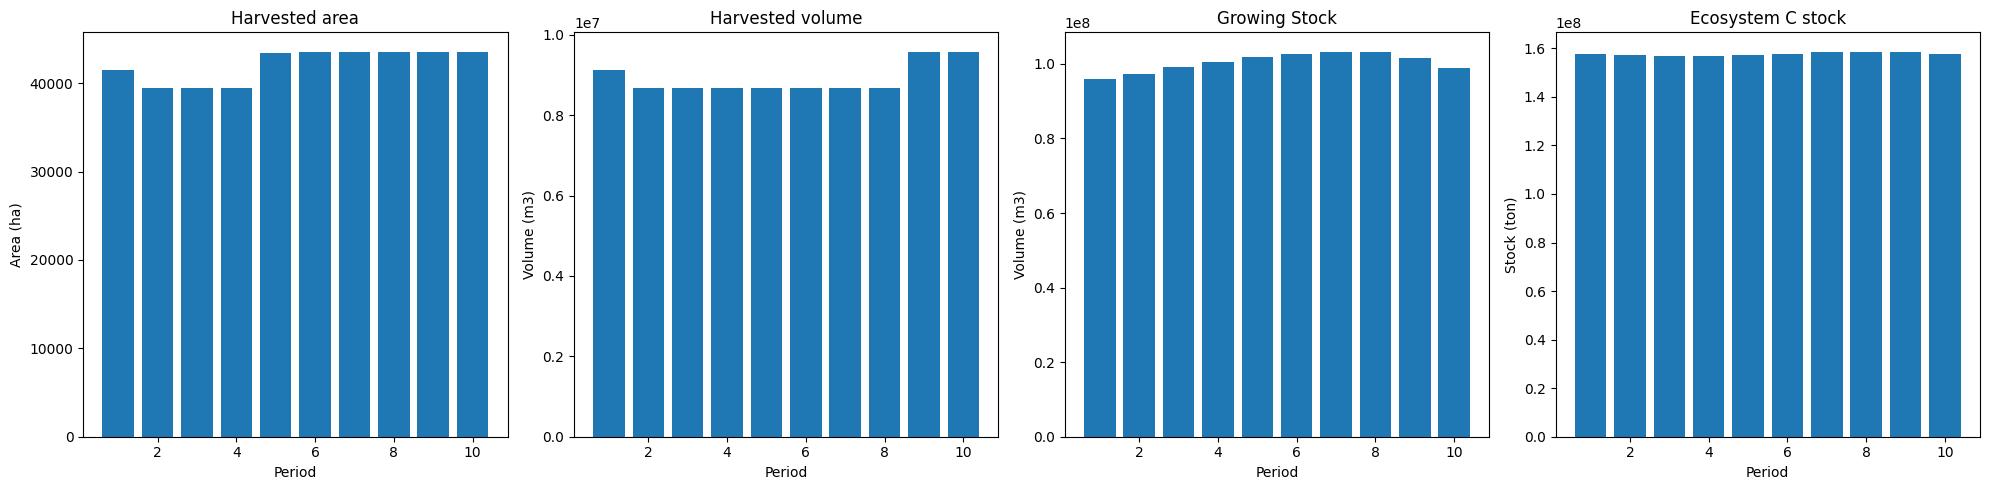

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  94087
The economic indicator (the provincial government revenues) is:  3208573
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


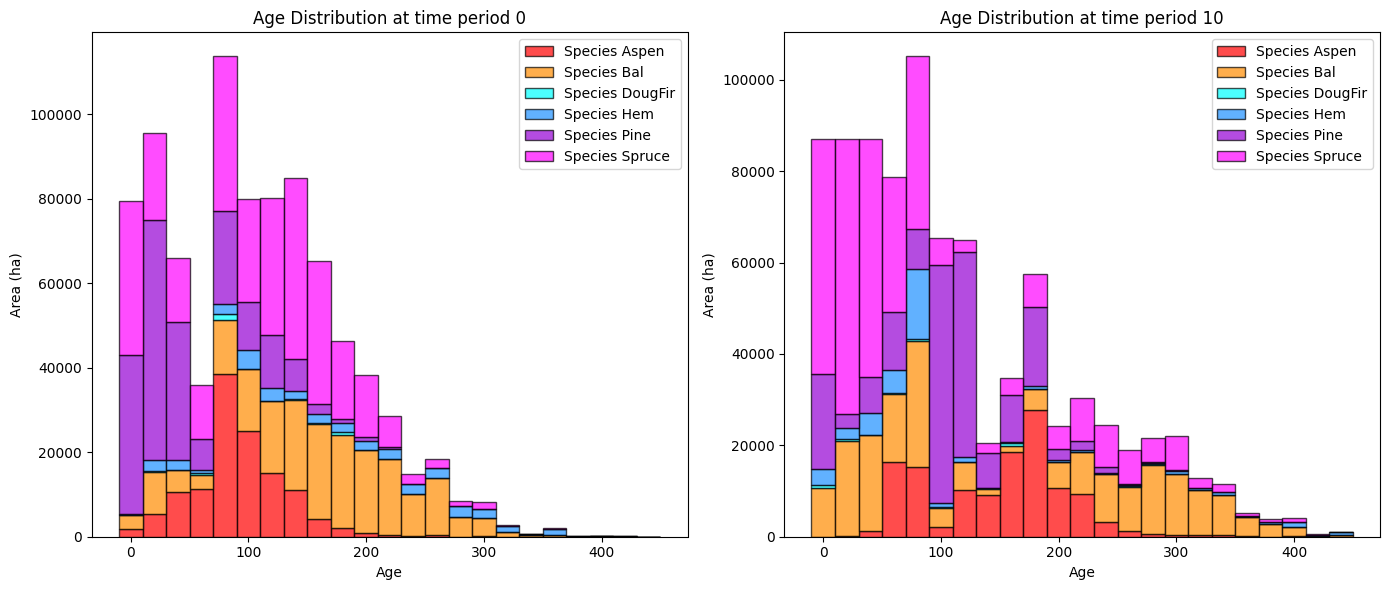

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0            10    Difference
Hem      19152.127229   6336.259592 -12815.867637
DougFir    947.047810   1486.896012    539.848202
Bal      59315.970469  82610.623426  23294.652957
Spruce   36410.744598  53027.466135  16616.721537
Aspen    29632.731169  86224.058762  56591.327592
Pine      7432.733686  38253.569262  30820.835576

Overall diversity has **increased** by 115047.52 hectares from time period 0 to time period 10.


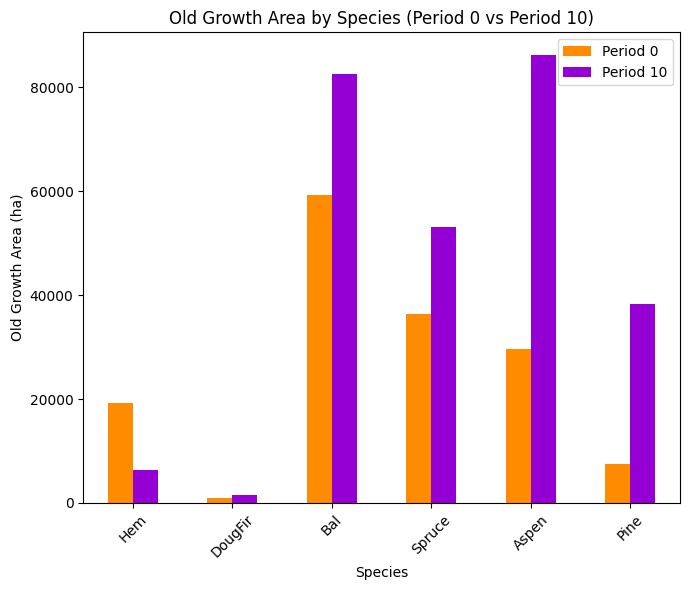

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7260

Diversity has **decreased** by 3.32% from time 0 to time 10.


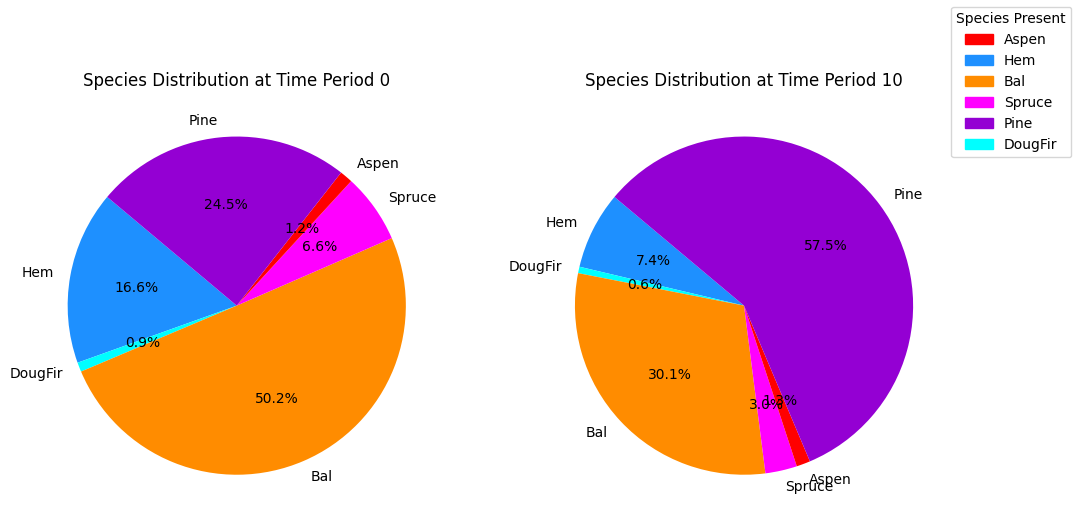

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_species_pie.pdf


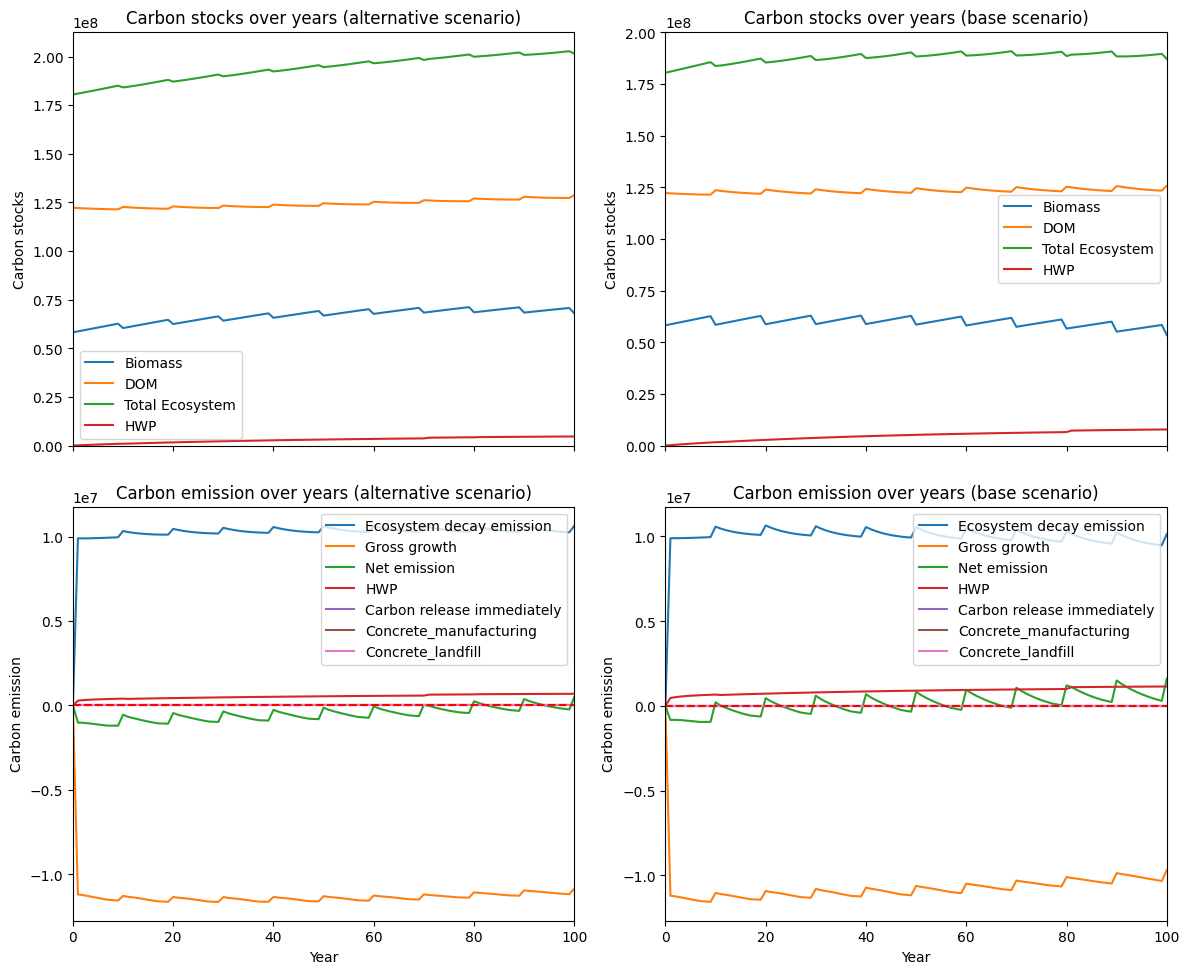

---------------------------------------------------------------------------------------
Net emission difference -11774676.358109497
Net emission base scenario -22046690.741834134
Net emission alternative scenario -10272014.383724635
dollar_per_ton is:  0.8492802431136687
Comparison of Old Growth Areas (Alternative - Base)
           0            10    Difference
Hem      0.0   2221.830630   2221.830630
DougFir  0.0   1085.602920   1085.602920
Bal      0.0  11599.858454  11599.858454
Spruce   0.0  43830.031162  43830.031162
Aspen    0.0  26632.005267  26632.005267
Pine     0.0  25411.812537  25411.812537

Overall, the old growth area has **increased** by 110781.14 hectares in the alternative scenario compared to the base scenario.


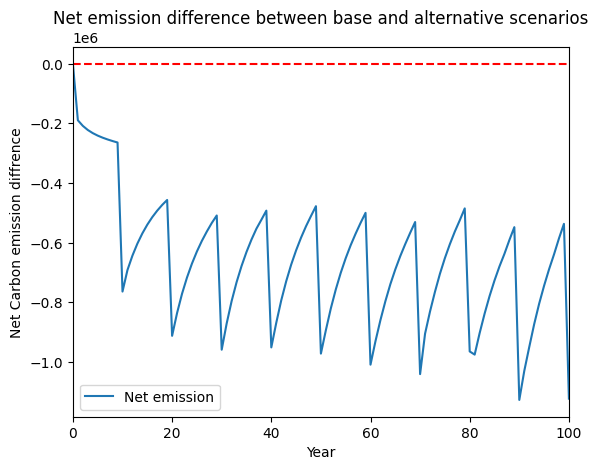

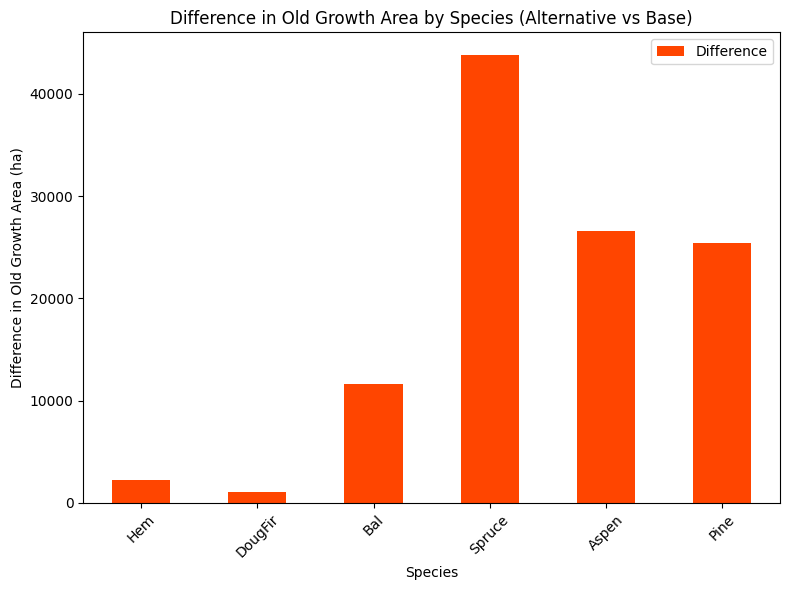

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_kpi_age_difference.pdf


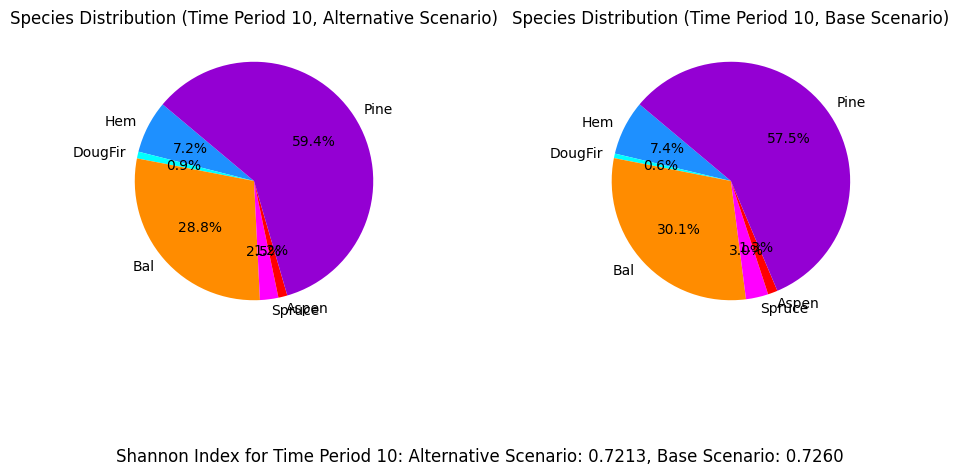

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for equitysilver_max_st_eqtslvr_AAC_50%...
running the scenario for the Equity Silver mining site (50%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0x818f09fd
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [4e+01, 7e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8883 columns
Presolve time: 0.27s
Presolved: 8375 r

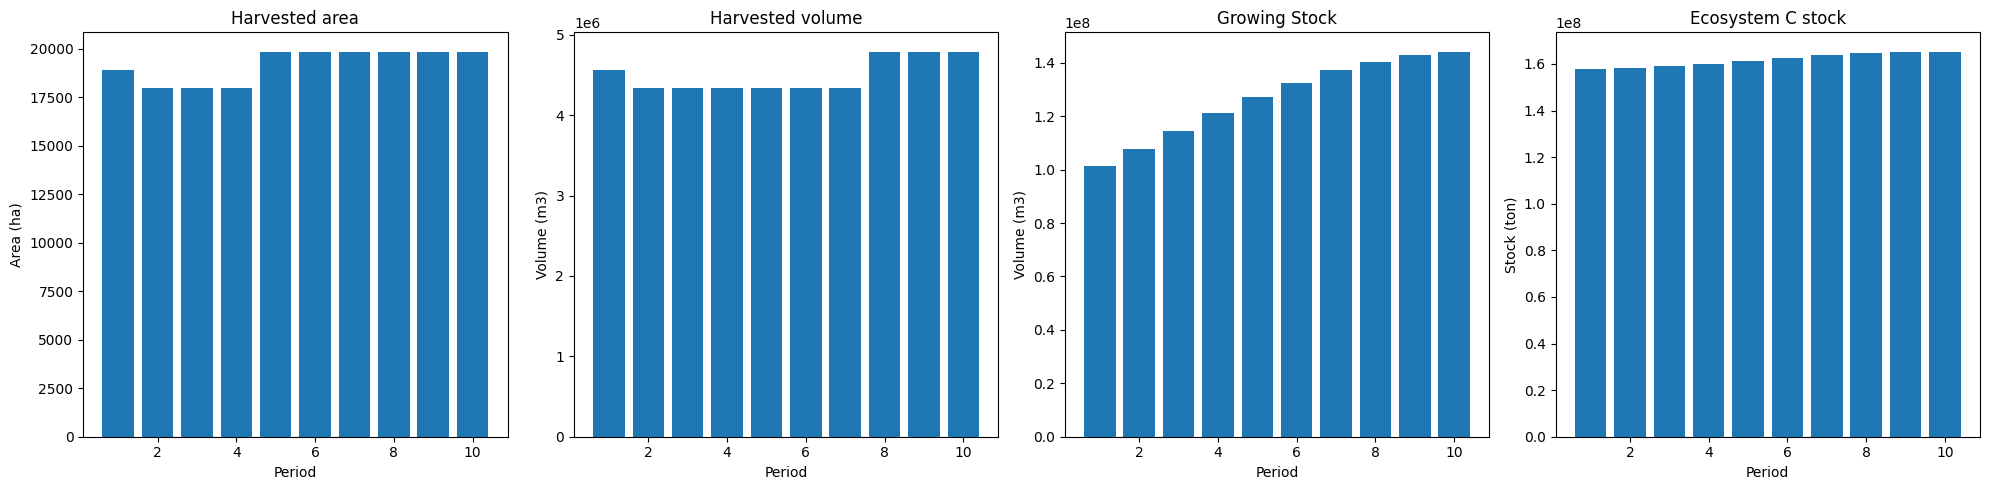

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_50%_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  47526
The economic indicator (the provincial government revenues) is:  1620741
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


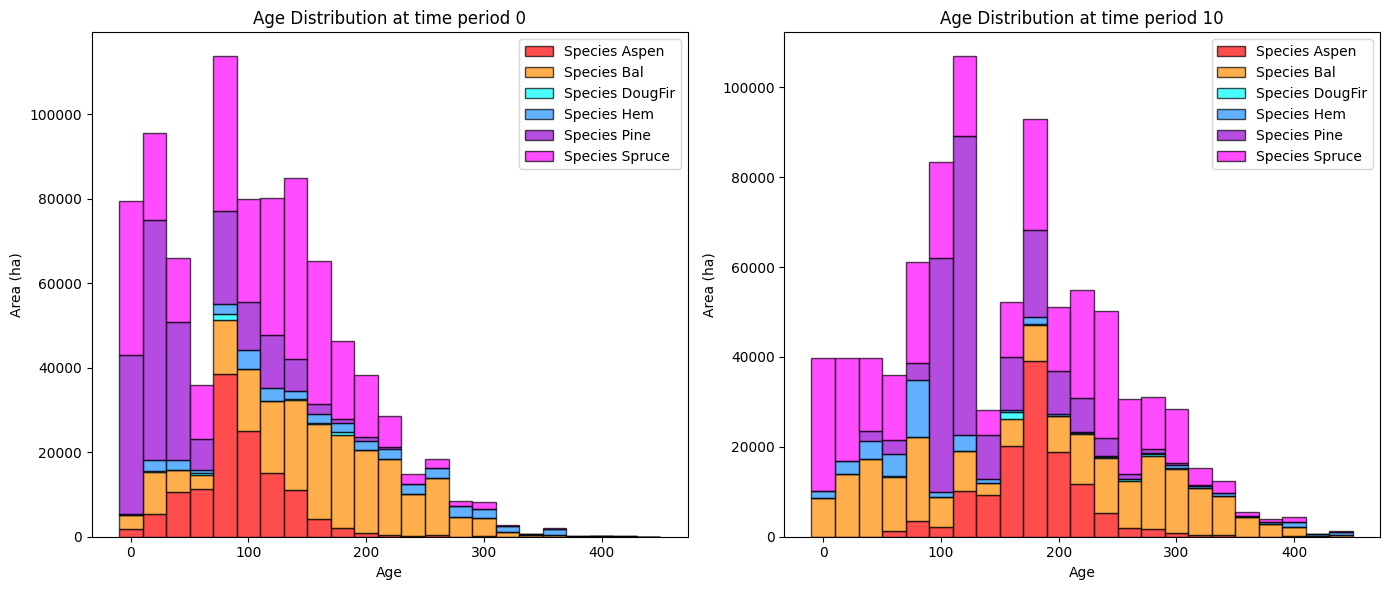

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_50%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0             10    Difference
Hem      19152.127229    8924.037696 -10228.089532
DougFir    947.047810    2587.448146   1640.400336
Bal      59315.970469   95550.158355  36234.187887
Spruce   36410.744598  133537.938785  97127.194187
Aspen    29632.731169  114324.783990  84692.052821
Pine      7432.733686   64675.837444  57243.103758

Overall diversity has **increased** by 266708.85 hectares from time period 0 to time period 10.


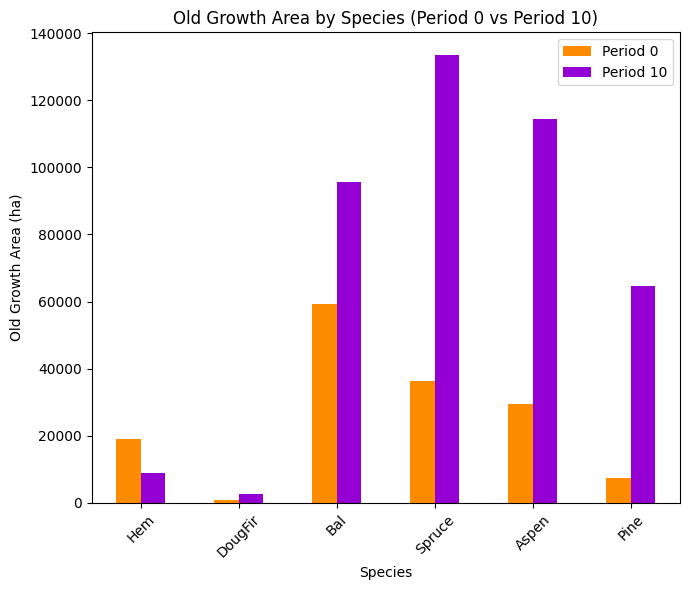

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_50%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7158

Diversity has **decreased** by 4.34% from time 0 to time 10.


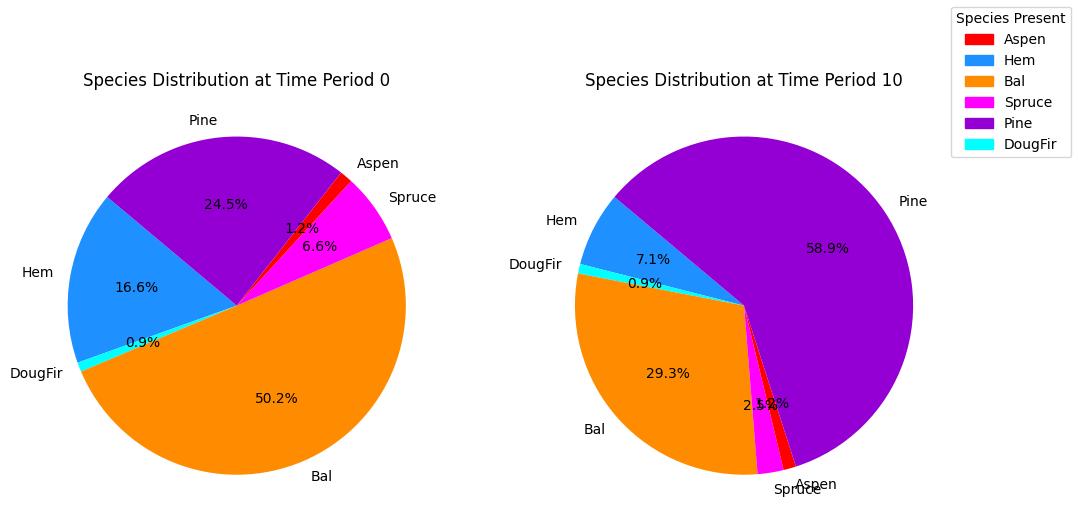

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_50%_species_pie.pdf
running business as usual scenario for the Equity Silver mining site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0x9ff13077
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [4e+01, 7e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8883 columns
Presolve time: 0.22s
Presolved: 8375 rows, 74376 columns, 536315 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Or

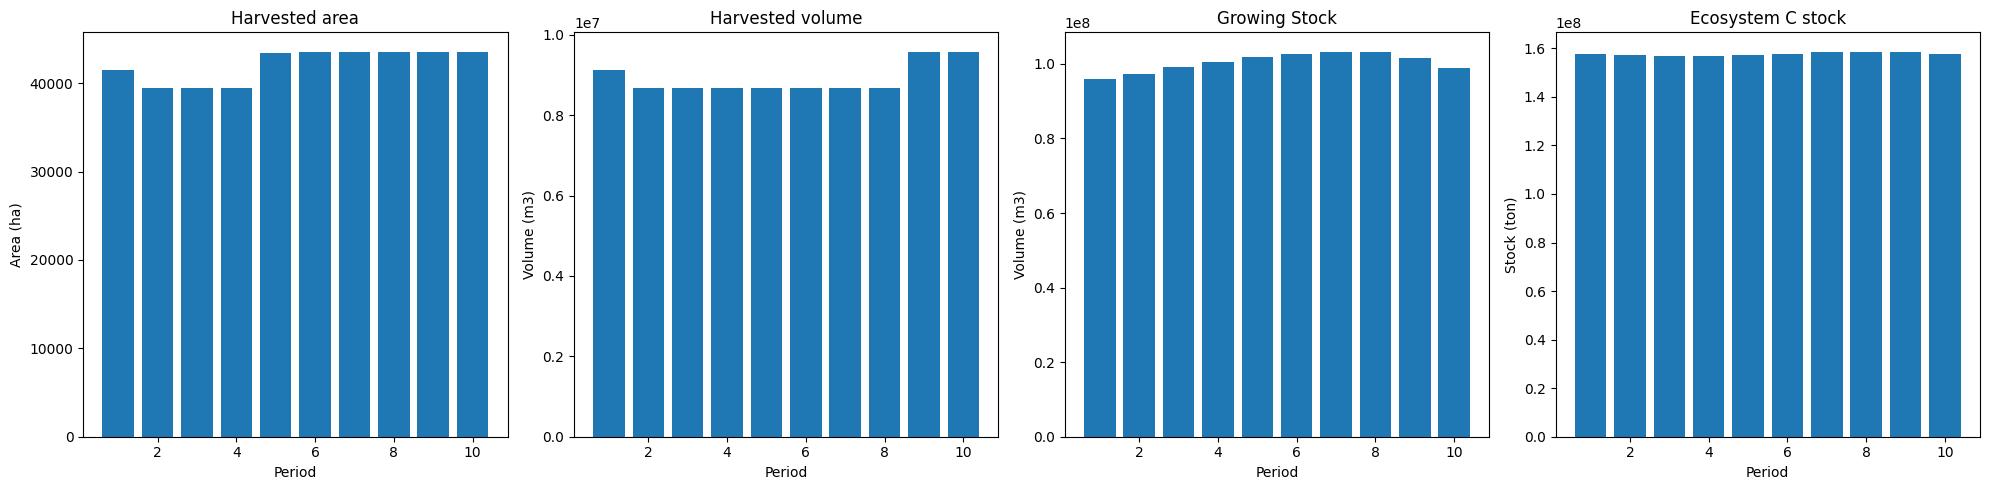

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  94087
The economic indicator (the provincial government revenues) is:  3208573
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


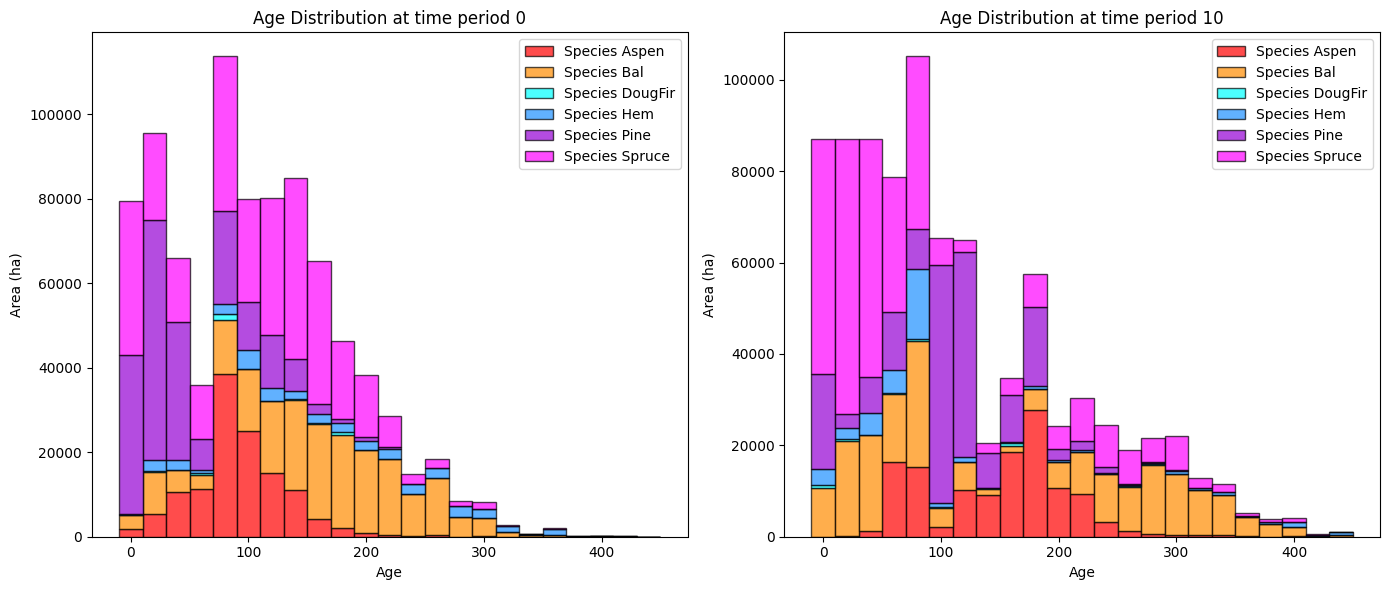

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0            10    Difference
Hem      19152.127229   6336.259592 -12815.867637
DougFir    947.047810   1486.896012    539.848202
Bal      59315.970469  82610.623426  23294.652957
Spruce   36410.744598  53027.466135  16616.721537
Aspen    29632.731169  86224.058762  56591.327592
Pine      7432.733686  38253.569262  30820.835576

Overall diversity has **increased** by 115047.52 hectares from time period 0 to time period 10.


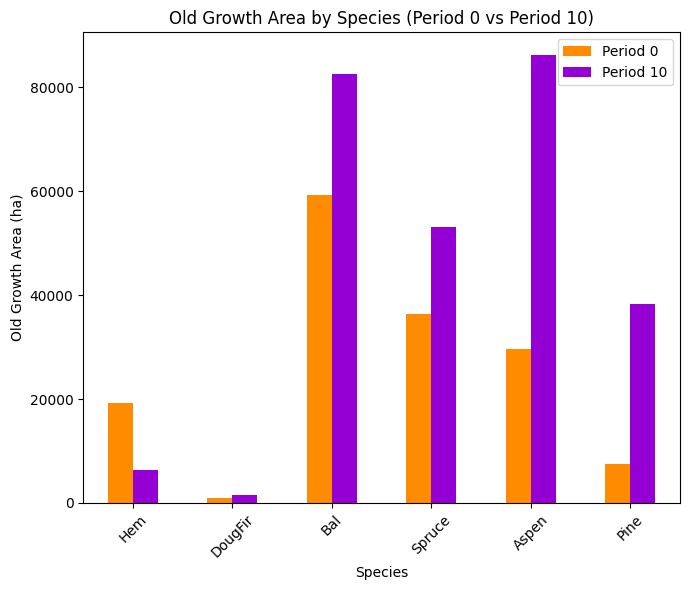

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7260

Diversity has **decreased** by 3.32% from time 0 to time 10.


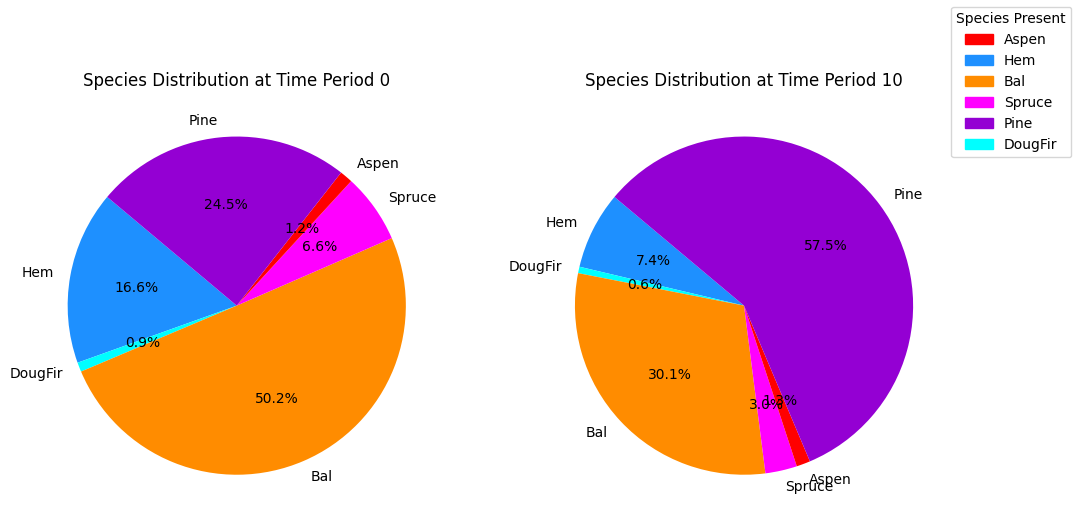

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_species_pie.pdf


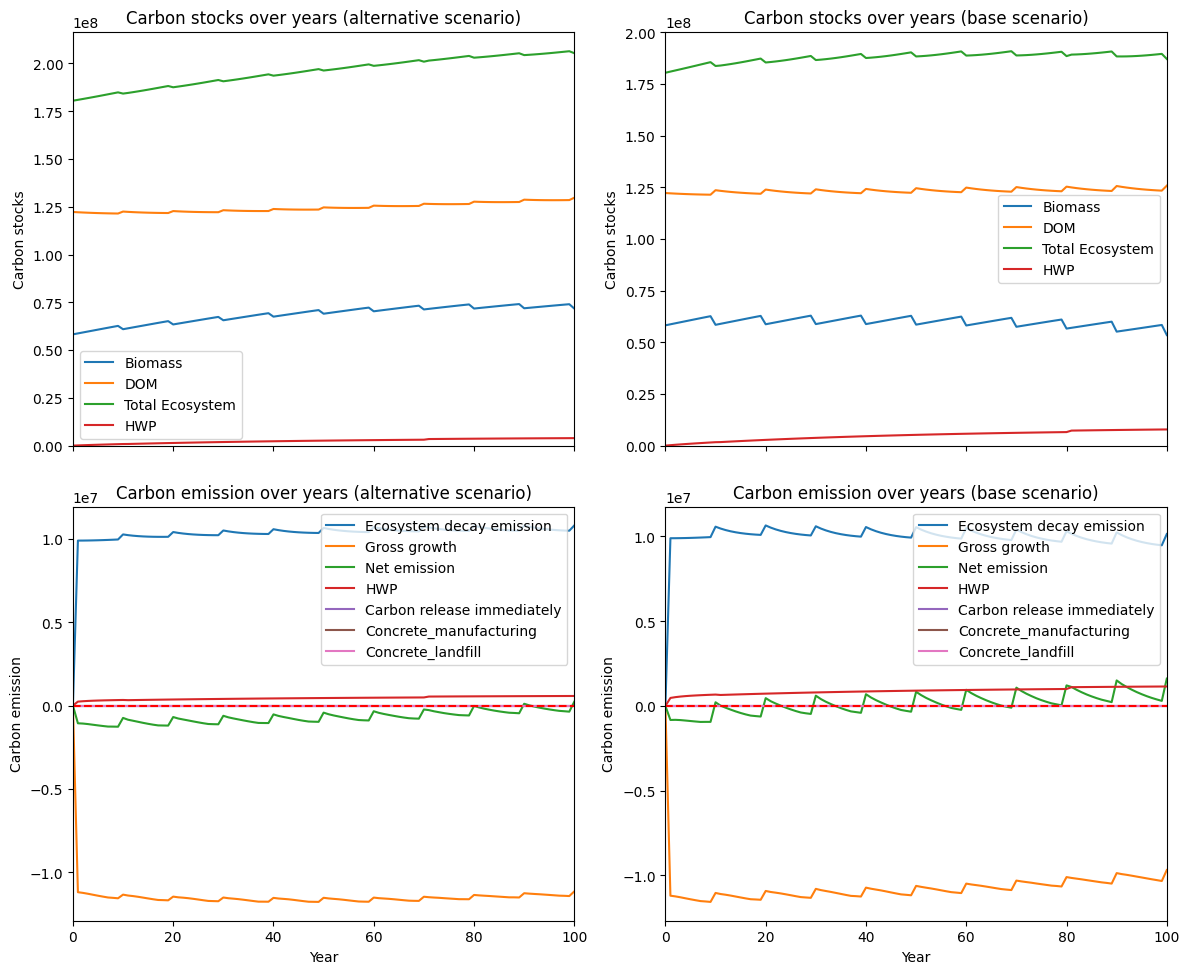

---------------------------------------------------------------------------------------
Net emission difference -14831919.418731108
Net emission base scenario -25103933.802455746
Net emission alternative scenario -10272014.383724635
dollar_per_ton is:  0.6742215702285358
Comparison of Old Growth Areas (Alternative - Base)
           0            10    Difference
Hem      0.0   2587.778105   2587.778105
DougFir  0.0   1100.552134   1100.552134
Bal      0.0  12939.534929  12939.534929
Spruce   0.0  80510.472650  80510.472650
Aspen    0.0  28100.725228  28100.725228
Pine     0.0  26422.268182  26422.268182

Overall, the old growth area has **increased** by 151661.33 hectares in the alternative scenario compared to the base scenario.


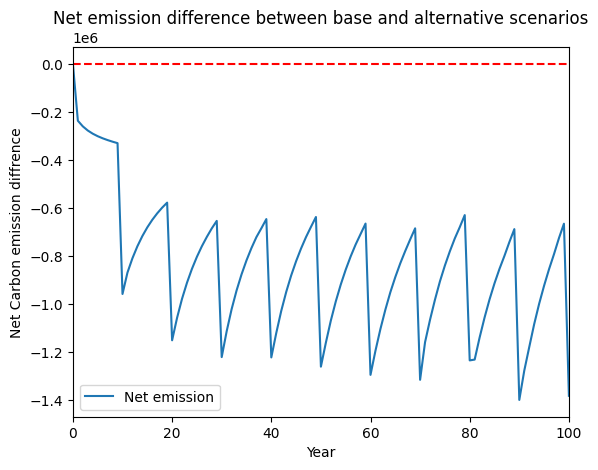

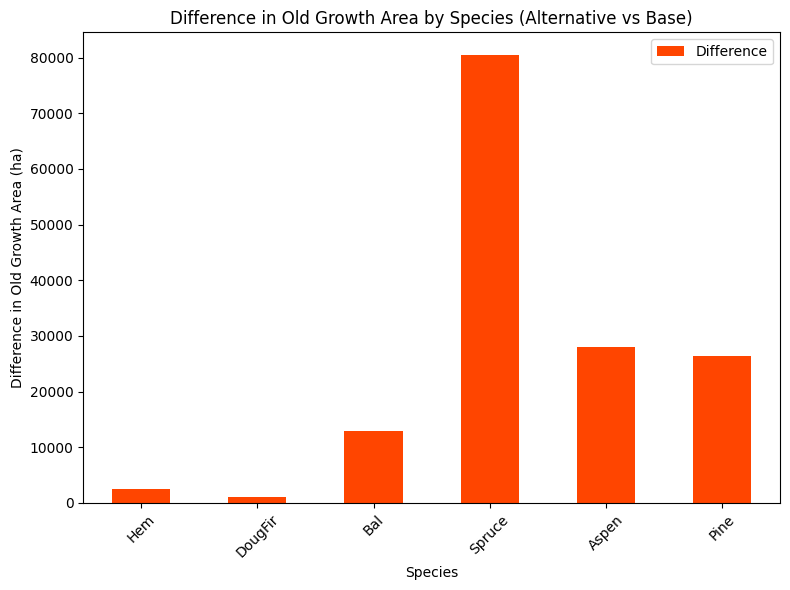

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_kpi_age_difference.pdf


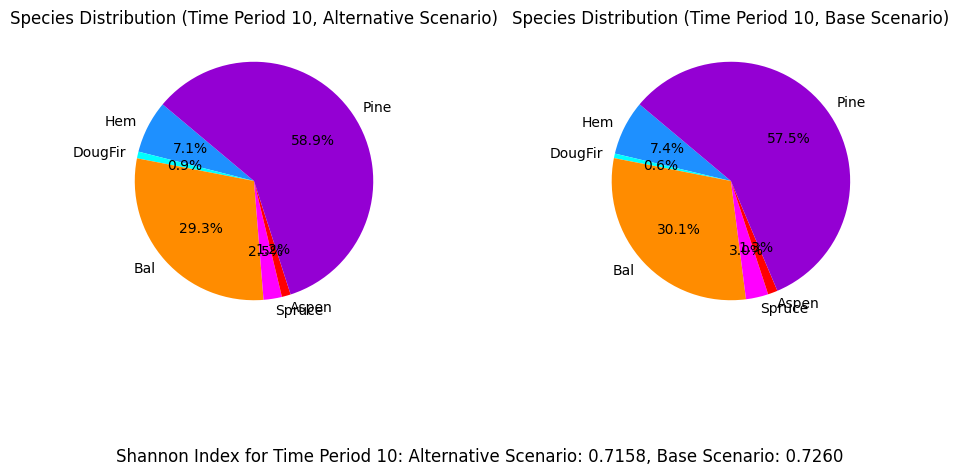

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for equitysilver_max_st_eqtslvr_AAC_40%...
running the scenario for the Equity Silver mining site (40%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0x5f9085f1
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [4e+01, 7e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8883 columns
Presolve time: 0.22s
Presolved: 8375 r

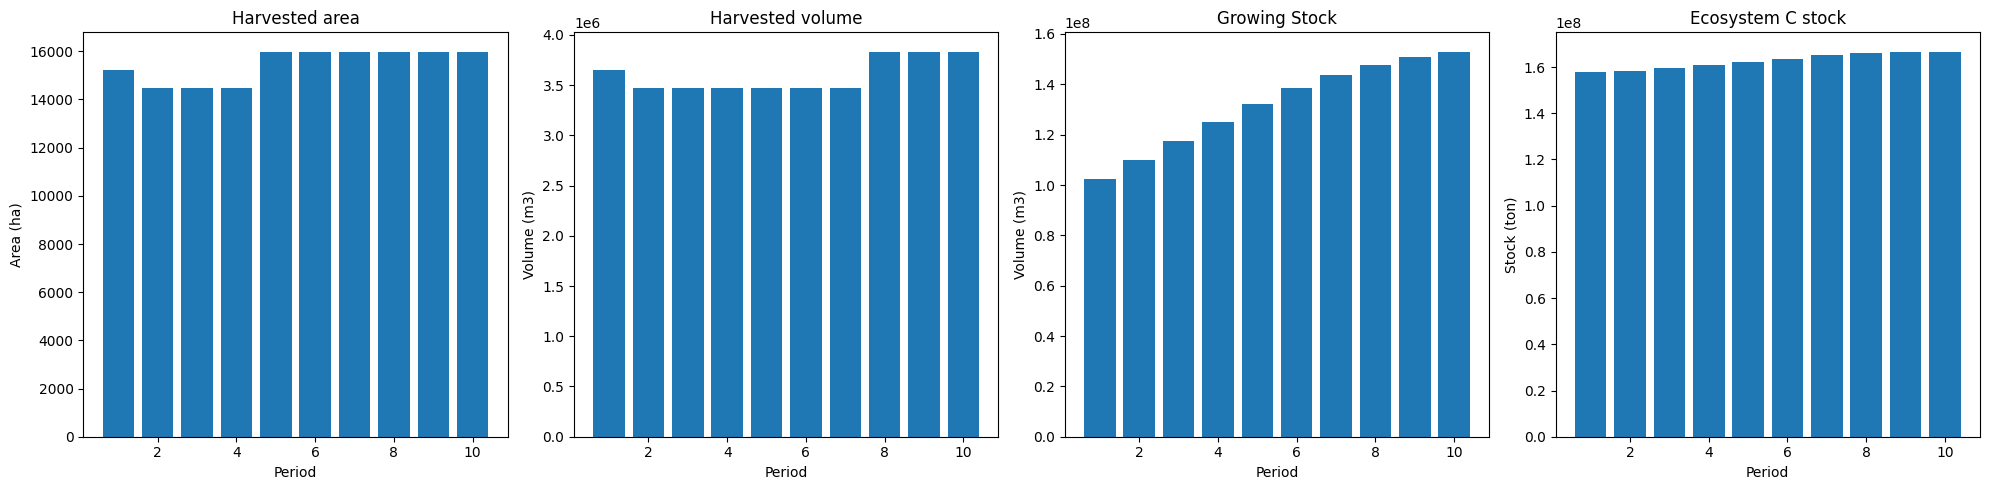

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_40%_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  38020
The economic indicator (the provincial government revenues) is:  1296592
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


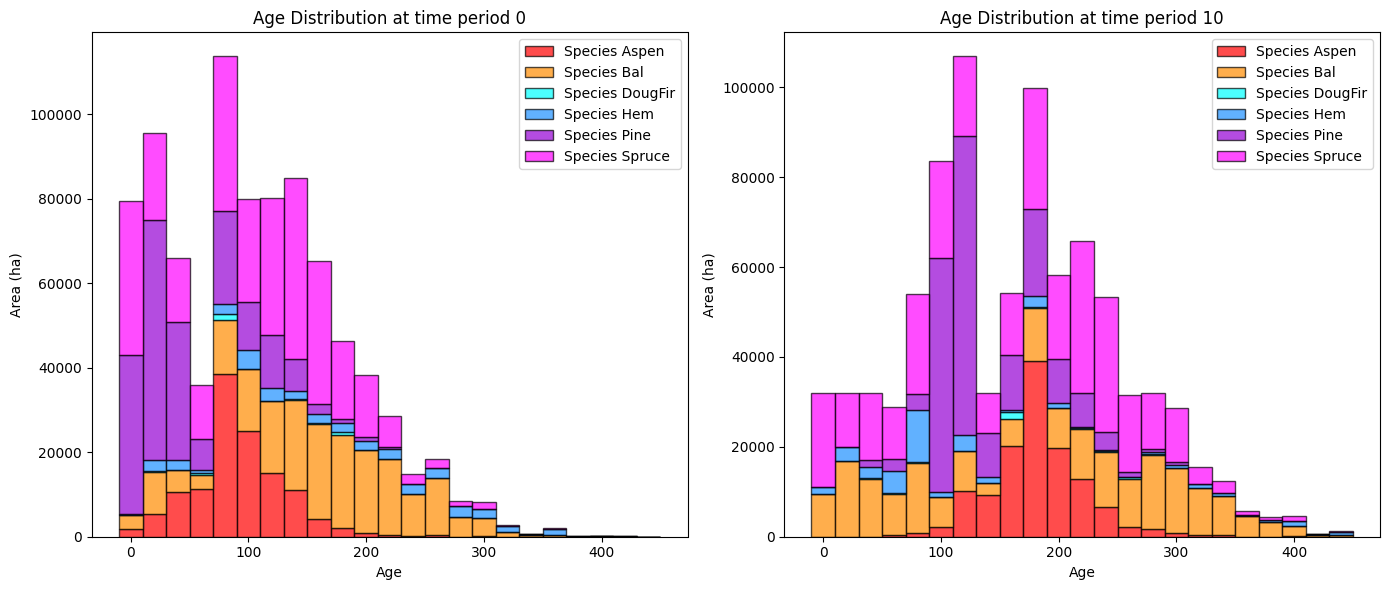

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_40%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0             10     Difference
Hem      19152.127229   10774.663067   -8377.464161
DougFir    947.047810    2607.841586    1660.793776
Bal      59315.970469   99933.056888   40617.086419
Spruce   36410.744598  153909.551687  117498.807089
Aspen    29632.731169  117852.853466   88220.122297
Pine      7432.733686   65861.455786   58428.722100

Overall diversity has **increased** by 298048.07 hectares from time period 0 to time period 10.


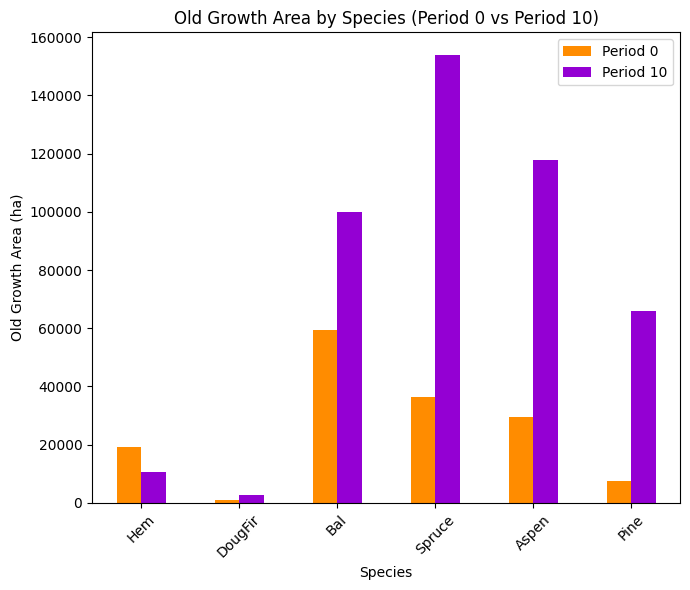

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_40%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7122

Diversity has **decreased** by 4.70% from time 0 to time 10.


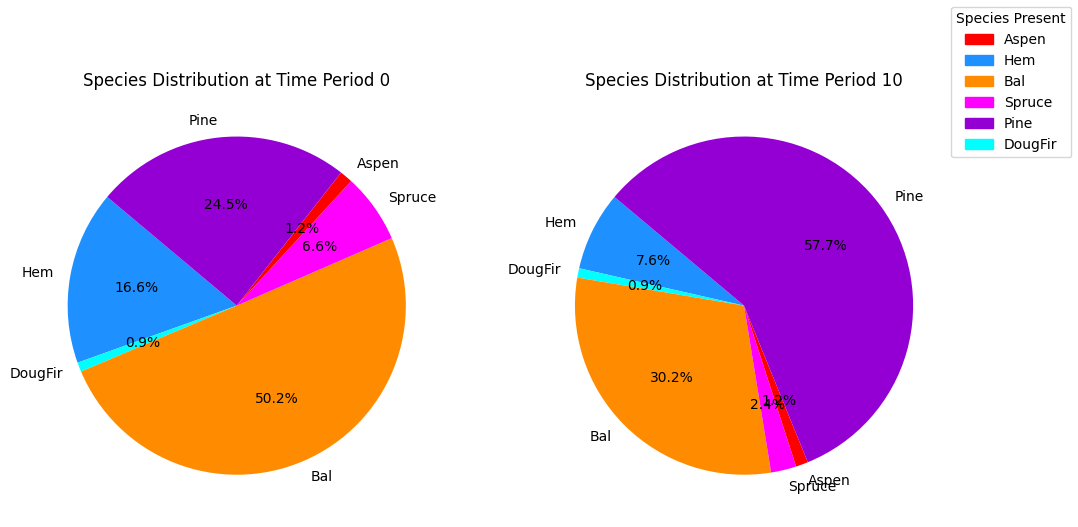

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_40%_species_pie.pdf
running business as usual scenario for the Equity Silver mining site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0x9ff13077
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [4e+01, 7e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8883 columns
Presolve time: 0.25s
Presolved: 8375 rows, 74376 columns, 536315 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Or

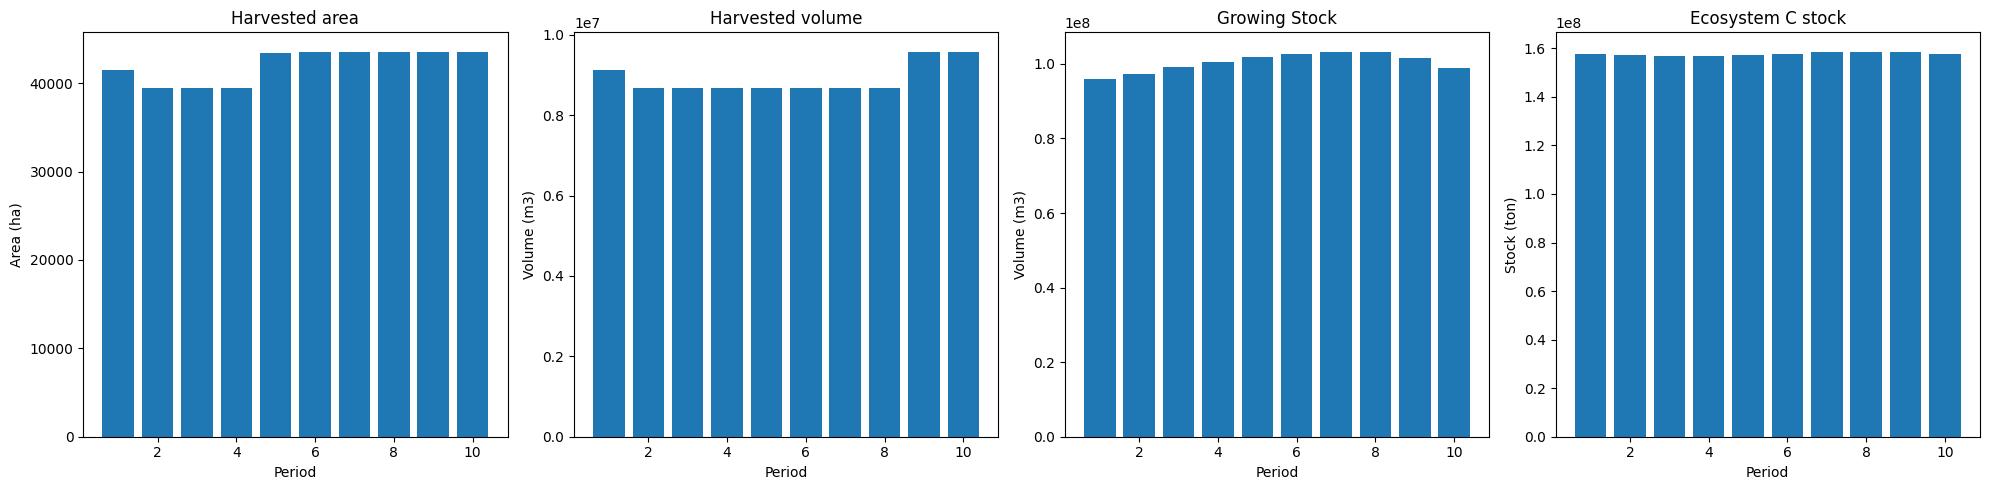

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  94087
The economic indicator (the provincial government revenues) is:  3208573
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


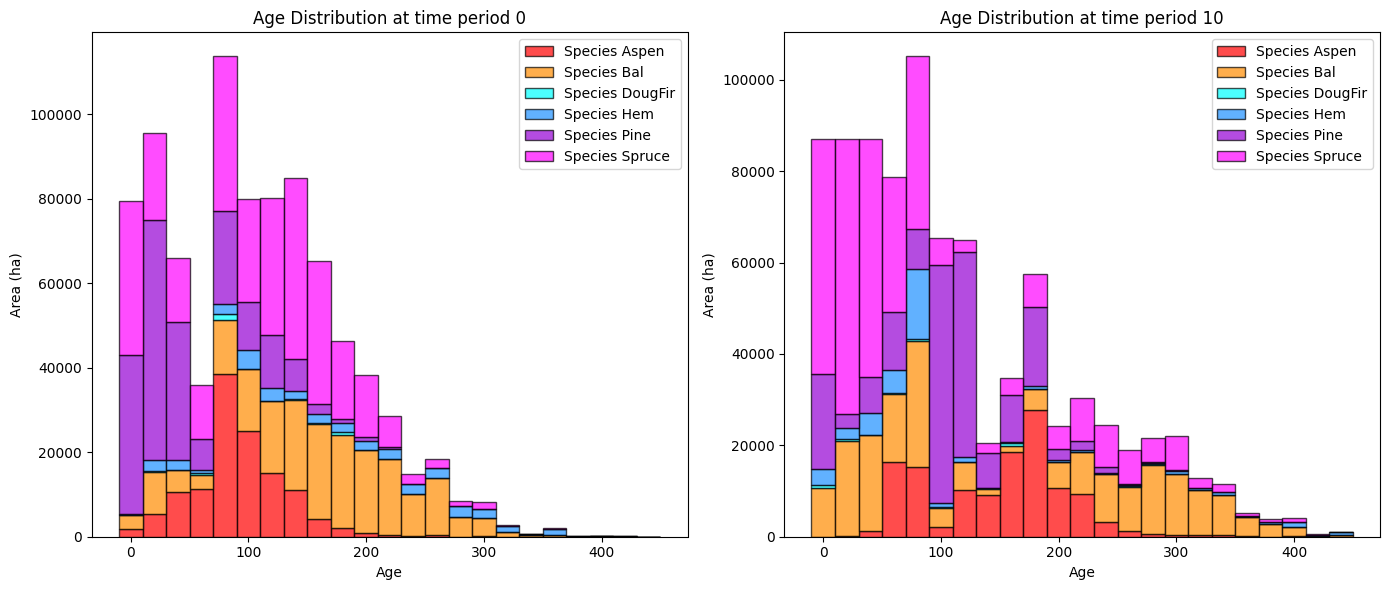

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0            10    Difference
Hem      19152.127229   6336.259592 -12815.867637
DougFir    947.047810   1486.896012    539.848202
Bal      59315.970469  82610.623426  23294.652957
Spruce   36410.744598  53027.466135  16616.721537
Aspen    29632.731169  86224.058762  56591.327592
Pine      7432.733686  38253.569262  30820.835576

Overall diversity has **increased** by 115047.52 hectares from time period 0 to time period 10.


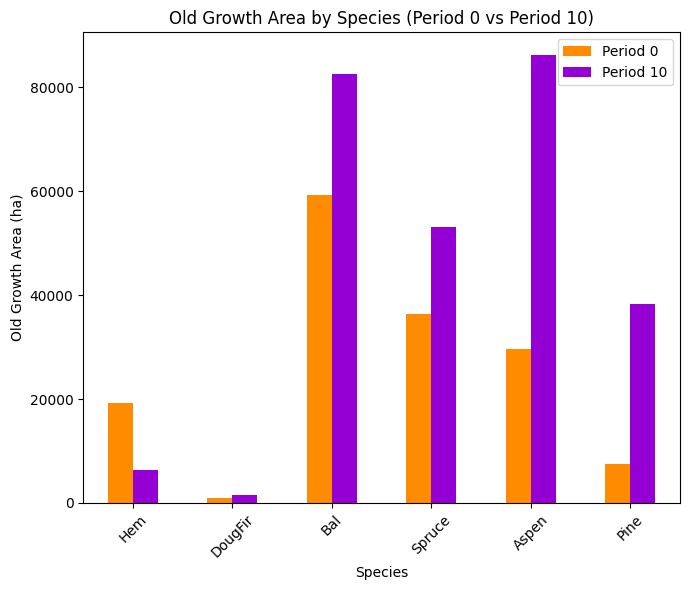

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7260

Diversity has **decreased** by 3.32% from time 0 to time 10.


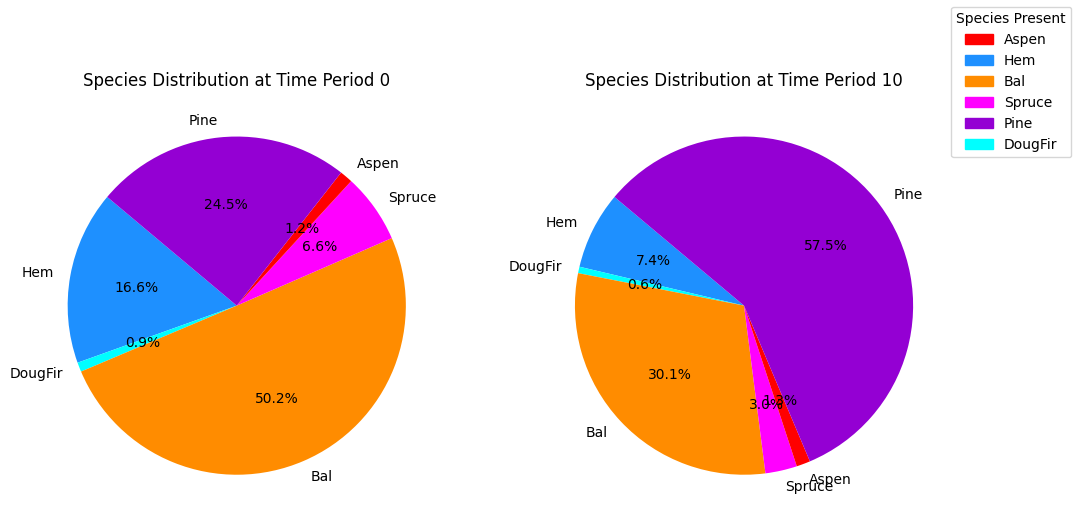

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_species_pie.pdf


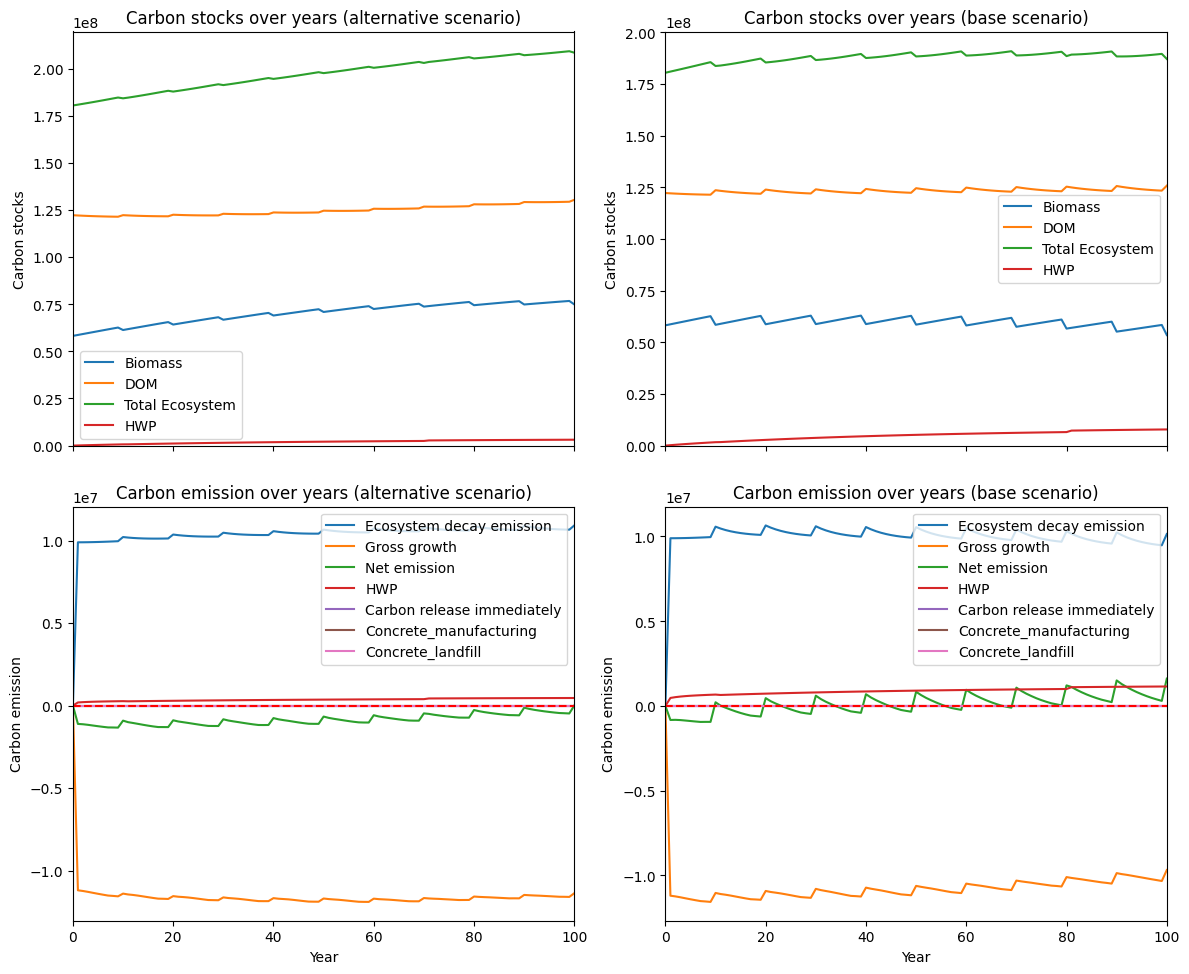

---------------------------------------------------------------------------------------
Net emission difference -17519255.763228334
Net emission base scenario -27791270.14695297
Net emission alternative scenario -10272014.383724635
dollar_per_ton is:  0.5708005028951793
Comparison of Old Growth Areas (Alternative - Base)
           0             10     Difference
Hem      0.0    4438.403476    4438.403476
DougFir  0.0    1120.945574    1120.945574
Bal      0.0   17322.433462   17322.433462
Spruce   0.0  100882.085552  100882.085552
Aspen    0.0   31628.794705   31628.794705
Pine     0.0   27607.886524   27607.886524

Overall, the old growth area has **increased** by 183000.55 hectares in the alternative scenario compared to the base scenario.


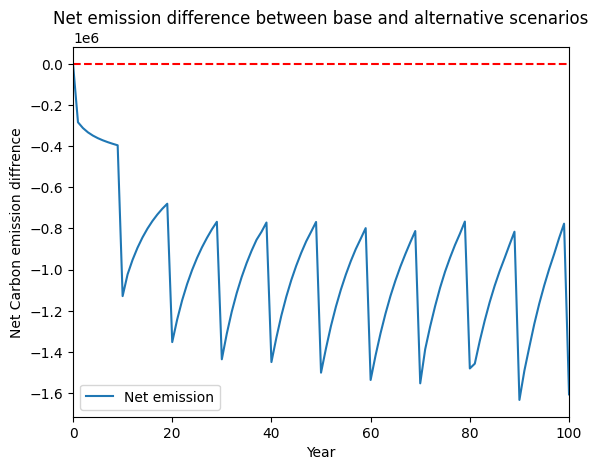

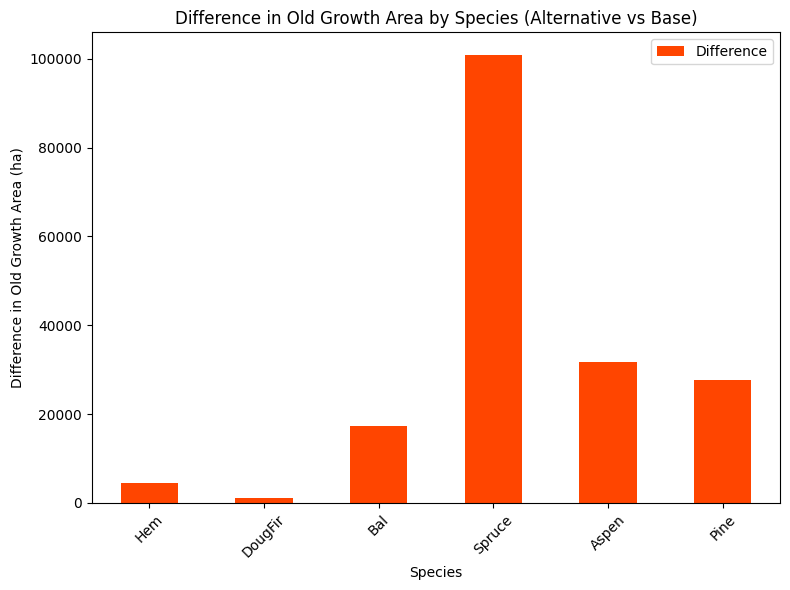

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_kpi_age_difference.pdf


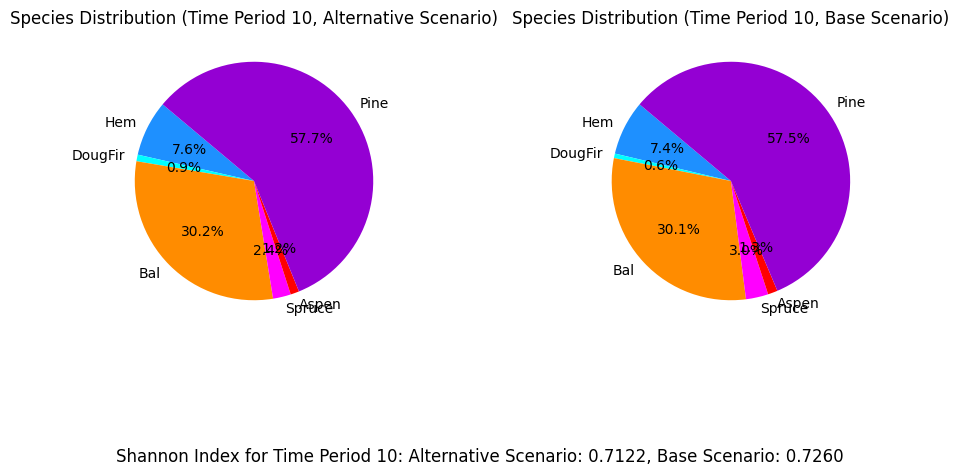

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for equitysilver_max_st_eqtslvr_AAC_30%...
running the scenario for the Equity Silver mining site (30%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0x196b1a5c
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [4e+01, 7e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8883 columns
Presolve time: 0.23s
Presolved: 8375 r

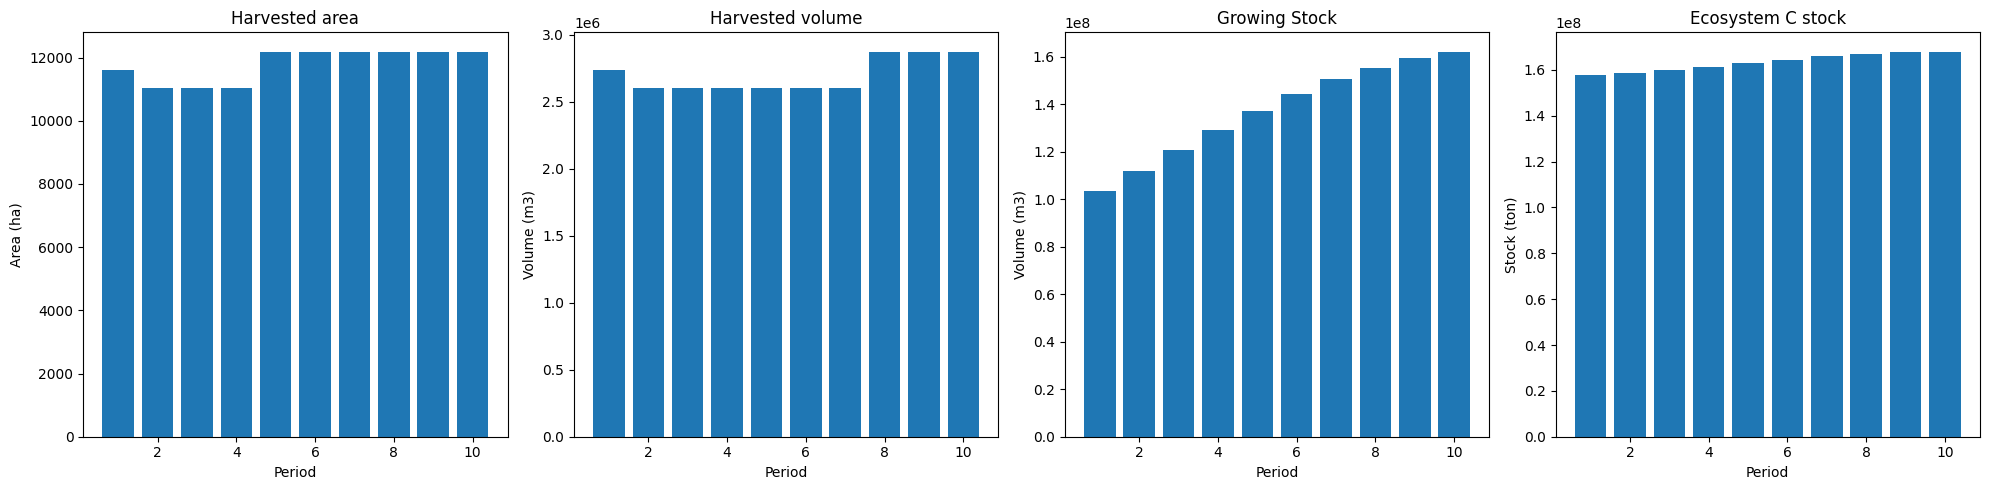

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_30%_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  28515
The economic indicator (the provincial government revenues) is:  972444
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


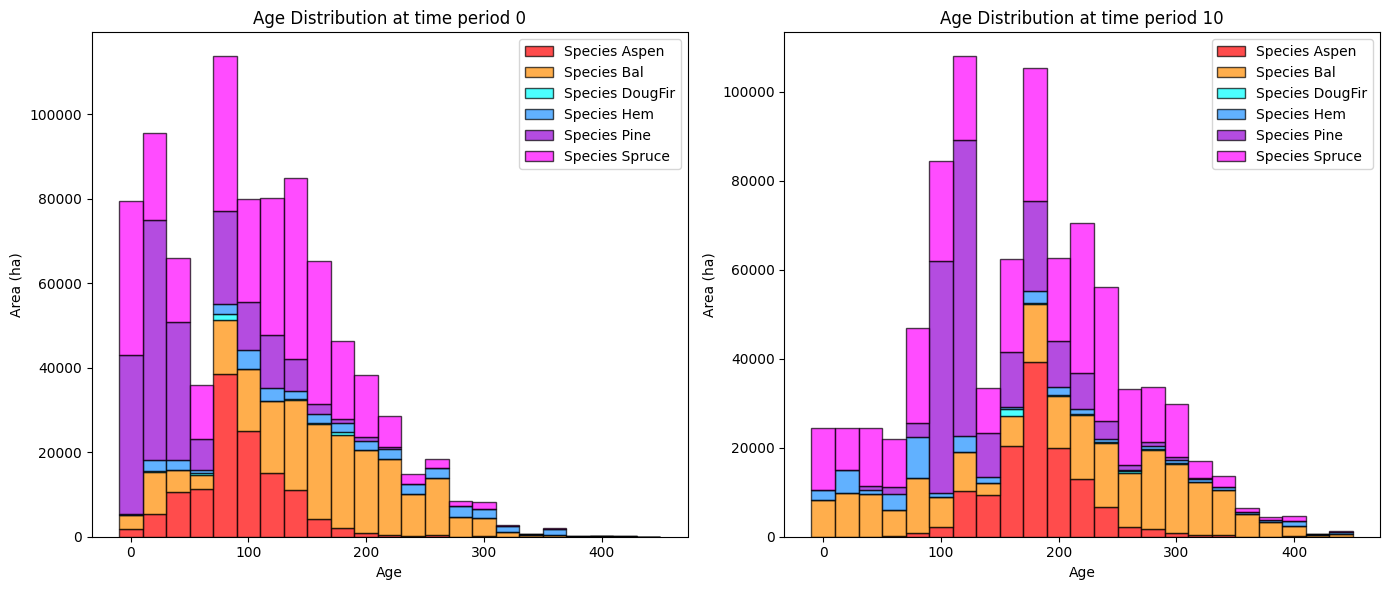

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_30%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0             10     Difference
Hem      19152.127229   13260.329389   -5891.797840
DougFir    947.047810    2749.298212    1802.250402
Bal      59315.970469  115134.716287   55818.745818
Spruce   36410.744598  161163.258248  124752.513650
Aspen    29632.731169  118052.632115   88419.900946
Pine      7432.733686   67771.874867   60339.141181

Overall diversity has **increased** by 325240.75 hectares from time period 0 to time period 10.


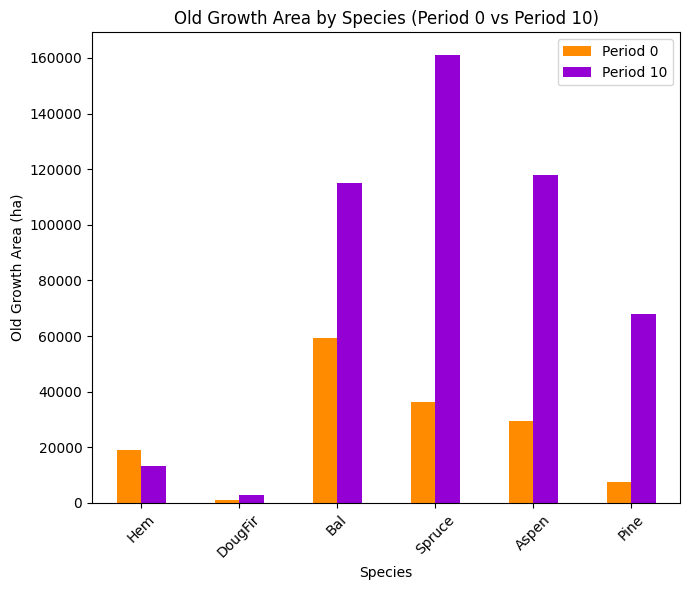

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_30%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7137

Diversity has **decreased** by 4.55% from time 0 to time 10.


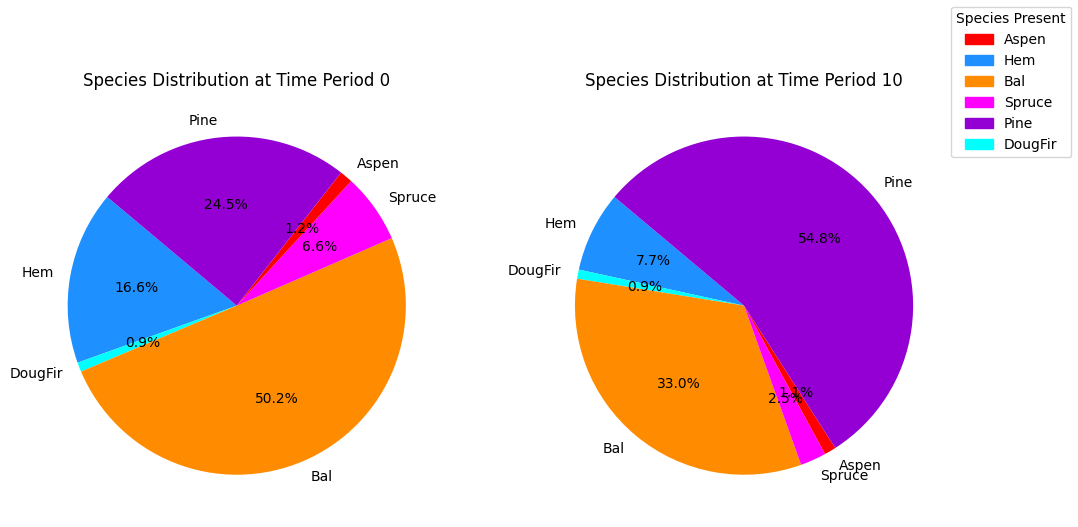

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_30%_species_pie.pdf
running business as usual scenario for the Equity Silver mining site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0x9ff13077
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [4e+01, 7e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8883 columns
Presolve time: 0.23s
Presolved: 8375 rows, 74376 columns, 536315 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Or

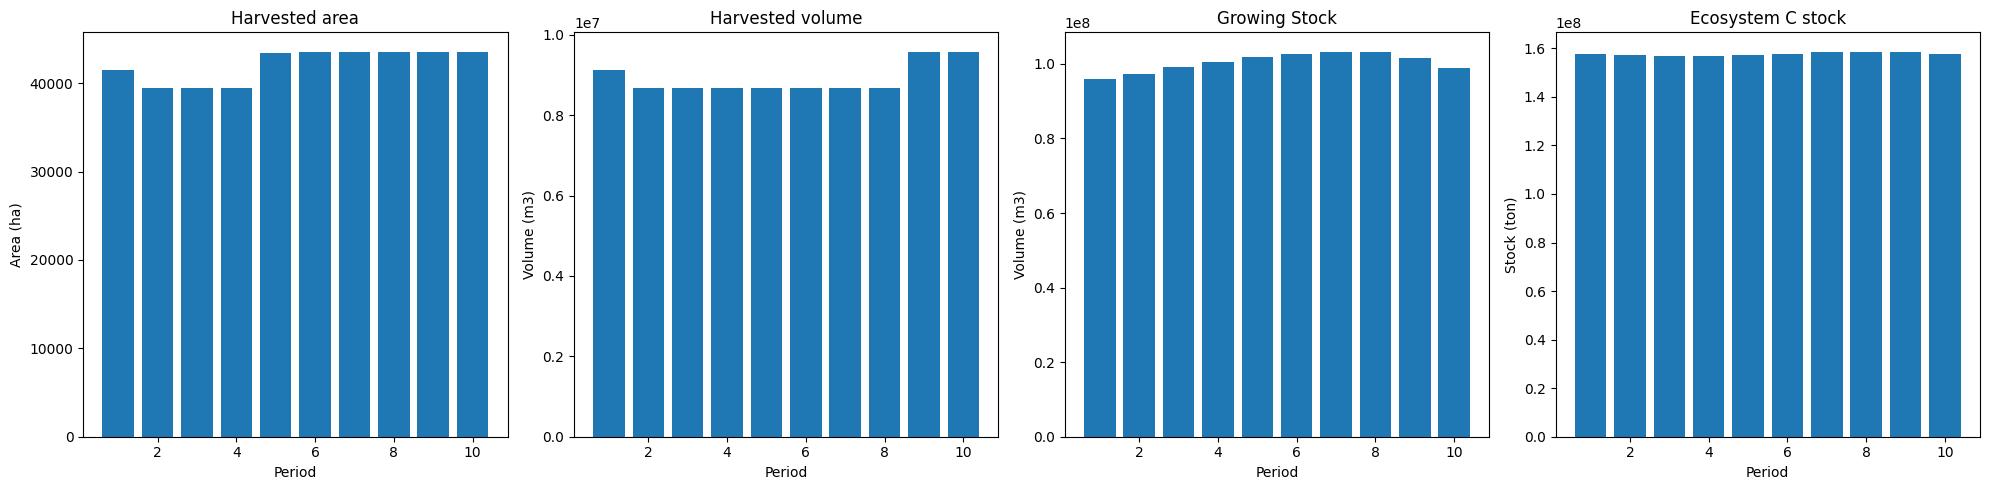

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  94087
The economic indicator (the provincial government revenues) is:  3208573
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


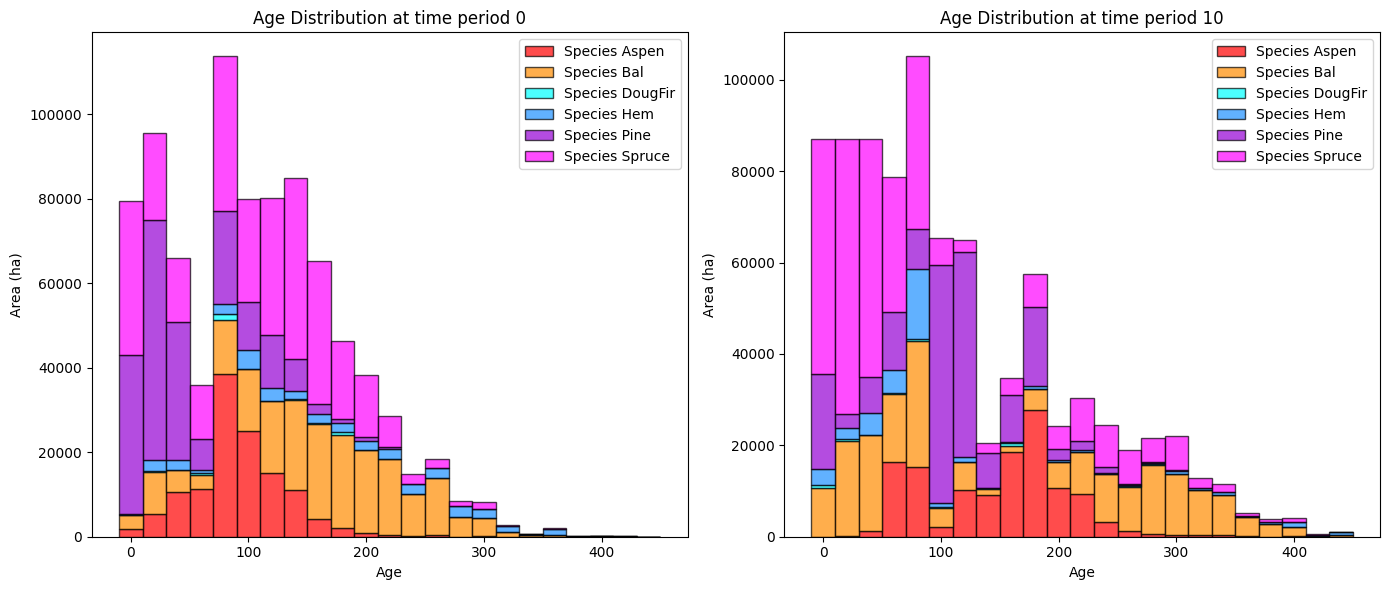

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0            10    Difference
Hem      19152.127229   6336.259592 -12815.867637
DougFir    947.047810   1486.896012    539.848202
Bal      59315.970469  82610.623426  23294.652957
Spruce   36410.744598  53027.466135  16616.721537
Aspen    29632.731169  86224.058762  56591.327592
Pine      7432.733686  38253.569262  30820.835576

Overall diversity has **increased** by 115047.52 hectares from time period 0 to time period 10.


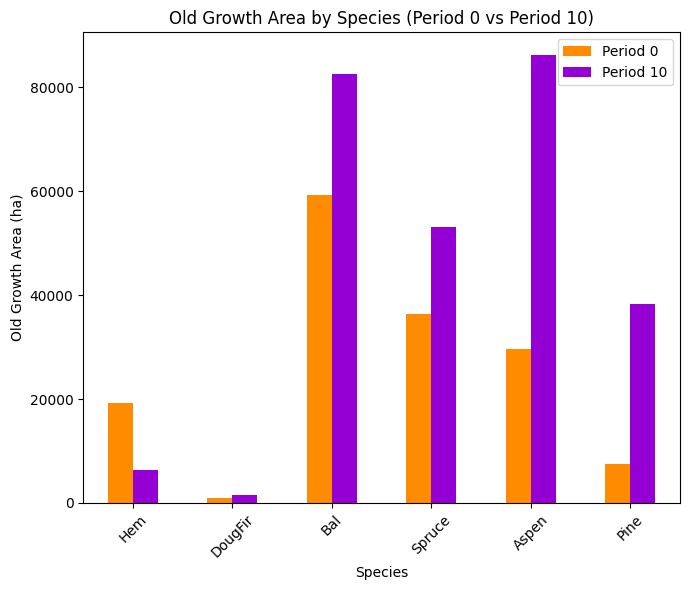

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7260

Diversity has **decreased** by 3.32% from time 0 to time 10.


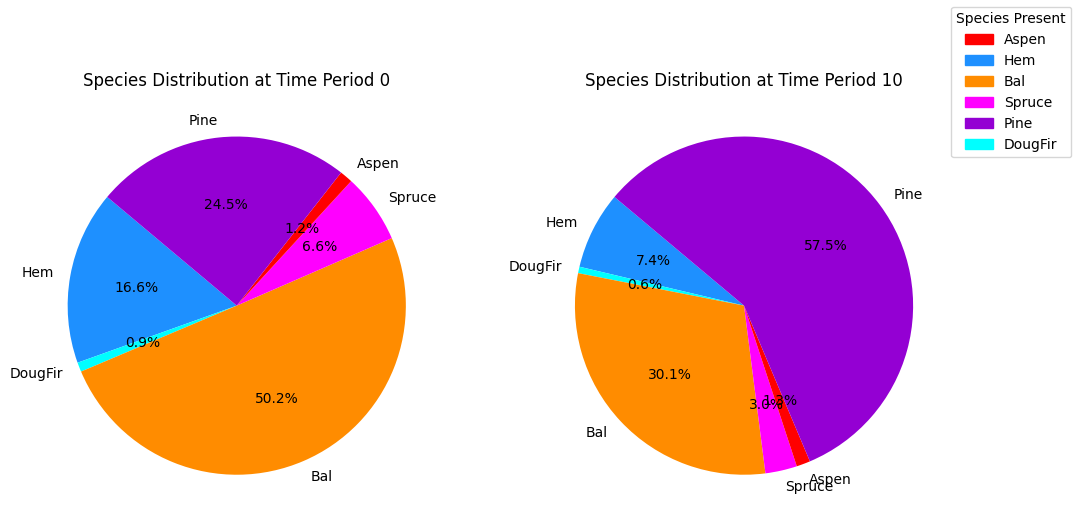

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_species_pie.pdf


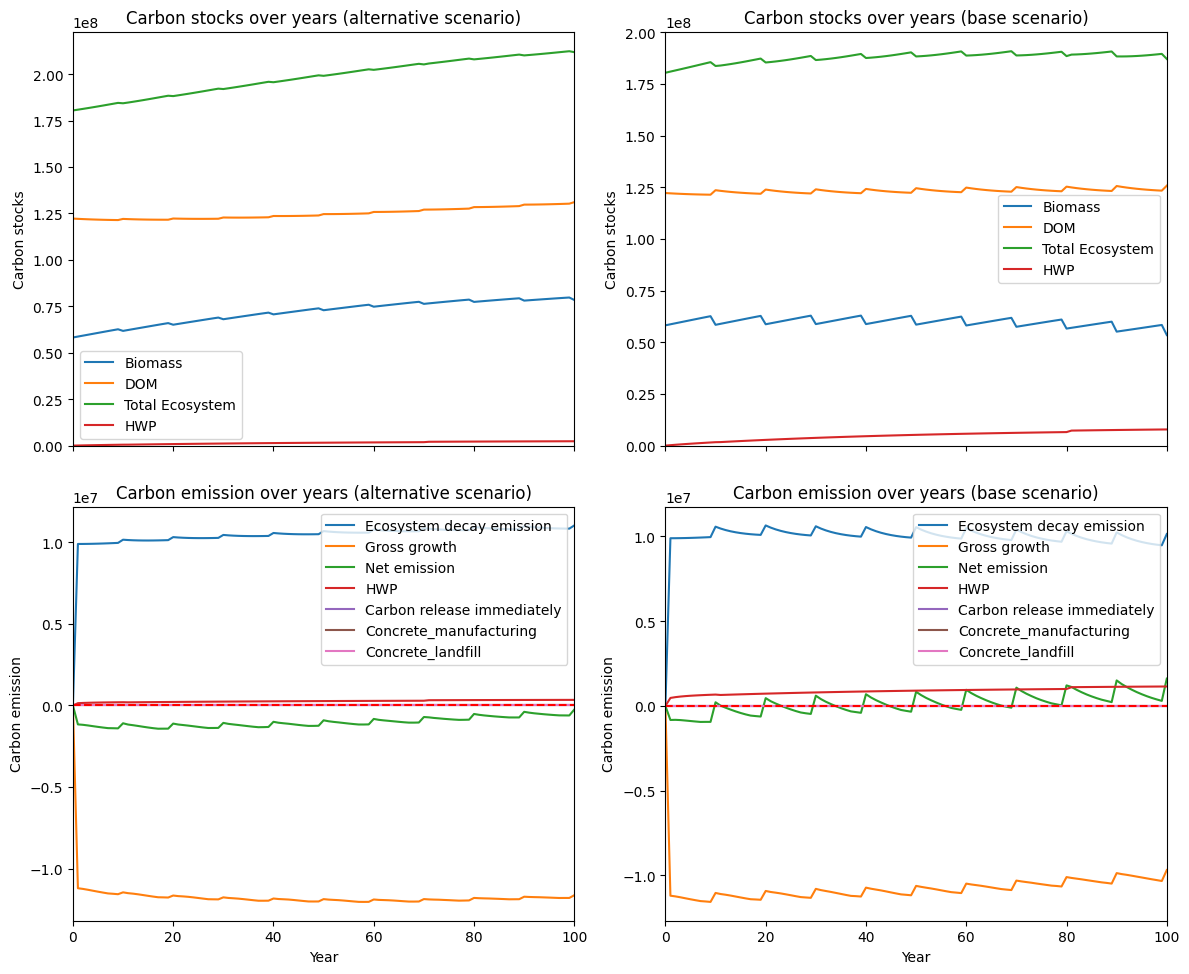

---------------------------------------------------------------------------------------
Net emission difference -20391263.888690967
Net emission base scenario -30663278.27241561
Net emission alternative scenario -10272014.383724635
dollar_per_ton is:  0.49040609030350585
Comparison of Old Growth Areas (Alternative - Base)
           0             10     Difference
Hem      0.0    6924.069797    6924.069797
DougFir  0.0    1262.402200    1262.402200
Bal      0.0   32524.092861   32524.092861
Spruce   0.0  108135.792113  108135.792113
Aspen    0.0   31828.573353   31828.573353
Pine     0.0   29518.305605   29518.305605

Overall, the old growth area has **increased** by 210193.24 hectares in the alternative scenario compared to the base scenario.


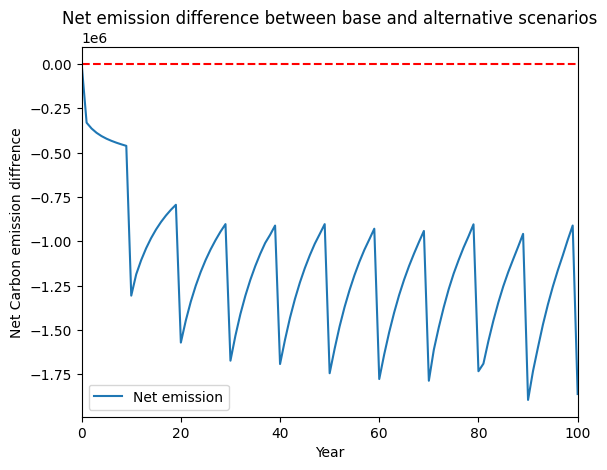

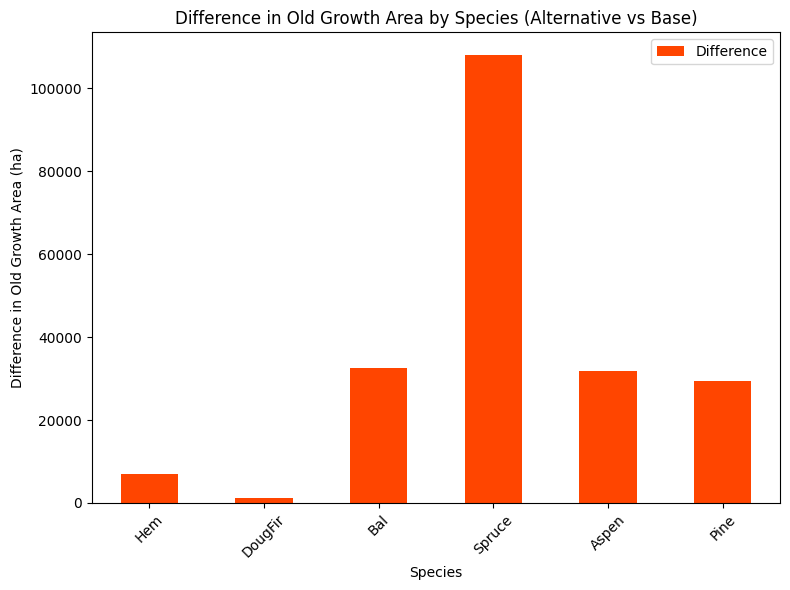

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_kpi_age_difference.pdf


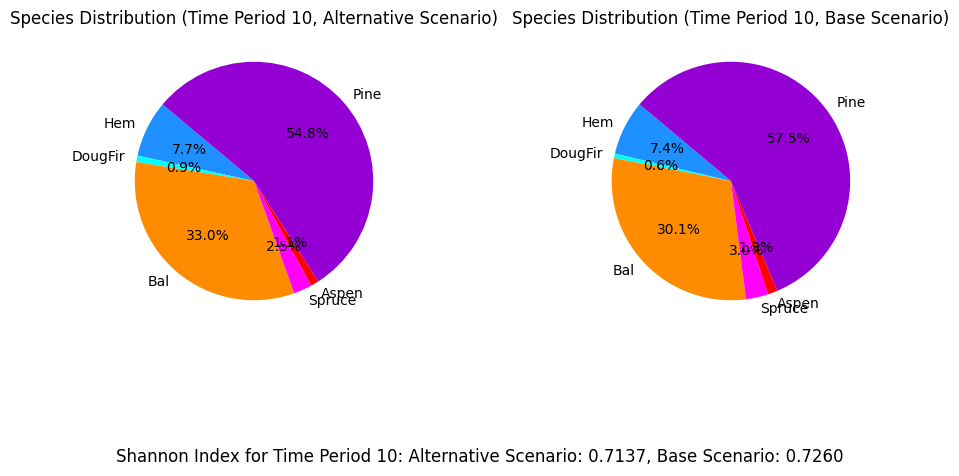

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for equitysilver_max_st_eqtslvr_AAC_20%...
running the scenario for the Equity Silver mining site (20%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0x0d31d42f
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [4e+01, 7e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8883 columns
Presolve time: 0.22s
Presolved: 8375 r

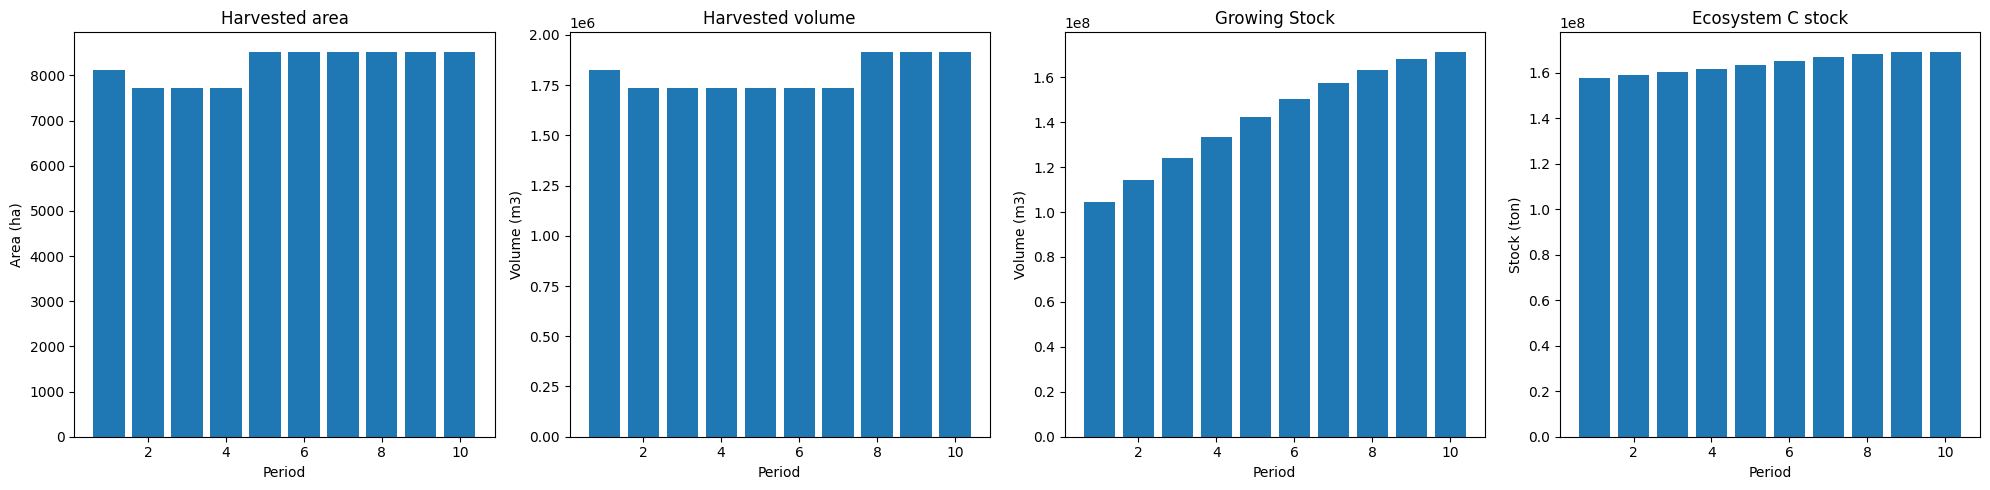

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_20%_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  19010
The economic indicator (the provincial government revenues) is:  648296
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


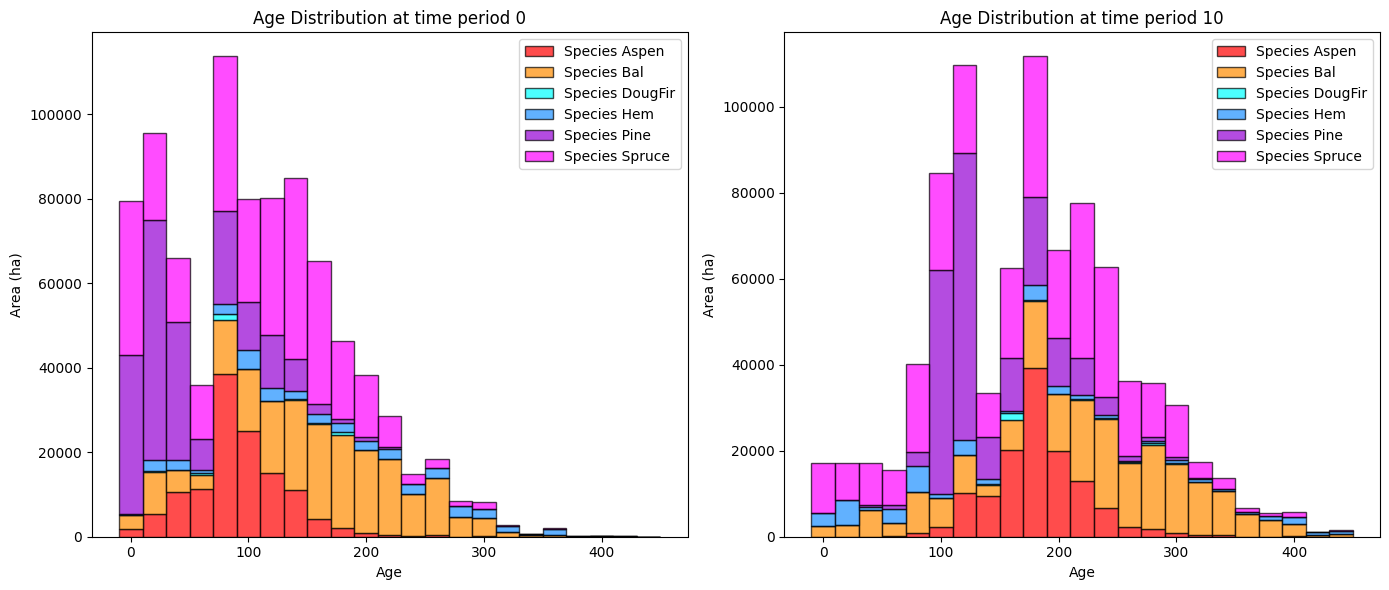

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_20%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0             10     Difference
Hem      19152.127229   15070.748708   -4081.378521
DougFir    947.047810    2749.298212    1802.250402
Bal      59315.970469  136005.617545   76689.647077
Spruce   36410.744598  169108.136097  132697.391499
Aspen    29632.731169  118142.060176   88509.329007
Pine      7432.733686   69166.086047   61733.352361

Overall diversity has **increased** by 357350.59 hectares from time period 0 to time period 10.


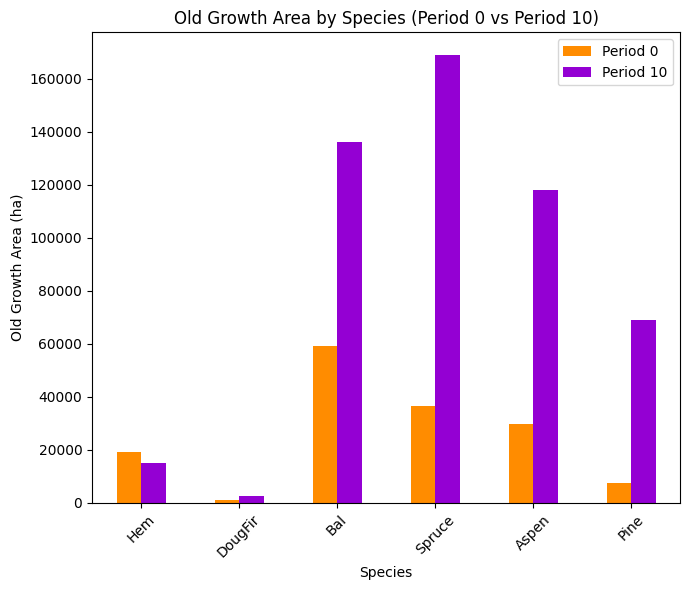

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_20%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7135

Diversity has **decreased** by 4.57% from time 0 to time 10.


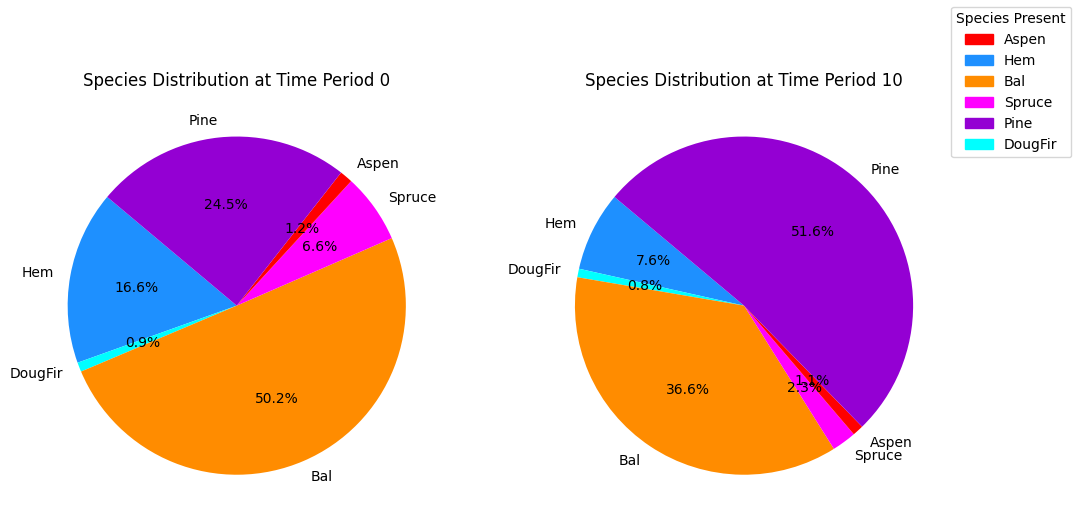

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_20%_species_pie.pdf
running business as usual scenario for the Equity Silver mining site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0x9ff13077
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [4e+01, 7e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8883 columns
Presolve time: 0.24s
Presolved: 8375 rows, 74376 columns, 536315 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Or

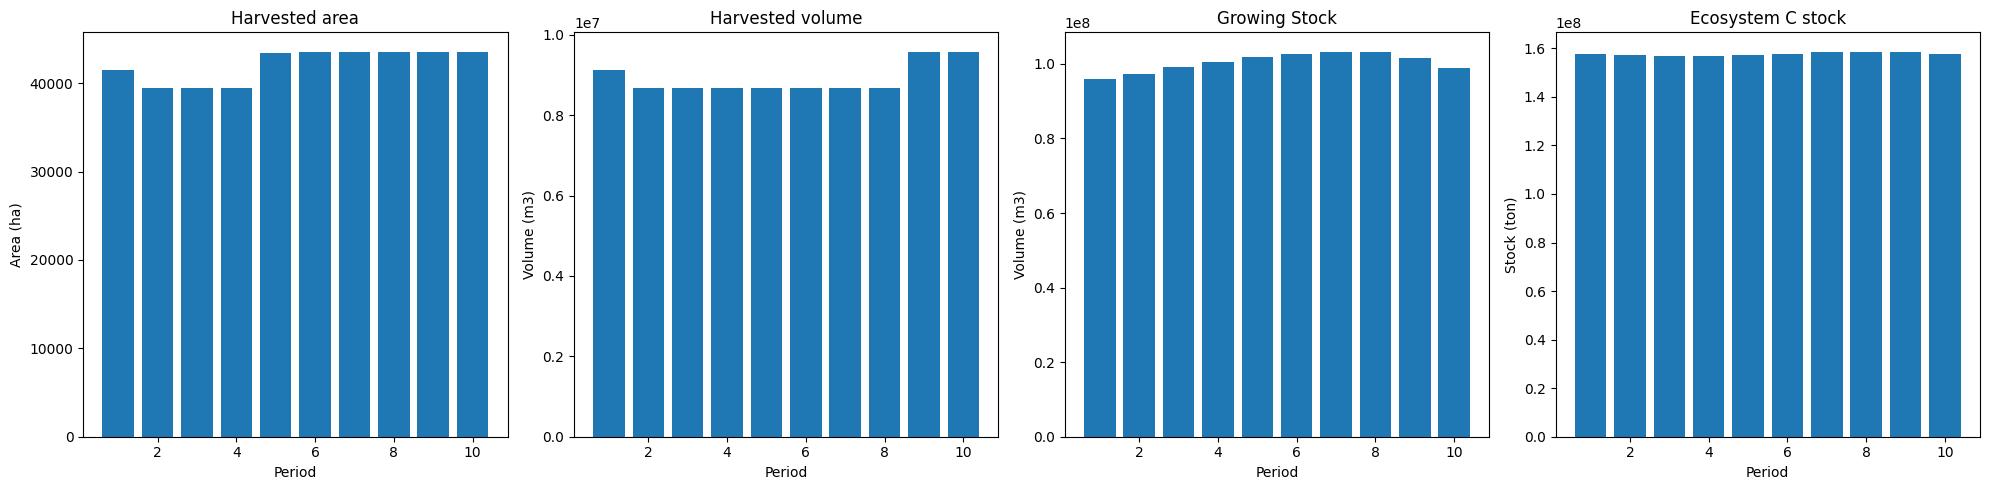

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  94087
The economic indicator (the provincial government revenues) is:  3208573
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


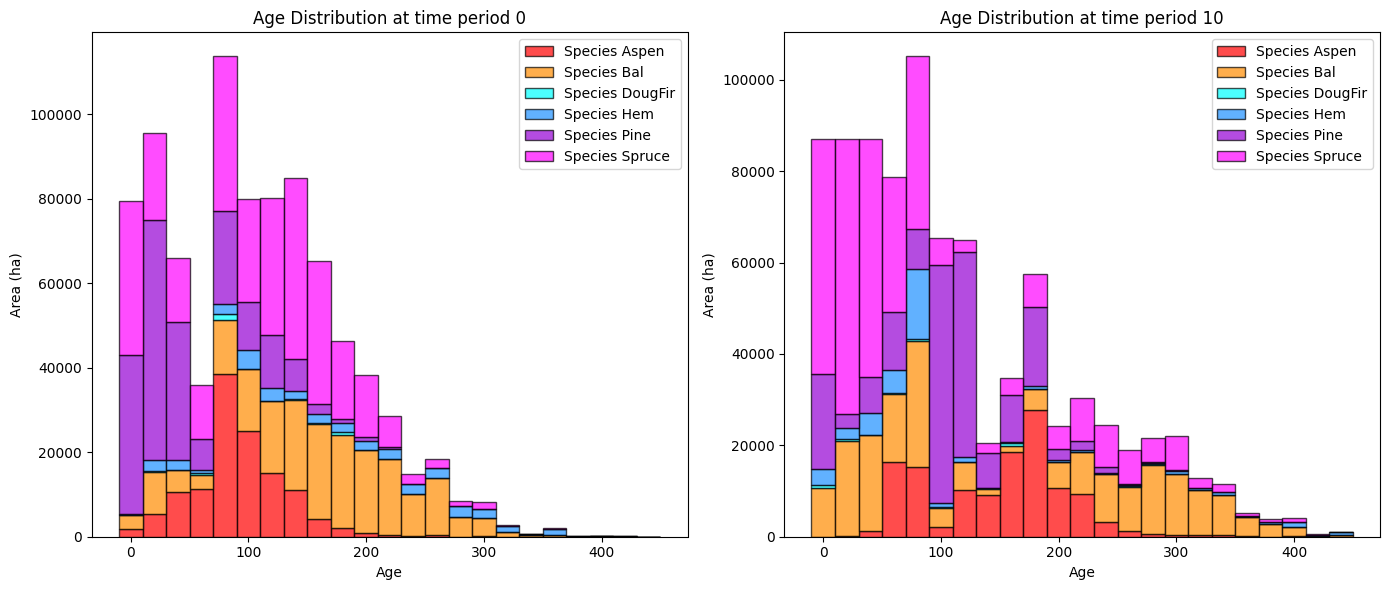

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0            10    Difference
Hem      19152.127229   6336.259592 -12815.867637
DougFir    947.047810   1486.896012    539.848202
Bal      59315.970469  82610.623426  23294.652957
Spruce   36410.744598  53027.466135  16616.721537
Aspen    29632.731169  86224.058762  56591.327592
Pine      7432.733686  38253.569262  30820.835576

Overall diversity has **increased** by 115047.52 hectares from time period 0 to time period 10.


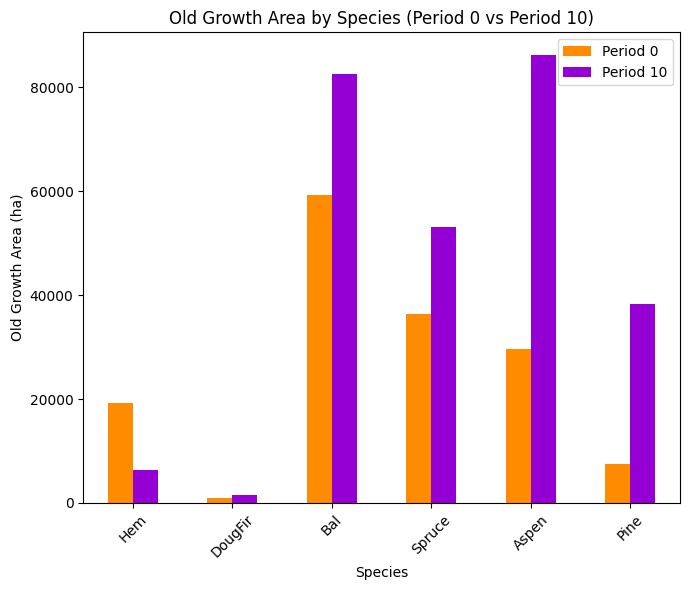

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7260

Diversity has **decreased** by 3.32% from time 0 to time 10.


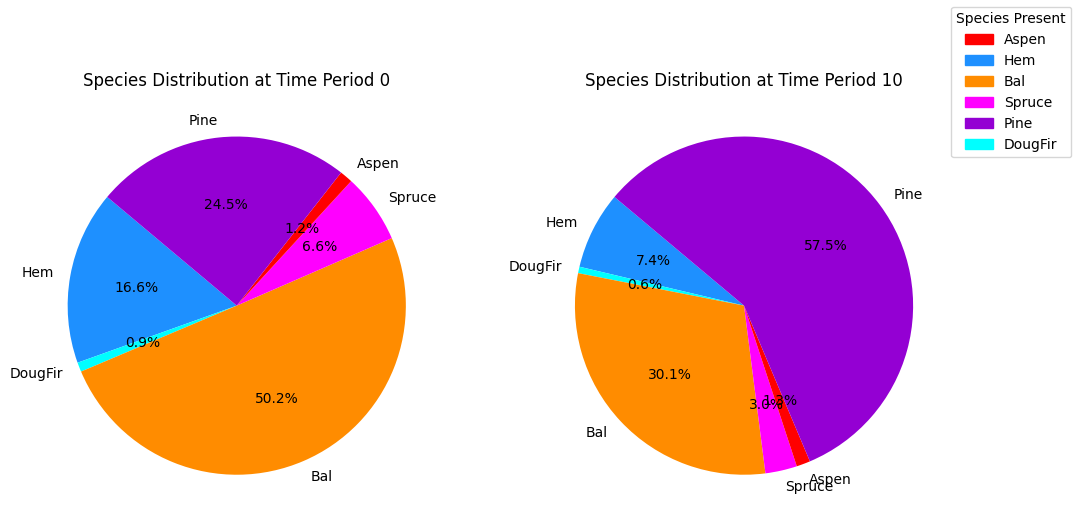

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_species_pie.pdf


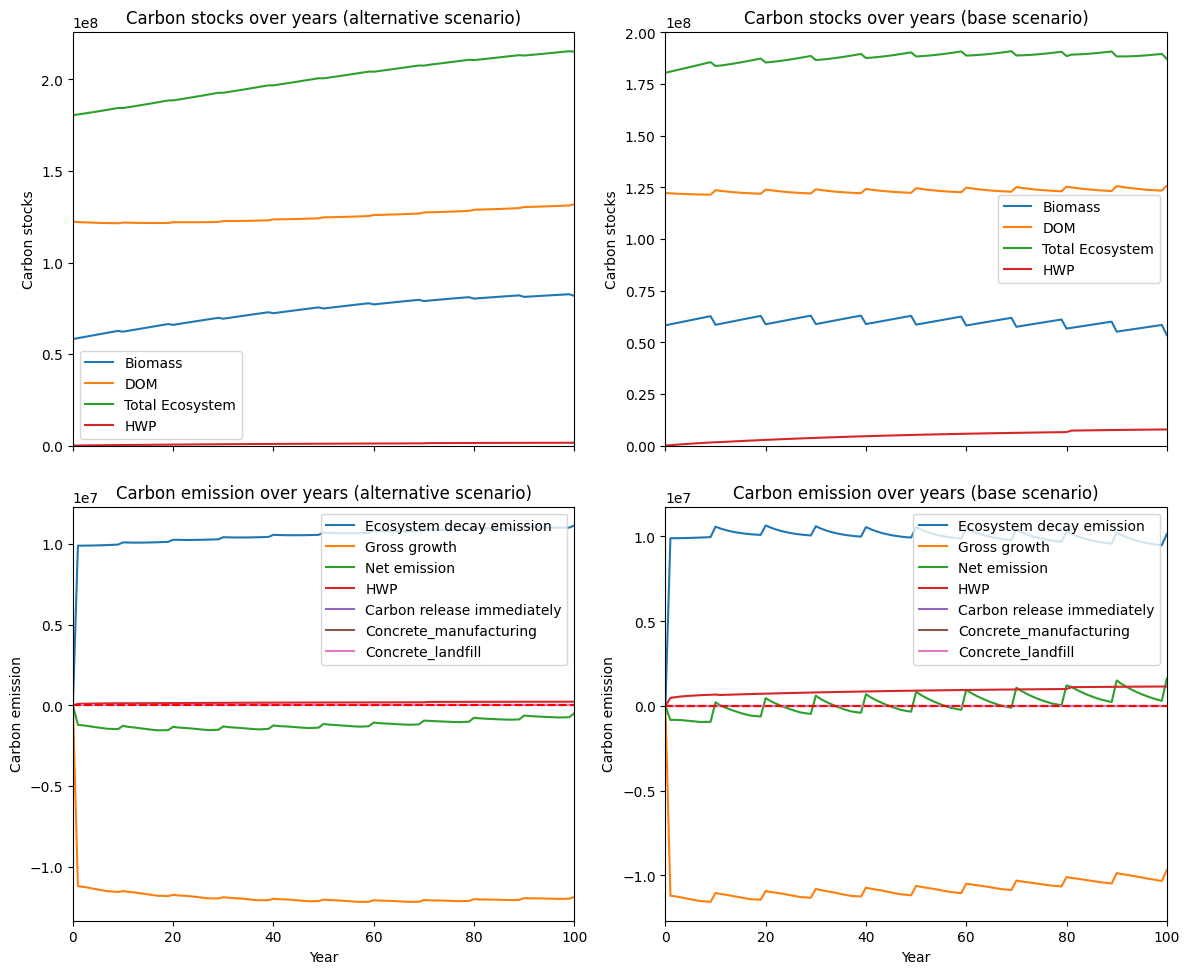

---------------------------------------------------------------------------------------
Net emission difference -23269263.085597955
Net emission base scenario -33541277.469322585
Net emission alternative scenario -10272014.383724635
dollar_per_ton is:  0.4297514692757632
Comparison of Old Growth Areas (Alternative - Base)
           0             10     Difference
Hem      0.0    8734.489116    8734.489116
DougFir  0.0    1262.402200    1262.402200
Bal      0.0   53394.994119   53394.994119
Spruce   0.0  116080.669963  116080.669963
Aspen    0.0   31918.001414   31918.001414
Pine     0.0   30912.516784   30912.516784

Overall, the old growth area has **increased** by 242303.07 hectares in the alternative scenario compared to the base scenario.


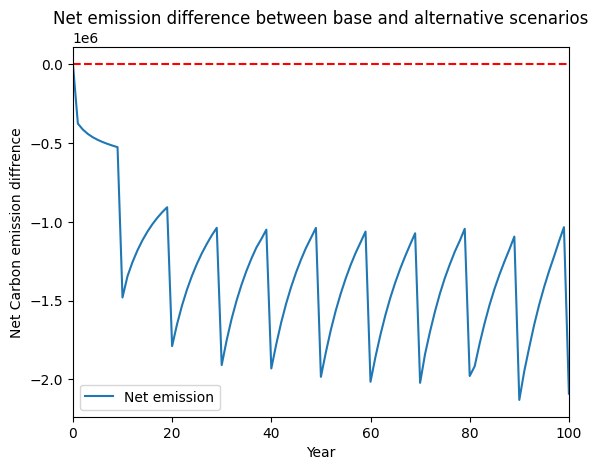

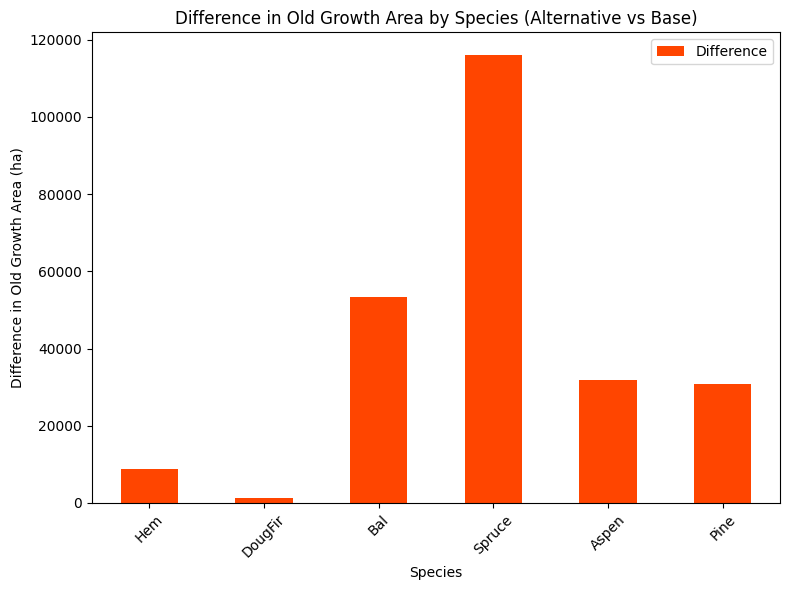

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_kpi_age_difference.pdf


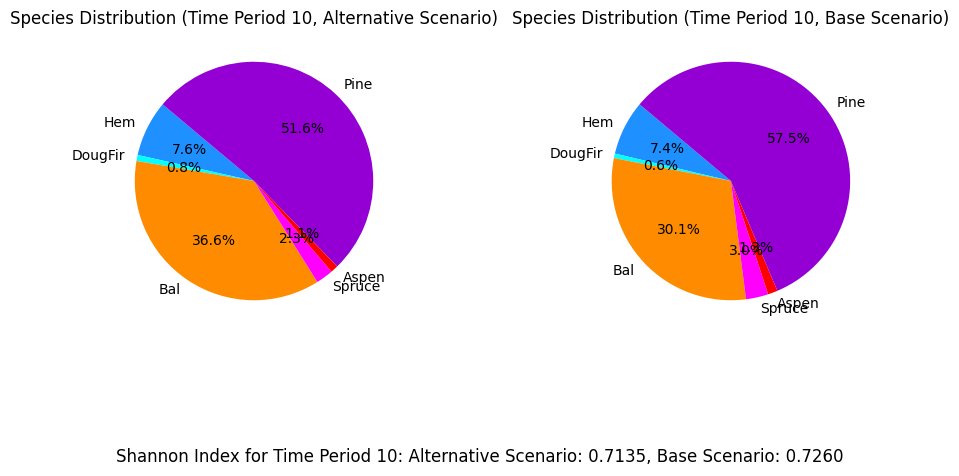

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for equitysilver_max_st_eqtslvr_AAC_10%...
running the scenario for the Equity Silver mining site (10%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0xf18fb1fc
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [4e+01, 7e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8883 columns
Presolve time: 0.22s
Presolved: 8375 r

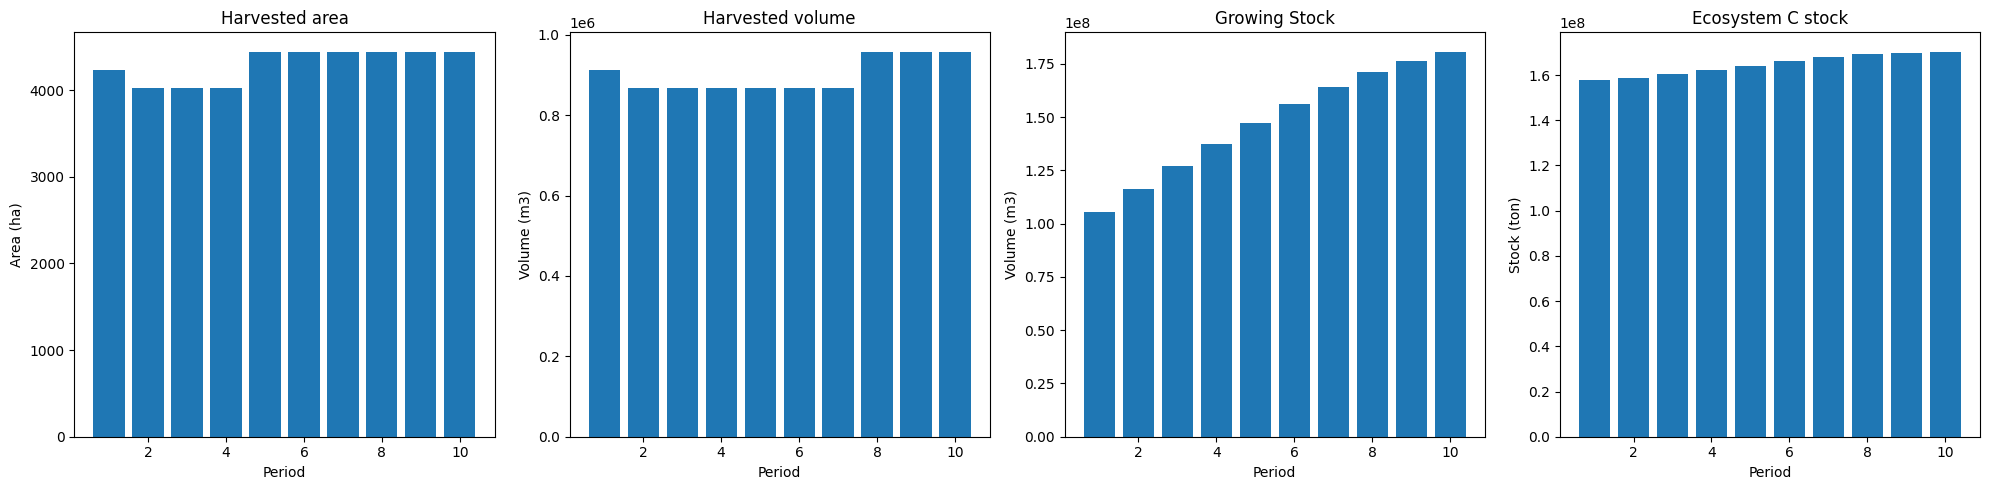

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_10%_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  9505
The economic indicator (the provincial government revenues) is:  324148
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


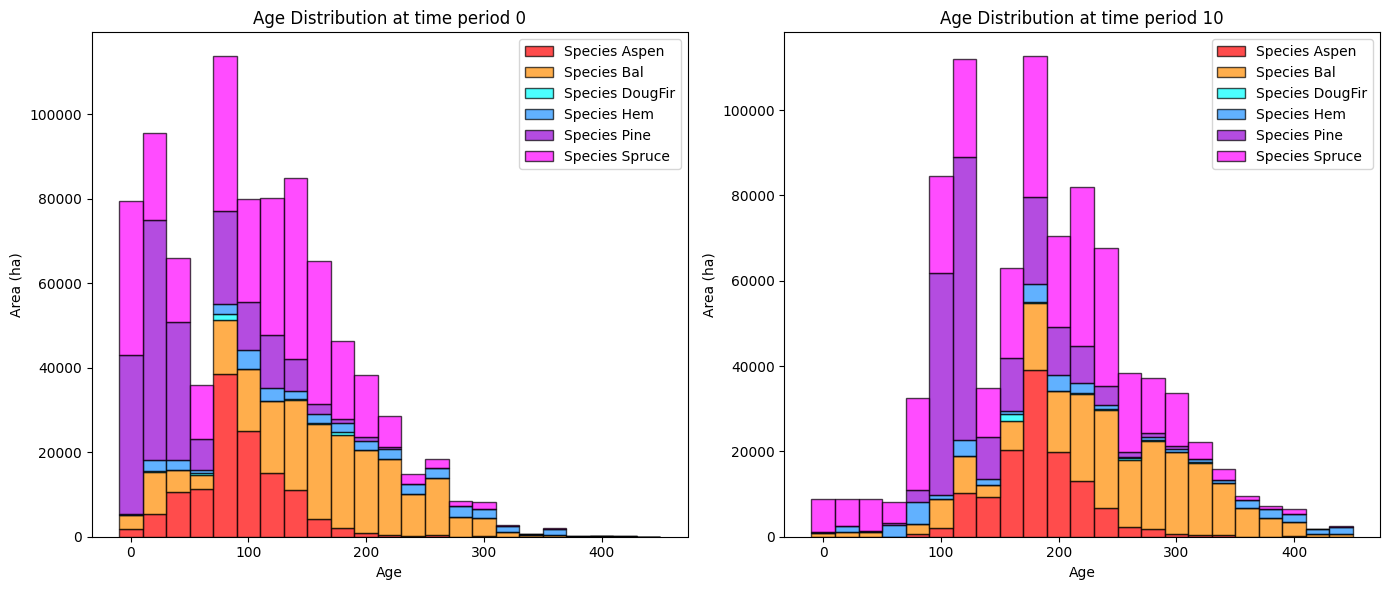

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_10%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0             10     Difference
Hem      19152.127229   23073.328257    3921.201028
DougFir    947.047810    2749.298212    1802.250402
Bal      59315.970469  153653.638331   94337.667862
Spruce   36410.744598  175352.144247  138941.399649
Aspen    29632.731169  118314.566885   88681.835716
Pine      7432.733686   69980.577112   62547.843426

Overall diversity has **increased** by 390232.20 hectares from time period 0 to time period 10.


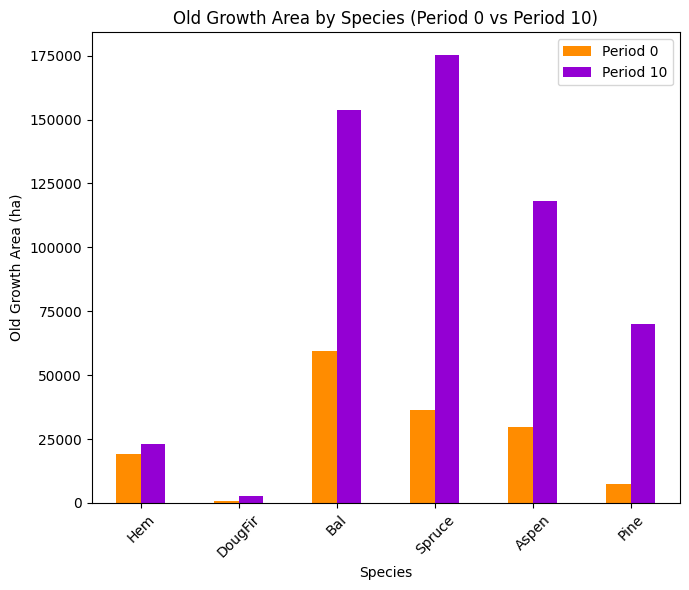

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_10%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7235

Diversity has **decreased** by 3.57% from time 0 to time 10.


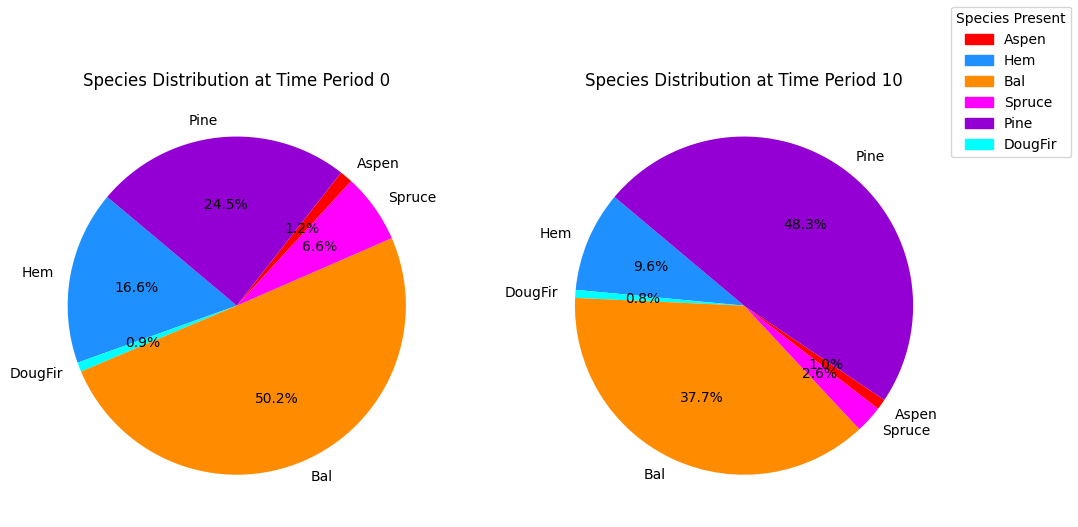

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_eqtslvr_AAC_10%_species_pie.pdf
running business as usual scenario for the Equity Silver mining site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0x9ff13077
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [4e+01, 7e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8883 columns
Presolve time: 0.22s
Presolved: 8375 rows, 74376 columns, 536315 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Or

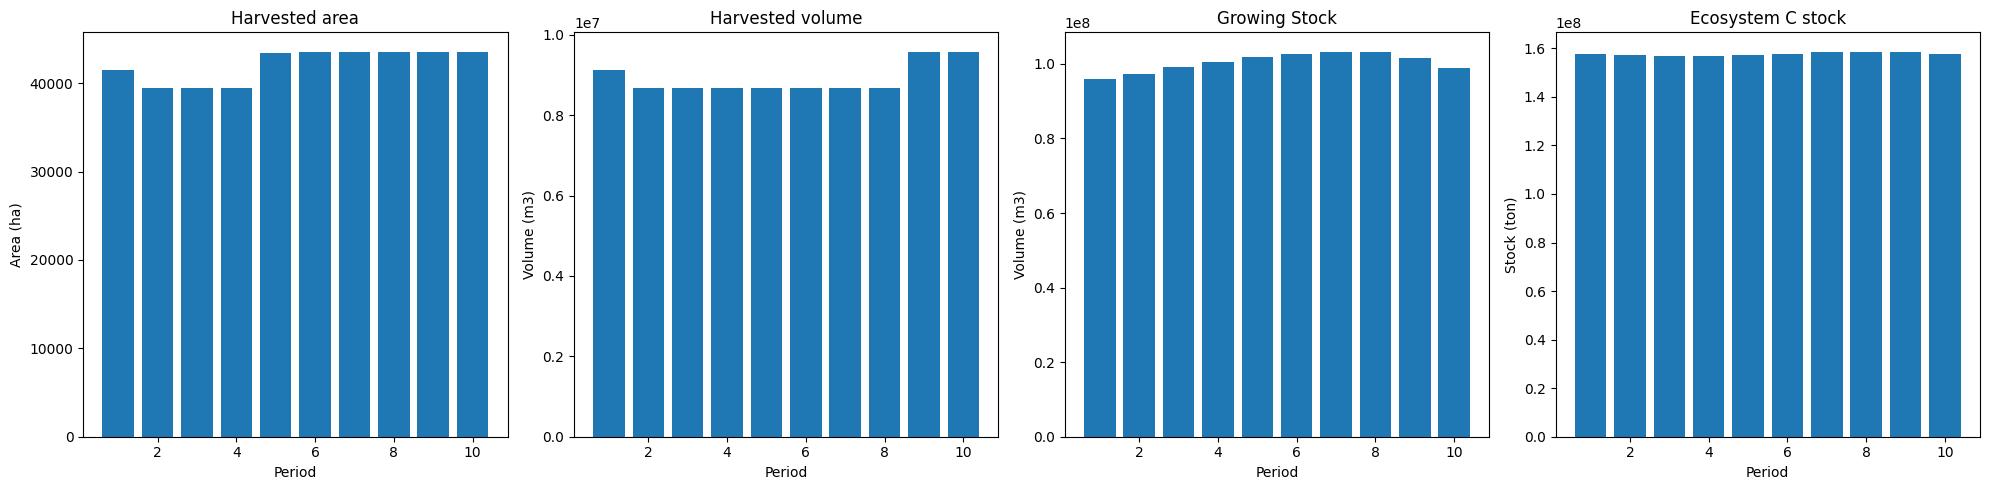

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  94087
The economic indicator (the provincial government revenues) is:  3208573
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


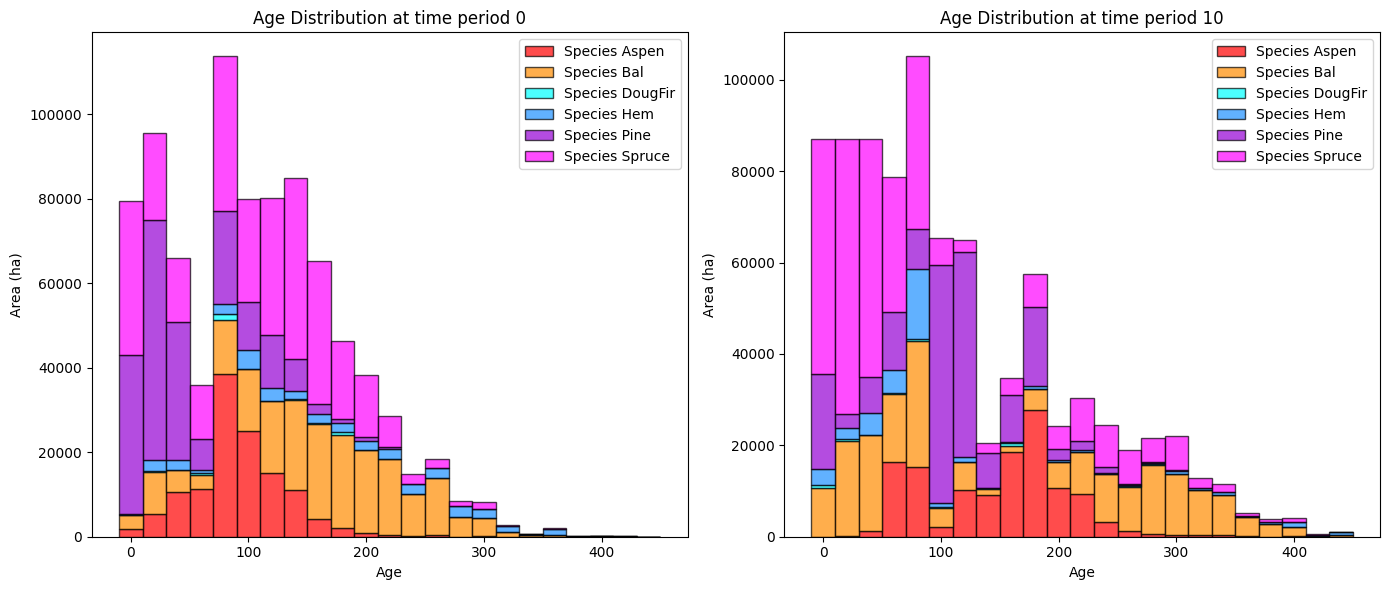

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0            10    Difference
Hem      19152.127229   6336.259592 -12815.867637
DougFir    947.047810   1486.896012    539.848202
Bal      59315.970469  82610.623426  23294.652957
Spruce   36410.744598  53027.466135  16616.721537
Aspen    29632.731169  86224.058762  56591.327592
Pine      7432.733686  38253.569262  30820.835576

Overall diversity has **increased** by 115047.52 hectares from time period 0 to time period 10.


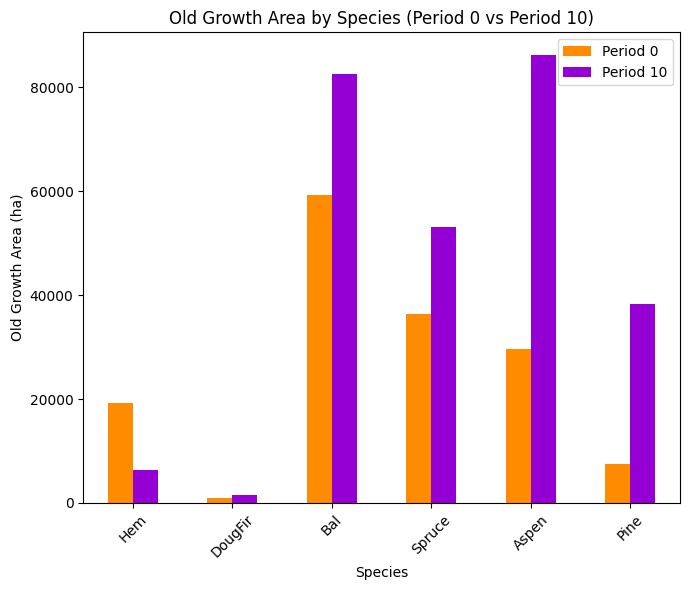

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7260

Diversity has **decreased** by 3.32% from time 0 to time 10.


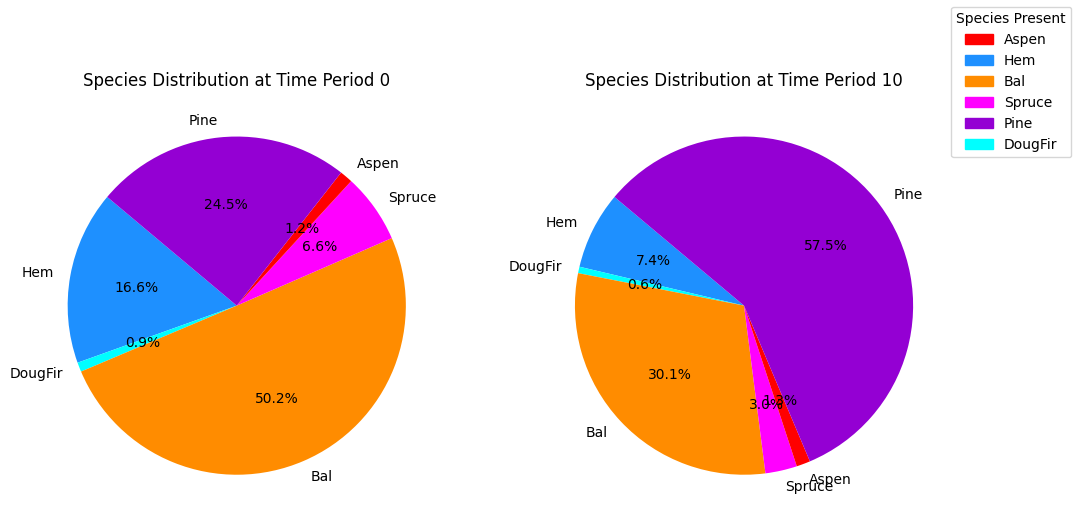

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_bau_eqtslvr_species_pie.pdf


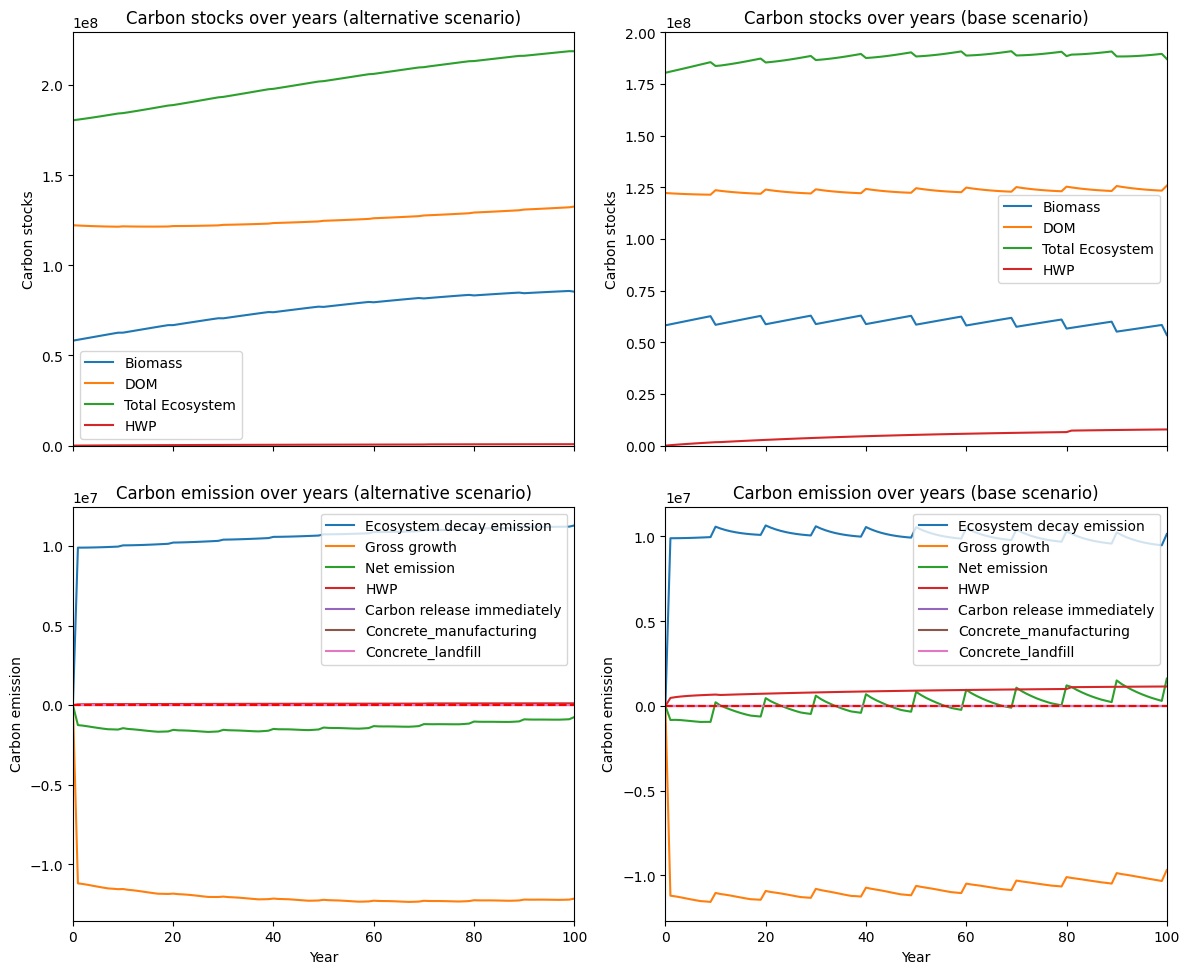

---------------------------------------------------------------------------------------
Net emission difference -26237977.226171877
Net emission base scenario -36509991.60989652
Net emission alternative scenario -10272014.383724635
dollar_per_ton is:  0.3811269410671335
Comparison of Old Growth Areas (Alternative - Base)
           0             10     Difference
Hem      0.0   16737.068665   16737.068665
DougFir  0.0    1262.402200    1262.402200
Bal      0.0   71043.014905   71043.014905
Spruce   0.0  122324.678112  122324.678112
Aspen    0.0   32090.508123   32090.508123
Pine     0.0   31727.007849   31727.007849

Overall, the old growth area has **increased** by 275184.68 hectares in the alternative scenario compared to the base scenario.


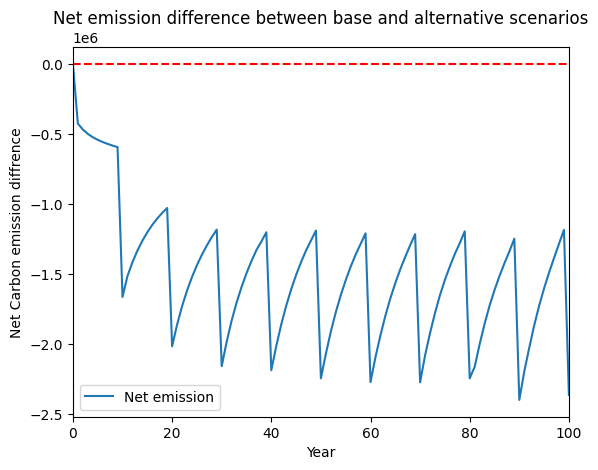

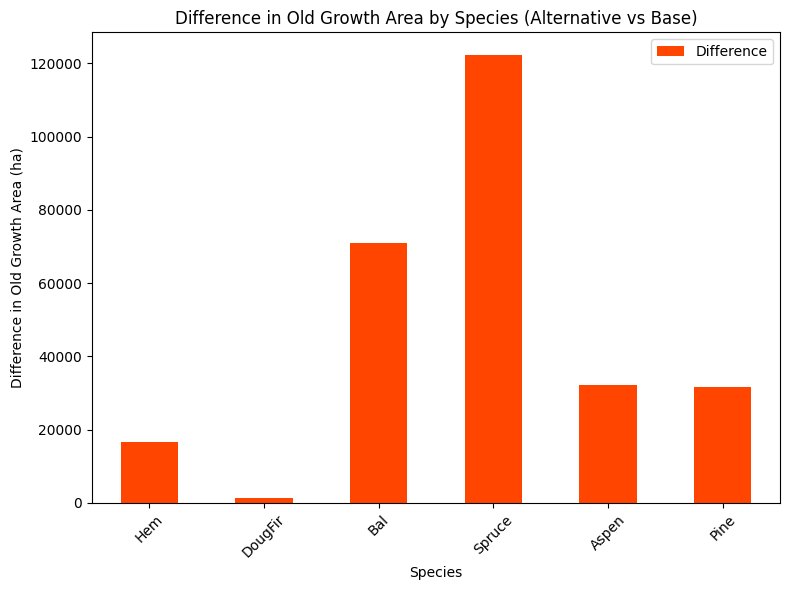

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_st_kpi_age_difference.pdf


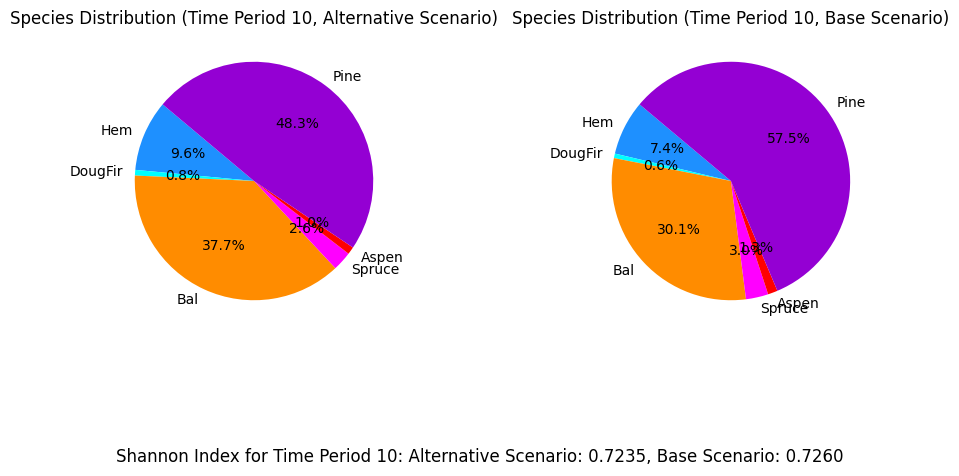

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
It took 348.2 minutes to run all scenarios.


In [12]:
Start = time.time()
scenario_names = scenario_options.get(case_study, [])
for scenario_name in scenario_names:
    print(f"Running for {case_study}_{obj_mode}_{scenario_name}...")
    results_scenarios(fm, 
                      clt_percentage, 
                      credibility, 
                      budget_input, 
                      n_steps, 
                      max_harvest, 
                      scenario_name, 
                      displacement_effect, 
                      hwp_pool_effect_value, 
                      release_immediately_value, 
                      case_study, 
                      obj_mode,                   
                      pickle_output_base=False, 
                      pickle_output_alter=False)
print('It took', round((time.time() - Start) / 60, 1), "minutes to run all scenarios.")

In [13]:
print('It took', round((time.time() - Start) / 60, 1), "minutes to run this script.")

It took 348.2 minutes to run this script.
